<a href="https://colab.research.google.com/github/NatP-dev/Complete-Python-3-Bootcamp/blob/master/Welcome_to_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Can Machine Learning Improve Portfolio Optimization for Cryptocurrencies?**

#### **Author**: Nathalia Pouroullis
#### **Student Number**: 18050
#### **Date**: 27 March 2025

Disclaimer: Please note, that while this assignment is quite lengthy

Cryptocurrency markets are known for their high volatility, non-stationary behavior, and complex correlation structures. Traditional portfolio optimization techniques, such as Modern Portfolio Theory (MPT), fail to capture the non-linear dependencies and extreme price fluctuations characteristic of digital assets.

Machine learning (ML) offers an opportunity to enhance portfolio allocation strategies by leveraging historical patterns, advanced risk modeling, and adaptive decision-making frameworks. This study evaluates whether ML-driven portfolio optimization techniques can outperform traditional methods in the cryptocurrency domain, potentially offering better risk-adjusted returns and more robust portfolio management.

# **Table of Contents**


*   **<font color = '#000058'>Chapter 1: Introduction</font>**
>> 0 - Imports
*   **<font color = '#000058'>Chapter 2: Data</font>**
>>2.1 - Data Pre-processing
>>>>2.1.1 - Data Cleaning



---
---
# **<font color = '#000058'>Chapter 1: Introduction**</font>  
Cryptocurrencies have emerged as a highly volatile and complex class of assets, marked by their non-stationary behavior and intricate correlations between different assets. Traditional portfolio optimization methods, such as Modern Portfolio Theory (MPT), rely on the assumption of normal distribution of returns and fail to account for the non-linear dependencies and extreme price fluctuations seen in cryptocurrency markets. This makes it difficult to apply conventional financial models effectively for cryptocurrency portfolio management.<br><br>

This study aims to explore the use of machine learning (ML) techniques to optimize portfolio allocation in the cryptocurrency market, focusing on risk-adjusted returns. Specifically, the objective is to evaluate whether ML models can outperform traditional portfolio optimization methods, particularly in terms of Sharpe ratio, Sortino ratio, and maximum drawdown. By comparing ML-based portfolio allocation with the conventional Markowitz model, this analysis provides insights into the potential benefits of integrating machine learning into cryptocurrency portfolio management.

## **<font color='#474747'>0 - Imports**



In [1]:
################################ LIBRARIES ########################
# -------------------------- Web & Utilities -------------------------- #
import requests
import re
import time
import random
import math
import hdbscan

# -------------------------- Core Libraries -------------------------- #
import numpy as np
import pandas as pd
from collections import Counter

# -------------------------- Plotting -------------------------- #
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# -------------------------- Statistical & Optimization -------------------------- #
from scipy.stats import norm, zscore, skew, kurtosis, median_abs_deviation
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.cluster.hierarchy import dendrogram


# -------------------------- Machine Learning -------------------------- #
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score



# -------------------------- Deep Learning (PyTorch) -------------------------- #
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -------------------------- Finance API -------------------------- #
import yfinance as yf


# -------------------------- Optional Installations -------------------------- #
!pip install kneed
from kneed import KneeLocator



---
---
# **<font color='#000058'>Chapter 2: Data</font>**

<font color='#646464'>This study utilizes data from Yahoo Finance, a widely recognized and reliable provider of financial market data. Yahoo Finance aggregates pricing information from multiple exchanges which maintains accuracy, consistency and historical depth. The dataset includes adjusted closing prices and trading volumes, which are essential for financial modeling, volatility analysis and portfolio optimization.</font>

<br>

####**<font color='#646464'> Time Frame and Coverage</font>**  
<font color='#646464'>The dataset spans five years (March 1, 2020 – March 1, 2025), with daily observations. This period ensures coverage of both bull and bear market phases, allowing for a comprehensive evaluation of portfolio risk, asset correlations, and return performance under varying market conditions.</font>

<br>

####**<font color='#646464'> Cryptocurrency Selection Criteria</font>**  
<font color='#646464'>The selected cryptocurrencies were chosen based on market capitalization, liquidity, timeframe and portfolio diversification potential. These assets represent different sectors within the cryptocurrency space, ensuring a broad risk-return profile:</font>
<font color='#646464'>
- Bitcoin (BTC): Store of value, benchmark asset.  <br>
- Ethereum (ETH): Smart contract leader, high utility.  <br>
- Binance Coin (BNB): Exchange token with strong adoption.  <br>
- Cardano (ADA), Polygon (MATIC), Chainlink (LINK): Blockchain scalability and DeFi applications. <br>
- XRP (Ripple), Dogecoin (DOGE), Litecoin (LTC): Alternative payment networks with market relevance.
</font>

<br><br>

####**<font color='#646464'> Summary of Cryptocurrencies</font>**

<font color='#646464'>

| Cryptocurrency     | Category               | Market Cap | Volatility |
|--------------------|------------------------|------------|------------|
| Bitcoin (BTC)      | Store of Value         | High       | Medium     |
| Ethereum (ETH)     | Smart Contracts        | High       | Medium     |
| Binance Coin (BNB) | Exchange Token         | Medium     | Low        |
| Cardano (ADA)      | Proof-of-Stake         | Medium     | Medium     |
| XRP (Ripple)       | Payments Network       | High       | Low        |
| Dogecoin (DOGE)    | Meme Coin              | Medium     | High       |
| Chainlink (LINK)   | Decentralized Oracles  | Medium     | High       |
| Polygon (MATIC)    | Layer-2 Scaling        | Medium     | High       |

</font>

<br>

####**<font color='#646464'> Data Fields and Integrity</font>**
<font color='#646464'>Each cryptocurrency record contains:</font>  
<font color='#646464'>
- Closing Price (Close): The final traded price each day, essential for return calculations.  
- Trading Volume (Volume): Total units traded, serving as a liquidity and market sentiment indicator.
</font>


In [2]:
################################ DATA IMPORT ########################
# Define the list of cryptocurrencies
crypto_list = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD',
    'DOGE-USD', 'LINK-USD', 'MATIC-USD', 'LTC-USD'
]

# Set a fixed end date for reproducibility
end_date = "2025-03-01"

historical_data = {}

for crypto in crypto_list:
    print(f"- Fetching data for {crypto} up to {end_date}...")
    df = yf.download(crypto, start="2020-03-01", end=end_date, interval="1d")  # 5 years of daily data
    df = df[['Close', 'Volume']]  # Keep only relevant columns
    df.columns = [f"{crypto}_Close", f"{crypto}_Volume"]
    historical_data[crypto] = df

# Merge all data
final_df = pd.concat(historical_data.values(), axis=1)

# Save to CSV
final_df.to_csv("crypto_fixed_data.csv", index=True)
print(" Data saved as 'crypto_fixed_data.csv'")

# Check the number of days in the dataset
num_days = len(final_df)
print(f"- Number of days in dataset: {num_days}")


- Fetching data for BTC-USD up to 2025-03-01...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


- Fetching data for ETH-USD up to 2025-03-01...
- Fetching data for BNB-USD up to 2025-03-01...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

- Fetching data for ADA-USD up to 2025-03-01...
- Fetching data for XRP-USD up to 2025-03-01...


...

- Fetching data for DOGE-USD up to 2025-03-01...
- Fetching data for LINK-USD up to 2025-03-01...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


- Fetching data for MATIC-USD up to 2025-03-01...
- Fetching data for LTC-USD up to 2025-03-01...


[*********************100%***********************]  1 of 1 completed


 Data saved as 'crypto_fixed_data.csv'
- Number of days in dataset: 1826


## **<font color='#474747'>2.1 - Data Pre-processing**
<font color='#646464'>The data cleaning process involved several key steps to ensure the accuracy and integrity of the cryptocurrency dataset. Initially, basic checks were performed to assess the dataset’s structure, confirming that all columns contain the expected data types and non-null values.
<br><br>
To handle missing values, the first available date for each cryptocurrency was identified. Missing values from that point onward were forward-filled. This process was essential to maintain consistency across the dataset while ensuring that newer cryptocurrencies, which might have incomplete data at the start of the period, were treated correctly. However, as can be seen below there was no evidence of missing values.
<br><br>
An outlier analysis was also conducted using both the Interquartile Range (IQR) and Z-Score methods. These techniques helped identify extreme values, including price spikes or abnormal market behaviour which could distort the analysis. The findings were summarized in an outlier table and visualized through dynamic plots.
<br><br>
The final cleaned dataset has no missing values and there was no removal of outliers as cryptocurrency data exhibits extreme values and this is vital for understanding the portoflio and reliability of the model inputs.</font>

### **<font color='#474747'>*2.1.1 - Data Cleaning*</font>**

In [3]:
################################################ DATA CLEANING ################################################
print("----------------------------------------- DATA CLEANING ---------------------------------------")

################################ BASIC CHECKS ########################
# Display basic info
print("\n - Dataset Info:")
print(final_df.info())

################################ MIN DATE PER CRYPTO (Without NaN) ########################
# Get the first available date where each crypto has actual data (not NaN)
min_dates = final_df.apply(lambda col: col.first_valid_index())

print("\n- Minimum Start Date for Each Crypto (Excluding NaN values):")
print(min_dates)

############################### MISSING DATA COUNT FROM EARLIEST START DATE #############################
# Count missing values FROM each crypto's earliest start date (not before)
missing_counts = {}

for col in final_df.columns:
    start_date = min_dates[col]  # Get the first valid date for the crypto
    if pd.notna(start_date):  # Ensure we have a valid start date
        missing_counts[col] = final_df.loc[start_date:][col].isnull().sum()  # Count NaNs from min date onward

# Convert to DataFrame for better readability
missing_df = pd.DataFrame.from_dict(missing_counts, orient='index', columns=['Missing Values'])

print("\n⚠ Missing Values Count from Each Crypto's Start Date (Excluding NaN at Start):")
print(missing_df)

############################## FORWARD FILL (ONLY AFTER START DATE) ##############################
# Apply forward fill only after the crypto's start date
for col in final_df.columns:
    start_date = min_dates[col]
    if pd.notna(start_date):  # Ensure we have a valid start date (only where data exists is recognized as the first date)
        final_df.loc[start_date:, col] = final_df.loc[start_date:, col].ffill()

print("\n Missing values have been forward-filled only after each crypto's start date.")

# Verify missing values again
print("\n Missing Values Count After Forward Fill:")
print(final_df.isnull().sum())

----------------------------------------- DATA CLEANING ---------------------------------------

 - Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2020-03-01 to 2025-02-28
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BTC-USD_Close     1826 non-null   float64
 1   BTC-USD_Volume    1826 non-null   int64  
 2   ETH-USD_Close     1826 non-null   float64
 3   ETH-USD_Volume    1826 non-null   int64  
 4   BNB-USD_Close     1826 non-null   float64
 5   BNB-USD_Volume    1826 non-null   int64  
 6   ADA-USD_Close     1826 non-null   float64
 7   ADA-USD_Volume    1826 non-null   int64  
 8   XRP-USD_Close     1826 non-null   float64
 9   XRP-USD_Volume    1826 non-null   int64  
 10  DOGE-USD_Close    1826 non-null   float64
 11  DOGE-USD_Volume   1826 non-null   int64  
 12  LINK-USD_Close    1826 non-null   float64
 13  LINK-USD_Volume   1826 non-null   int64  
 14  MATI

### **<font color='#474747'>*2.1.2 - Outlier Analysis*</font>**

----------------------------------------- OUTLIER ANALYSIS ---------------------------------------
- Automatically detected feature groups: ['Close', 'Volume']


<ipython-input-4-942a93134e08>:82: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




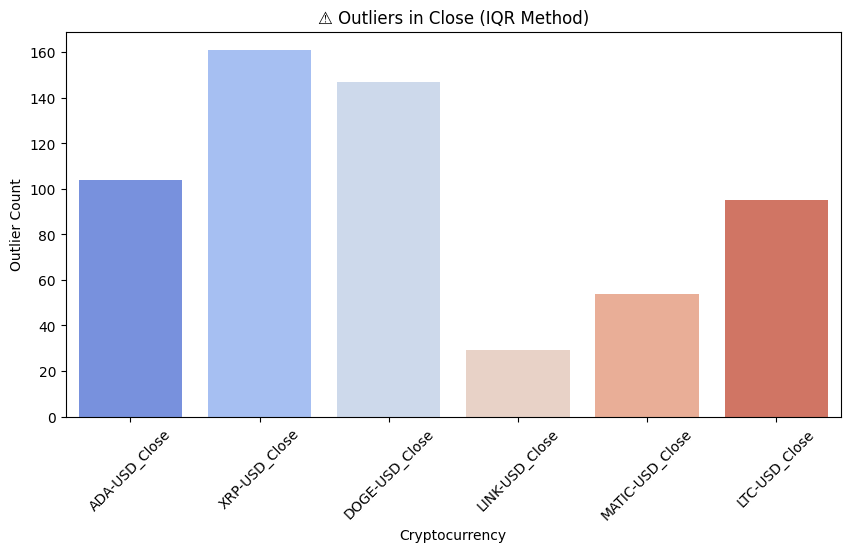

<ipython-input-4-942a93134e08>:82: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




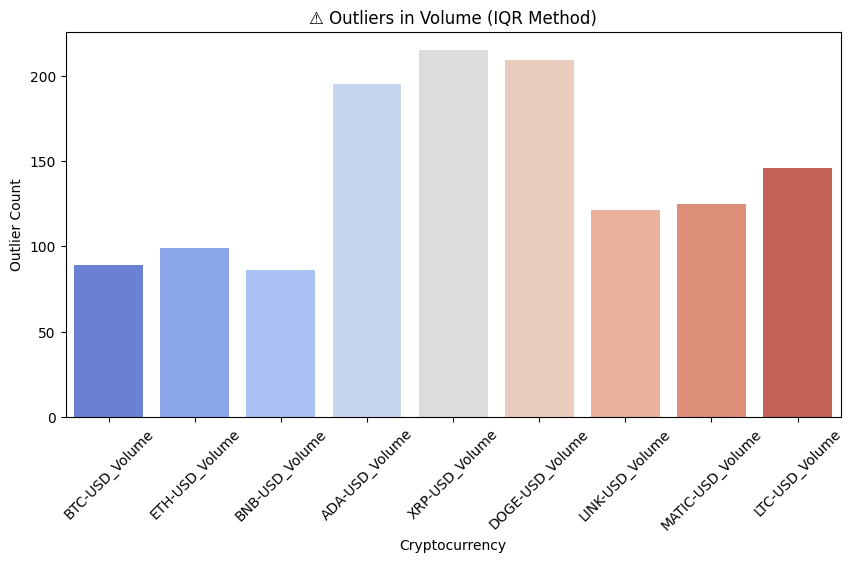

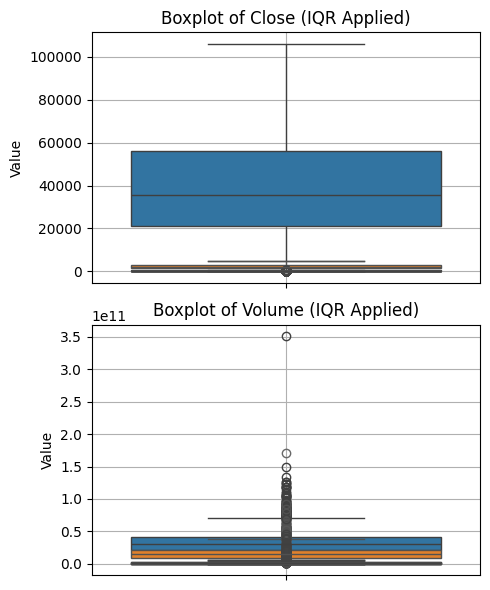

In [4]:
################################################ OUTLIER ANALYSIS ################################################
print("----------------------------------------- OUTLIER ANALYSIS ---------------------------------------")

############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

###############################  DYNAMIC GROUPED BOXPLOTS USING PLOTLY ###############################

for feature_type, columns in feature_groups.items():
    fig = go.Figure()
    for col in columns:
        fig.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))

    fig.update_layout(title=f" {feature_type.replace('_', ' ')} Boxplot",
                      yaxis=dict(title=feature_type),
                      xaxis=dict(title="Cryptocurrency"))
    fig.show()

############################### AUTO-DETECT OUTLIERS (IQR Method) ###############################

outlier_counts = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        if not outliers.empty:
            outlier_counts[col] = len(outliers)

############################### AUTO-DETECT OUTLIERS (Z-SCORE Method) ###############################

z_score_outliers = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()
        z_scores = zscore(data)
        outliers = data[(z_scores > 3) | (z_scores < -3)]
        if not outliers.empty:
            z_score_outliers[col] = len(outliers)

###############################  OUTLIER SUMMARY TABLE ###############################
# Structure for summary table
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Total Outliers (IQR)", "Total Outliers (Z-Score)"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        list(outlier_counts.keys()),
        list(outlier_counts.values()),
        [z_score_outliers.get(col, 0) for col in outlier_counts.keys()]
    ],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Outlier Summary (IQR & Z-Score)")
fig_summary.show()

###############################  DYNAMIC OUTLIER HISTOGRAMS ###############################
# Define structure for histograms (outliers)
def plot_outlier_histogram(outlier_dict, feature_type):
    """Plots histogram of outliers for a specific feature type."""
    if outlier_dict:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=list(outlier_dict.keys()), y=list(outlier_dict.values()), palette="coolwarm")
        plt.xticks(rotation=45)
        plt.title(f"⚠ Outliers in {feature_type} (IQR Method)")
        plt.xlabel("Cryptocurrency")
        plt.ylabel("Outlier Count")
        plt.show()

# Plot histograms dynamically for each feature group
for feature_type in feature_groups.keys():
    outlier_subset = {k: v for k, v in outlier_counts.items() if k.endswith(feature_type)}
    plot_outlier_histogram(outlier_subset, feature_type)

############################### DYNAMIC INDIVIDUAL CRYPTOCURRENCY BOXPLOTS ###############################
# Structure for boxplots
fig, axes = plt.subplots(nrows=len(feature_groups), ncols=1, figsize=(5, len(feature_groups) * 3))

for i, (feature_type, columns) in enumerate(feature_groups.items()):
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR for outlier detection
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        # Plot boxplot
        sns.boxplot(y=data, ax=axes[i])
        axes[i].set_title(f"Boxplot of {feature_type} (IQR Applied)")
        axes[i].set_ylabel("Value")
        axes[i].grid(True)

plt.tight_layout()
plt.show()


**Outlier Analysis**
- **Outliers**: Assets like **ADA-USD_Close** and **DOGE-USD_Volume** showed significant outliers.
- **Visualization**: Boxplots and histograms highlight extreme values, particularly in the highly volatile assets such as **BTC-USD** and **XRP-USD**.
- **Handling**: No specific adjustments were made for outliers as extreme values reflect inherent market volatility.

These extreme values are relevant for the modeling process, as they indicate critical market movements.


---


### **<font color='#474747'>*2.1.3 - Data Quality Checks*</font>**

----------------------------------------- DATA QUALITY CHECKS ---------------------------------------
- Automatically detected feature groups: ['Close', 'Volume']

- **Running Data Quality Checks Before Splitting...**



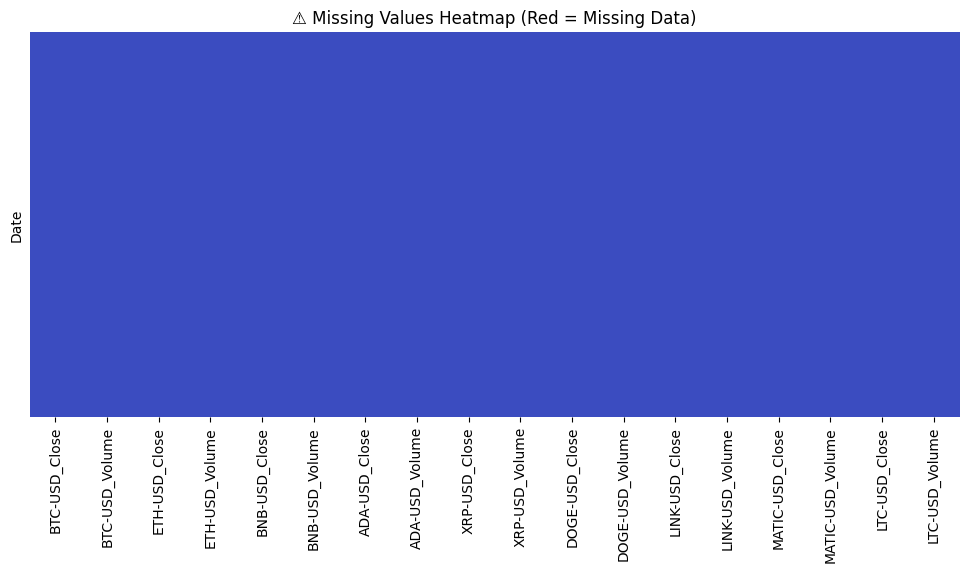


 **Data Quality Dashboard Complete! Ready for Feature Engineering.**



In [5]:
################################################# DATA QUALITY CHECKS ################################################
print("----------------------------------------- DATA QUALITY CHECKS ---------------------------------------")

############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

############################### DATA QUALITY CHECKS DASHBOARD ###############################
print("\n- **Running Data Quality Checks Before Splitting...**\n")

# Check for duplicate rows
duplicate_rows = final_df.duplicated().sum()

# Check for constant columns (cryptos that might have no variation)
constant_cols = [col for col in final_df.columns if final_df[col].nunique() == 1]

# Check for **negative/zero values** (applies to all detected feature groups)
negative_zero_counts = {
    col: (final_df[col] <= 0).sum()
    for feature, columns in feature_groups.items()
    for col in columns
    if (final_df[col] <= 0).sum() > 0
}

# Ensure the dataset index is **strictly** increasing in time
date_sorted = final_df.index.is_monotonic_increasing

# Check missing values after forward-filling
missing_after_fill = final_df.isnull().sum()
total_missing = missing_after_fill.sum()

# Dataset size
num_rows, num_cols = final_df.shape

############################### PRINT FULL ROWS WITH NEGATIVE OR ZERO VALUES ###############################
if negative_zero_counts:
    print("\n⚠ **Rows with Negative or Zero Values:**\n")
    for col in negative_zero_counts.keys():
        print(f" {col} has {negative_zero_counts[col]} negative or zero values:")
        display(final_df[final_df[col] <= 0][[col]])

############################### DISPLAY DATA QUALITY SUMMARY ###############################
fig_data_quality = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        ["Duplicate Rows", "Constant Value Columns", "Columns with Negative/Zero Values",
         "Dates Sorted", "Total Missing Values", "Dataset Shape"],
        [duplicate_rows, len(constant_cols), len(negative_zero_counts),
         date_sorted, total_missing, f"{num_rows} rows, {num_cols} columns"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_data_quality.update_layout(title_text="- Data Quality Summary")
fig_data_quality.show()

############################### VISUALIZATIONS FOR DATA QUALITY ISSUES ###############################

# Visualizing Missing Values (Heatmap)
plt.figure(figsize=(12, 5))
sns.heatmap(final_df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("⚠ Missing Values Heatmap (Red = Missing Data)")
plt.show()

# Visualizing **Negative/Zero Values** for All Feature Groups
if negative_zero_counts:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(negative_zero_counts.keys()), y=list(negative_zero_counts.values()), palette="Reds_r")
    plt.xticks(rotation=45)
    plt.title("⚠ Features with Negative/Zero Values")
    plt.xlabel("Feature")
    plt.ylabel("Count of Negative/Zero Values")
    plt.show()

print("\n **Data Quality Dashboard Complete! Ready for Feature Engineering.**\n")


**Analysis:** <br>
Data quality checks were performed to ensure dataset integrity. No duplicate or constant value columns were found. Some feature columns had negative or zero values, which were visualized. A heatmap confirmed no missing values after forward-filling, and the dataset was properly sorted chronologically. The data is now ready for splitting and fetaure engineering.

---



## **<font color='#474747'>2.2 - Split into Training, Validation & Test Set**

<font color='#646464'>**Time-Based Data Splitting**</font> <br>
<font color='#646464'> Given the nature of cryptocurrency data, which is non-stationary and starts at different times, it is essential to apply a time-based split rather than a static percentage-based one across the entire dataset. This ensures that each cryptocurrency is split based on its individual timeline, with the dataset for each asset divided into 50% for training, 25% for validation, and 25% for testing. By performing this split on each cryptocurrency separately, the risk of data leakage is eliminated, where future data might incorrectly inform past predictions. Additionally, this approach handles missing data efficiently, ensuring that newer cryptocurrencies with less historical data are not excluded or mishandled. The resulting splits are dynamically adjusted to reflect the available data for each cryptocurrency. To summarize the split sizes, a table is generated for each asset, showing the number of data points allocated to the training, validation, and test sets.
<br> <br>
This method not only respects the chronological order of cryptocurrency data but also ensures the integrity of model evaluation, allowing for more reliable and accurate portfolio optimization.</font>

### **<font color='#474747'>*2.2.1 - Time-based Splitting*</font>**

In [6]:
###############################  TIME-BASED DATA SPLITTING ###############################
# Define dictionaries to store the split datasets
train_data = {}
val_data = {}
test_data = {}
split_summary = {}

# Perform time-based split on the refined dataset (`df_selected`)
for col in final_df.columns:
    crypto_data = final_df[col].dropna()  # Ensure we're working with non-null data

    if len(crypto_data) < 10:  # Skip cryptos with insufficient data points
        print(f"⚠ Warning: Skipping {col} due to insufficient data points.")
        continue

    # Define split indices (50% train, 25% validation, 25% test)
    train_cutoff = int(len(crypto_data) * 0.5)
    val_cutoff = int(len(crypto_data) * 0.75)

    # Perform individual crypto splits
    train_data[col] = crypto_data.iloc[:train_cutoff]
    val_data[col] = crypto_data.iloc[train_cutoff:val_cutoff]
    test_data[col] = crypto_data.iloc[val_cutoff:]

    # Store split sizes for summary
    split_summary[col] = [len(train_data[col]), len(val_data[col]), len(test_data[col])]

### **<font color='#474747'>*2.2.2 - Elementary Data Analysis On Split Data*</font>**

In [7]:
############################### DISPLAY SPLIT SUMMARY ###############################
# Convert split summary to DataFrame
split_df = pd.DataFrame.from_dict(split_summary, orient='index', columns=['Train Size', 'Validation Size', 'Test Size'])

# Create a summary table using Plotly
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Size", "Validation Size", "Test Size"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[split_df.index, split_df["Train Size"], split_df["Validation Size"], split_df["Test Size"]],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Time-Based Data Split Summary Per Cryptocurrency")
fig_summary.show()

print(" - **Time-Based Data Splitting Completed!**")

############################### ELEMENTARY STATS FOR SELECTED FEATURES ###############################

# Initialize dictionary to store summary statistics
feature_summary = {}

# For loop
for col in train_data.keys():  # Using train_data since it's the raw prices split
    feature_summary[col] = [
        round(train_data[col].mean(), 2), round(train_data[col].std(), 2),
        round(val_data[col].mean(), 2), round(val_data[col].std(), 2),
        round(test_data[col].mean(), 2), round(test_data[col].std(), 2)
    ]

# Convert dictionary to DataFrame
feature_summary_df = pd.DataFrame.from_dict(
    feature_summary,
    orient='index',
    columns=['Train Mean', 'Train Std', 'Val Mean', 'Val Std', 'Test Mean', 'Test Std']
)

# Plot summary table for feature statistics
fig_feature_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Mean", "Train Std", "Validation Mean", "Validation Std", "Test Mean", "Test Std"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        feature_summary_df.index,
        feature_summary_df["Train Mean"], feature_summary_df["Train Std"],
        feature_summary_df["Val Mean"], feature_summary_df["Val Std"],
        feature_summary_df["Test Mean"], feature_summary_df["Test Std"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_feature_summary.update_layout(title_text="- Feature Statistics Summary Per Cryptocurrency")
fig_feature_summary.show()

print("\n **Feature Statistics Summary Ready!**")


 - **Time-Based Data Splitting Completed!**



 **Feature Statistics Summary Ready!**


**Analysis for Feature Considerations:** <br>
The mean and standard deviation (std) across training, validation, and test sets provide insight into the stability and variability of different assets. <br> <br>

**The main observations include**:  
- **BTC & ETH Prices**:  
  - BTC and ETH Close prices exhibit large standard deviations, indicating high volatility.  
  - The mean values remain relatively aligned across splits, suggesting that overall trends are preserved.  
  - The model will need to handle extreme fluctuations effectively.  

- **Trading Volume**:  
  - The standard deviation of BTC and ETH trading volumes is extremely high, especially in the test set.  
  - This suggests that market activity is highly volatile and varies significantly over time.  
  - The model may require additional feature engineering to capture liquidity changes effectively.  

- **Altcoins (ADA, XRP, DOGE, LINK, MATIC)**:  
  - Lower standard deviation compared to BTC and ETH, implying relative stability.  
  - However, test set variations in XRP and DOGE suggest that some altcoins experience occasional price swings.  

<br><br>
The dataset exhibits strong price fluctuations and varying levels of volatility across different cryptocurrencies. The model is expected to perform well on stable assets but may struggle with high-volatility assets like BTC and ETH unless proper techniques, such as volatility-adjusted features or log returns, are incorporated. Effective risk mitigation strategies, such as regularization and feature scaling, will be essential for achieving reliable predictions.

---

## **<font color='#474747'>2.3- Feature Engineering**


### **<font color='#474747'>*2.3.1 - Feature Engineering Pre-Analysis*</font>**
<font color='#646464'>The data is merged into a single DataFrame, and the correlation matrix is computed to analyze relationships between features. Columns are grouped by feature type (e.g. "Close", "Volume") and visualized in a heatmap to identify correlations. Highly correlated pairs (correlation > 0.8) are extracted and displayed for further analysis.</font>

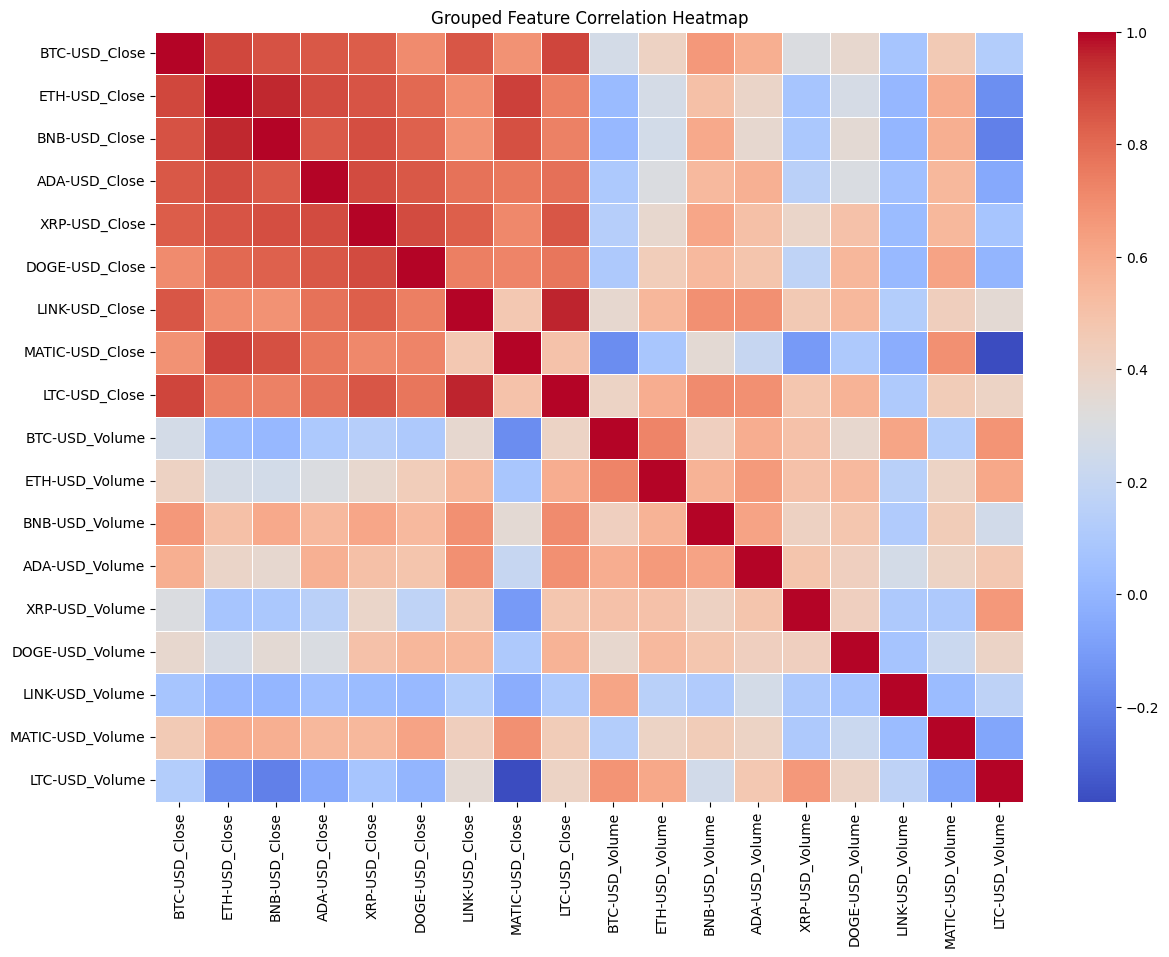


 **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847657
4,BTC-USD_Close,XRP-USD_Close,0.838512
6,BTC-USD_Close,LINK-USD_Close,0.854969
8,BTC-USD_Close,LTC-USD_Close,0.895449
18,ETH-USD_Close,BTC-USD_Close,0.889154
20,ETH-USD_Close,BNB-USD_Close,0.955522
21,ETH-USD_Close,ADA-USD_Close,0.881874
22,ETH-USD_Close,XRP-USD_Close,0.857794


In [8]:
############################### FEATURE ENGINEERING ###############################
# Convert train_data dictionary into a DataFrame
df_features = pd.DataFrame(train_data)  # Merging all crypto series into one DataFrame

# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix - group by feature group
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with grouped features
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Grouped Feature Correlation Heatmap")
plt.xticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=90)
plt.yticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=0)
plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

# Print results
print("\n **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis:**<br>
The heatmap shows strong correlations between major cryptocurrencies like BTC-USD and ETH-USD (0.89), indicating similar price movements. Pairs such as BTC-USD_Close and LTC-USD_Close (0.89) and ETH-USD_Close and MATIC-USD_Close (0.91) are highly correlated, suggesting potential for portfolio risk reduction through diversification. Correlations between price and volume vary, with some assets like DOGE-USD showing less predictable relationships. This analysis is crucial for optimizing portfolios and managing risk.

---

### **<font color='#474747'>*2.3.2 - Adding Features*</font>**
<font color='#646464'>New features are generated from the original data to enhance the model. These include:
1. **Log Returns**: Calculated for each cryptocurrency to assess daily percentage changes in price.
2. **Rolling Volatility (30-day)**: Measures price fluctuation over a 30-day window.
3. **Simple Moving Averages (SMA)**: 7-day and 30-day moving averages are computed to capture short-term and long-term price trends.
4. **Relative Strength Index (RSI)**: Indicates overbought or oversold conditions.
5. **MACD (Moving Average Convergence Divergence)**: Measures the relationship between short- and long-term price trends.
6. **Drawdowns**: Measures the peak-to-trough decline in price to assess risk and volatility during downturns.</font>

In [9]:
############################### FEATURE ENGINEERING - ADDING FEATURES ###############################
# Convert `train_data` dictionary into a DataFrame
df_features = pd.DataFrame(train_data)

# Ensure Index is in Proper DateTime Format
df_features.index = pd.to_datetime(df_features.index, errors='coerce')
df_features = df_features.sort_index()

# Initialize Feature Dictionary
new_features = {}

# Iterate over columns and generate only **relevant** features
for col in df_features.columns:
    if '_Close' in col:
        crypto_name = col.replace('_Close', '')

        # Ensure values are numeric to prevent NaN propagation
        df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

        # 1. **Log Returns**
        new_features[f'{crypto_name}_Log_Return'] = np.log(df_features[col] / df_features[col].shift(1))

        # 2.**Rolling Volatility (30-day)**
        new_features[f'{crypto_name}_Volatility_30d'] = (
            new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()
        )

        # 3. **Simple Moving Averages (SMA)**
        new_features[f'{crypto_name}_SMA_7D'] = df_features[col].rolling(window=7).mean()
        new_features[f'{crypto_name}_SMA_30D'] = df_features[col].rolling(window=30).mean()

        # 4. **Relative Strength Index (RSI)**
        delta = df_features[col].diff()
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)

        avg_gain = pd.Series(gain, index=df_features.index).rolling(window=14, min_periods=1).mean()
        avg_loss = pd.Series(loss, index=df_features.index).rolling(window=14, min_periods=1).mean()

        rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
        new_features[f'{crypto_name}_RSI'] = (100 - (100 / (1 + rs))).round(2)

        # 5. **MACD (Moving Average Convergence Divergence)**
        short_ema = df_features[col].ewm(span=12, adjust=False).mean()
        long_ema = df_features[col].ewm(span=26, adjust=False).mean()
        macd_line = short_ema - long_ema
        signal_line = macd_line.ewm(span=9, adjust=False).mean()

        new_features[f'{crypto_name}_MACD'] = macd_line.round(2)
        new_features[f'{crypto_name}_MACD_Signal'] = signal_line.round(2)

# Convert New Features to DataFrame & Round Values to 2 Decimals
df_new_features = pd.DataFrame(new_features).round(2).fillna(method='bfill').fillna(0)  # Handle missing values

# Identify Log Return Features (For drawdown calculation)
log_return_features = [col for col in df_new_features.columns if '_Log_Return' in col]

if log_return_features:
    print("\n - Computing Drawdowns for Log Returns...")

    def calculate_drawdowns(series):
        """ Optimized drawdown calculation for Log Returns only """
        series = series.replace([np.inf, -np.inf], np.nan).fillna(0)
        cumulative_returns = np.exp(series.cumsum().clip(-50, 50))
        peak = cumulative_returns.cummax()
        drawdown = (cumulative_returns - peak) / peak
        return drawdown.round(2)

    # Apply Drawdown Calculation
    drawdown_features = df_new_features[log_return_features].apply(calculate_drawdowns).add_suffix("_Drawdown")

    # Append Drawdown Features
    df_new_features = pd.concat([df_new_features, drawdown_features], axis=1)

# Combine All Features & Round Again to Ensure Consistency
df_features = pd.concat([df_features, df_new_features], axis=1).round(2)

# Drop NaN values that result from shifting operations
df_features.dropna(inplace=True)

############################### DISPLAY SUMMARY ###############################
print("\n **Feature Engineering Complete! Summary of New Features:**\n")
display(df_features.describe())

# Check Final DataFrame Shape
print("\n - **Final DataFrame Shape:**", df_features.shape)


<ipython-input-9-e2efb29a46ab>:53: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.




 - Computing Drawdowns for Log Returns...

 **Feature Engineering Complete! Summary of New Features:**



,BTC-USD_Close,BTC-USD_Volume,ETH-USD_Close,ETH-USD_Volume,BNB-USD_Close,BNB-USD_Volume,ADA-USD_Close,ADA-USD_Volume,XRP-USD_Close,XRP-USD_Volume,...,LTC-USD_MACD_Signal,BTC-USD_Log_Return_Drawdown,ETH-USD_Log_Return_Drawdown,BNB-USD_Log_Return_Drawdown,ADA-USD_Log_Return_Drawdown,XRP-USD_Log_Return_Drawdown,DOGE-USD_Log_Return_Drawdown,LINK-USD_Log_Return_Drawdown,MATIC-USD_Log_Return_Drawdown,LTC-USD_Log_Return_Drawdown
count,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,...,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000
mean,31609.063308,3.763052e+10,1834.067448,2.011992e+10,250.465279,1.720860e+09,0.837809,2.180011e+09,0.584337,4.094080e+09,...,0.004217,-0.250274,-0.247218,-0.294228,-0.347218,-0.411752,-0.499869,-0.449671,-0.377908,-0.438510
std,17418.750896,1.954623e+10,1325.130995,1.039194e+10,198.837481,1.729390e+09,0.732398,2.544957e+09,0.361792,4.644966e+09,...,8.026742,0.213240,0.212111,0.193344,0.277520,0.226141,0.285573,0.273662,0.223755,0.271229
min,4970.790000,1.225260e+10,110.610000,5.109033e+09,9.390000,1.365992e+08,0.020000,6.484569e+07,0.140000,4.987595e+08,...,-27.150000,-0.720000,-0.770000,-0.710000,-0.860000,-0.820000,-0.920000,-0.900000,-0.880000,-0.890000
25%,11878.370000,2.590558e+10,399.920000,1.343309e+10,28.080000,4.344649e+08,0.120000,6.071842e+08,0.260000,1.628784e+09,...,-3.790000,-0.410000,-0.400000,-0.440000,-0.590000,-0.580000,-0.770000,-0.680000,-0.530000,-0.670000
50%,33746.000000,3.349994e+10,1803.910000,1.755705e+10,286.050000,1.384576e+09,0.640000,1.227753e+09,0.490000,2.380083e+09,...,-0.010000,-0.210000,-0.200000,-0.290000,-0.300000,-0.400000,-0.500000,-0.470000,-0.390000,-0.450000
75%,46188.450000,4.406839e+10,2934.140000,2.357156e+10,405.020000,2.200879e+09,1.310000,2.798264e+09,0.830000,4.325860e+09,...,3.530000,-0.060000,-0.060000,-0.120000,-0.090000,-0.210000,-0.270000,-0.200000,-0.200000,-0.220000
max,67566.830000,3.509679e+11,4812.090000,8.448291e+10,675.680000,1.798295e+10,2.970000,1.914198e+10,1.840000,3.695518e+10,...,25.890000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



 - **Final DataFrame Shape:** (913, 90)


### **<font color='#474747'>*2.3.3 -  Feature Selection Analysis*</font>**

#### **<font color='#474747'>*Feature Importance (Random Forests)*</font>**
<font color='#646464'> The feature importance analysis using the Random Forest model highlights which features have the most predictive power for the target variable, in this case, the log returns for BTC-USD, as most digital assets exhibit strong correlation with Bitcoin</font>


Training Random Forest for BTC-USD_Log_Return...

Model training complete for BTC-USD_Log_Return!


<ipython-input-10-d752067de965>:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




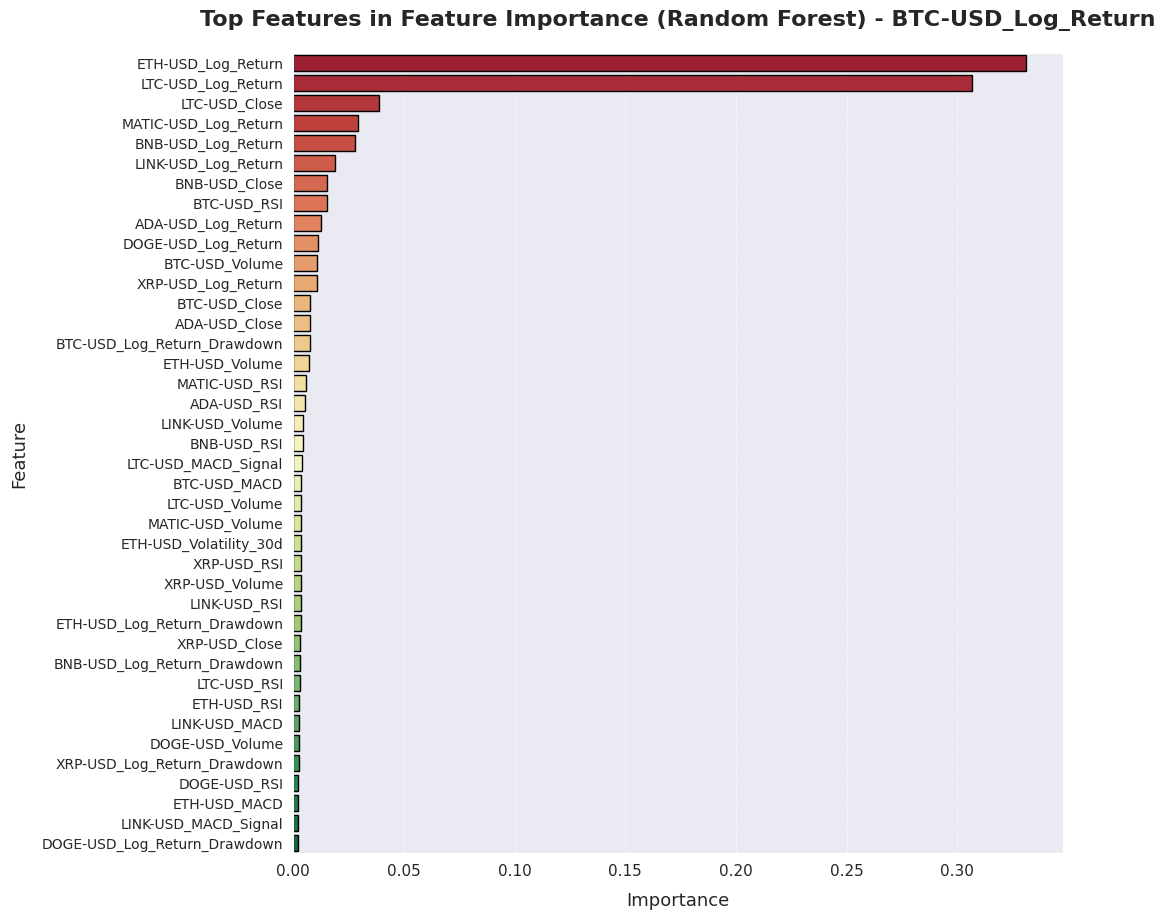


 **Feature Importance Analysis Complete for Selected Cryptos.**


In [10]:
############################### FEATURE ANALYSIS RANDOM FORESTS ###############################
# Set global Seaborn style for clean, professional plots
sns.set_style("darkgrid")

# Selected target cryptocurrency
selected_cryptos = ["BTC-USD_Log_Return"]
log_return_targets = [col for col in df_features.columns if col in selected_cryptos]

# Ensure at least one target is found
if not log_return_targets:
    raise ValueError("X - No Log Return columns found for BTC, ETH, or BNB. Ensure feature engineering includes log returns.")

# Function for training and feature importance analysis
def train_and_plot(target):
    print(f"\nTraining Random Forest for {target}...\n")

    # Define Features & Target
    X = df_features.drop(columns=[target])  # Drop the current target variable
    y = df_features[target]  # Predicting the current crypto's log return

    # Split Data into Train & Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest Model
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)  # Reduce trees and use parallel jobs
    model.fit(X_train, y_train)
    print(f"Model training complete for {target}!")

    # Feature Importance Analysis
    feature_importances = model.feature_importances_
    features = X.columns

    importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances}).sort_values(
        by="Importance", ascending=False
    )

    # Limit to top 20 features for better visualization
    importance_df = importance_df.head(40)

    # Plot Feature Importance
    plt.figure(figsize=(14, 10))
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette="RdYlGn",
        edgecolor="black"
    )

    plt.title(f"Top Features in Feature Importance (Random Forest) - {target}", fontsize=16, pad=20, fontweight="bold")
    plt.xlabel("Importance", fontsize=13, labelpad=10)
    plt.ylabel("Feature", fontsize=13, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=10, ha="right")
    plt.subplots_adjust(left=0.4, right=0.95, top=0.9, bottom=0.1)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.show()

# Train model and plot for selected target
for target in log_return_targets:
    train_and_plot(target)

# Final summary
print("\n **Feature Importance Analysis Complete for Selected Cryptos.**")


**Analysis:** <br>
 The bar plot shows the top features that most influence the model's prediction, with ETH-USD_Log_Return and LTC-USD_Close emerging as the most significant predictors. In terms of feature importance, we see that log returns, volume, close prices, RSI, MACD, MACD Signal and Drawdown appear in the top features where as Volatiltiy 30D, SMA 7D and SMA 30D do not appear whatsoever. This plays a huge role in which fetaures to keep and remove.

---

### **<font color='#474747'>*2.3.4 - Feature Selection Finalization*</font>**

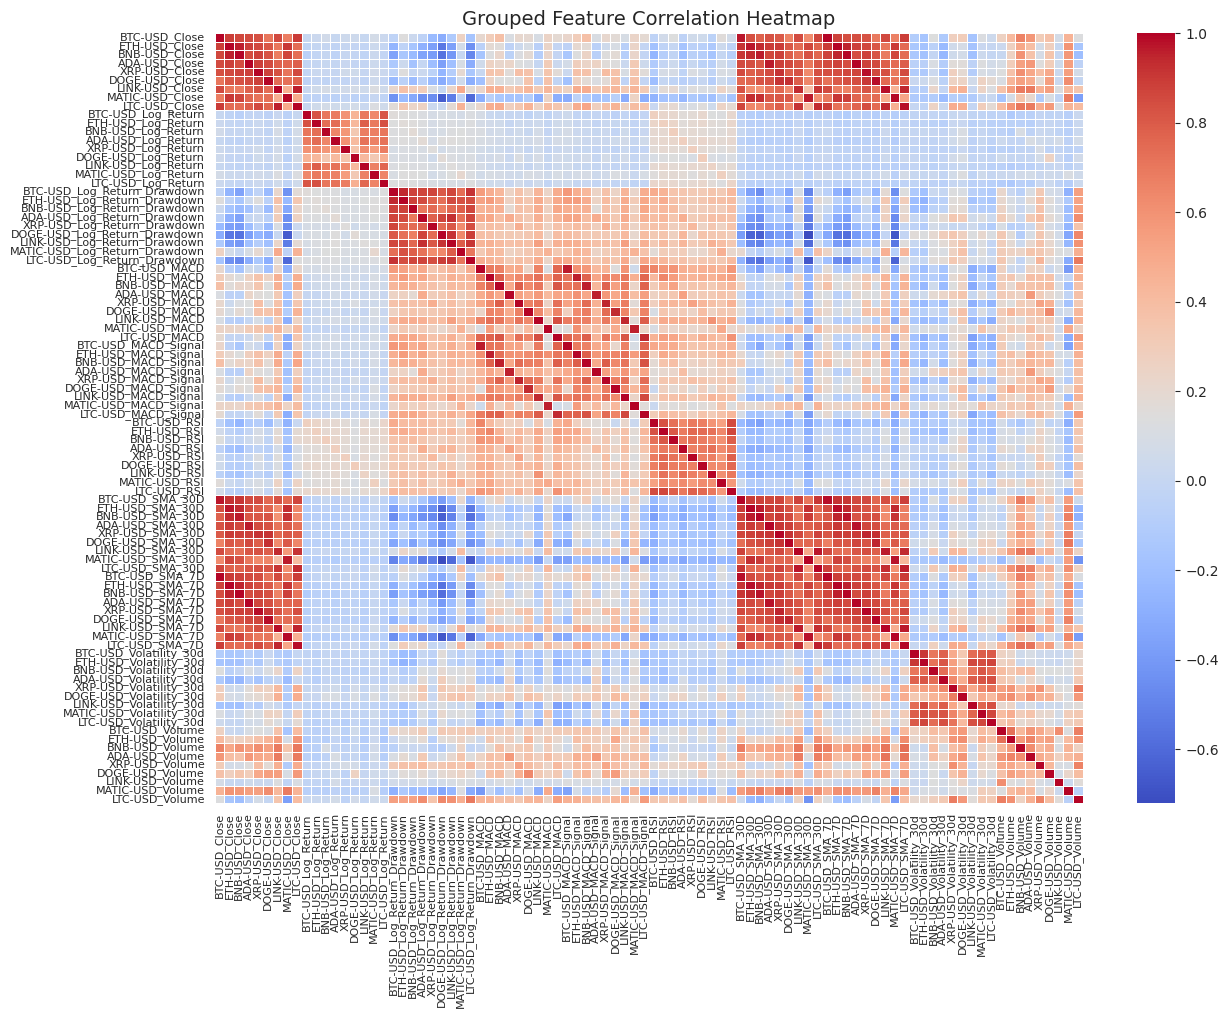


 **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847636
4,BTC-USD_Close,XRP-USD_Close,0.838535
6,BTC-USD_Close,LINK-USD_Close,0.854971
...,...,...,...
7190,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
7273,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
7275,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382
7278,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670


In [11]:
############################### FEATURE SELECTION ###############################
# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Grouped Feature Correlation Heatmap", fontsize=14)

# Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis**: <br>
The grouped correlation heatmap highlights strong interdependencies between feature groups - particularly among close prices, SMAs, MACDs, RSIs, and volatility indicators - across cryptocurrencies. Notably, BTC-USD_Close is highly correlated with other close prices (i.e. ETH: 0.889, BNB: 0.862, LTC: 0.895), underscoring BTC’s central influence [shown in Section 2.3.3].

<br><br>

The clearest signs of redundancy appear among the following technical indicators:<br>
* SMA 7D and SMA 30D correlate above 0.98 with each other and with the underlying close prices (e.g. BTC-USD_SMA_7D: 0.994 with BTC-USD_Close).
* MACD and MACD Signal correlations exceed 0.95 across assets.
* Drawdown and RSI metrics show moderate-to-high correlations (typically 0.80–0.93).

<br><br>

From a feature selection standpoint, these patterns indicate that multiple indicators within the same group offer overlapping information. Therefore, retaining just one representative feature per group - such as either Close price, SMA 7D or SMA 30D - reduces redundancy and improves model interpretability. Removing highly correlated features (r > 0.8) enhances training efficiency and mitigates multicollinearity without compromising predictive performance.


---

#### <font color='#474747'>**Feature Selection Summary**</font>

**<font color='#8b0000'>Features Removed:</font>** <br>
<font color='#8b0000'>- Simple Moving Averages: `_SMA_7D`, `_SMA_30D`</font>  
<font color='#8b0000'>- Volume-Based Metrics: `_Volume`, `_Volume_Change`</font>  
<font color='#8b0000'>- Log Return Drawdown: `_Log_Return_Drawdown`</font>  
<font color='#8b0000'>- MACD Signal: `_MACD_Signal`</font>  

<br>

**<font color='#006700'>Features Retained:</font>** <br>
<font color='#006700'>- Price Metrics: `_Close`, `_Log_Return`</font>  
<font color='#006700'>- MACD Indicators: `_MACD`</font>  
<font color='#006700'>- Relative Strength Index (RSI): `_RSI`</font>  
<font color='#006700'>- Other derived indicators not flagged for removal</font>  

<br>

<font color='#646464'>Features were dropped based on high within-group correlations and feature redundancy identified during correlation analysis. For example, SMAs were strongly correlated with price data (e.g. BTC-USD_SMA_7D vs. BTC-USD_Close: 0.994), suggesting limited additional signal. Removing these improves model parsimony, reduces multicollinearity, and enhances interpretability without sacrificing predictive power.</font>


In [12]:
###############################  FEATURE SELECTION (Optimized for Portfolio Optimization) ###############################

# Define Feature Removal Flags
remove_sma = True                     # Remove all SMA features (_SMA_7D and _SMA_30D)
remove_volume = True                 # Remove all _Volume features (including _Volume_Change)
remove_macd = False                  # Keep MACD, but remove MACD_Signal separately
remove_rsi = False                   # Keep RSI
remove_log_return_drawdown = True   # Remove all _Log_Return_Drawdown features

# Identify Columns to Remove
features_to_drop = []

for col in df_features.columns:
    if remove_sma and ("_SMA_7D" in col or "_SMA_30D" in col):
        features_to_drop.append(col)
    if remove_volume and ("_Volume" in col or "_Volume_Change" in col):
        features_to_drop.append(col)
    if remove_macd and "_MACD" in col:
        features_to_drop.append(col)
    if "_MACD_Signal" in col:  # Always remove MACD Signal
        features_to_drop.append(col)
    if remove_rsi and "_RSI" in col:
        features_to_drop.append(col)
    if remove_log_return_drawdown and "_Log_Return_Drawdown" in col:
        features_to_drop.append(col)

# Drop Selected Features
df_selected = df_features.drop(columns=features_to_drop, errors='ignore')

# Confirm Shape After Feature Selection
print("\n **Feature Selection Completed! Final Data Shape:**", df_selected.shape)
print(f"Removed {len(features_to_drop)} Features")
display(df_selected.head())



 **Feature Selection Completed! Final Data Shape:** (913, 45)
Removed 45 Features


,BTC-USD_Close,ETH-USD_Close,BNB-USD_Close,ADA-USD_Close,XRP-USD_Close,DOGE-USD_Close,LINK-USD_Close,MATIC-USD_Close,LTC-USD_Close,BTC-USD_Log_Return,...,LINK-USD_RSI,LINK-USD_MACD,MATIC-USD_Log_Return,MATIC-USD_Volatility_30d,MATIC-USD_RSI,MATIC-USD_MACD,LTC-USD_Log_Return,LTC-USD_Volatility_30d,LTC-USD_RSI,LTC-USD_MACD
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-01,8562.45,218.97,18.96,0.05,0.23,0.0,3.88,0.02,57.96,0.04,...,0.0,0.00,0.09,0.16,0.0,0.0,0.05,0.11,0.00,0.00
2020-03-02,8869.67,230.57,19.81,0.05,0.24,0.0,4.22,0.02,61.00,0.04,...,100.0,0.03,0.09,0.16,100.0,0.0,0.05,0.11,100.00,0.24
2020-03-03,8787.79,224.48,19.64,0.05,0.23,0.0,4.58,0.02,61.14,-0.01,...,100.0,0.08,0.10,0.16,100.0,0.0,0.00,0.11,100.00,0.44
2020-03-04,8755.25,224.52,19.96,0.05,0.23,0.0,4.64,0.03,60.38,-0.00,...,100.0,0.12,0.07,0.16,100.0,0.0,-0.01,0.11,80.71,0.53
2020-03-05,9078.76,229.27,20.80,0.05,0.24,0.0,4.72,0.03,62.05,0.04,...,100.0,0.16,0.05,0.16,100.0,0.0,0.03,0.11,86.42,0.73


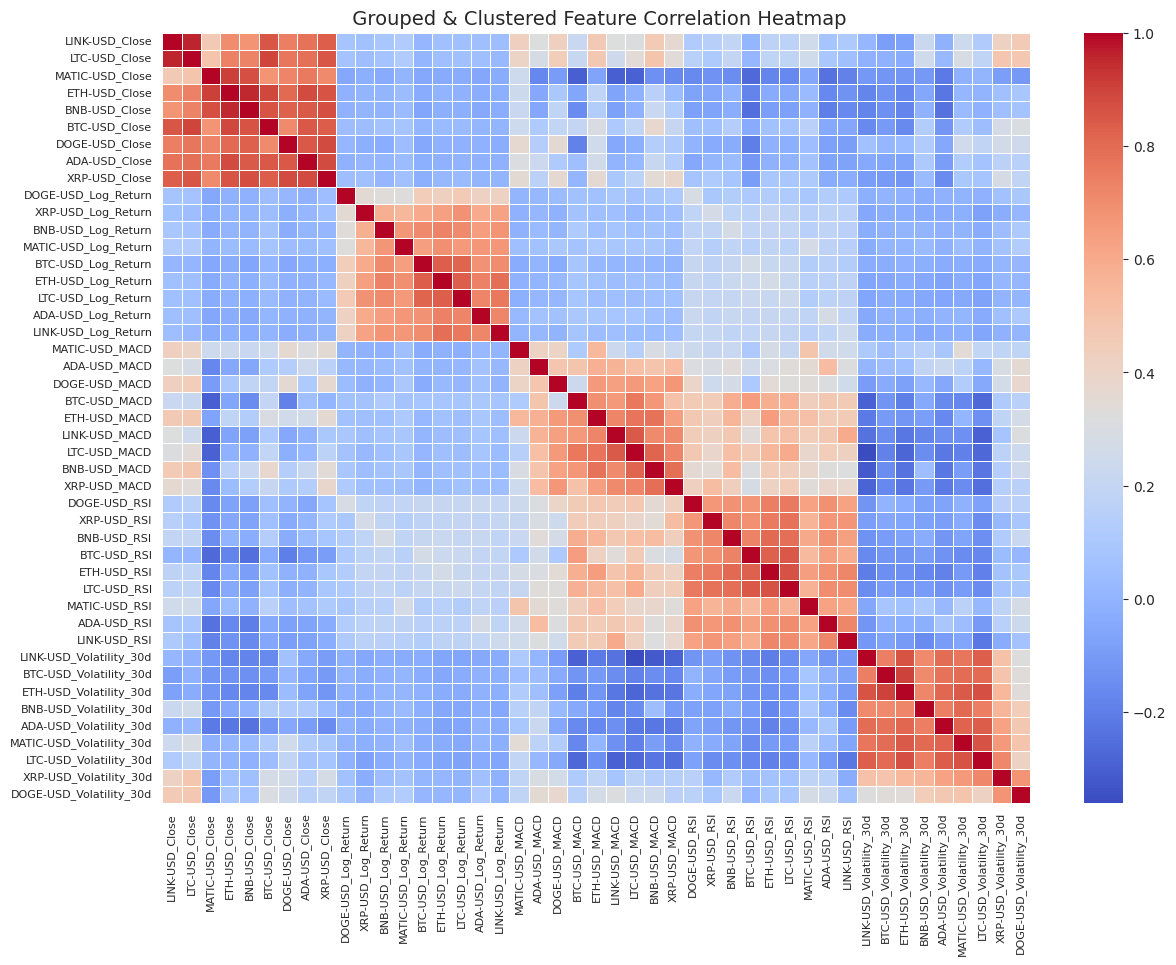


 **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,LINK-USD_Close,LTC-USD_Close,0.958220
5,LINK-USD_Close,BTC-USD_Close,0.854971
8,LINK-USD_Close,XRP-USD_Close,0.834097
45,LTC-USD_Close,LINK-USD_Close,0.958220
50,LTC-USD_Close,BTC-USD_Close,0.895449
...,...,...,...
1887,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
1926,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670
1928,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
1930,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382


In [13]:
###############################  Dynamic Feature Grouping ###############################
# Compute correlation matrix
corr_matrix = df_selected.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

#  Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_selected.columns}

# Sort features by group name
sorted_features = sorted(df_selected.columns, key=lambda x: feature_groups[x])

#   Apply Hierarchical Clustering Within Each Group
final_sorted_features = []
unique_groups = sorted(set(feature_groups.values()))  # Unique sorted group names

for group in unique_groups:
    group_features = [f for f in sorted_features if feature_groups[f] == group]

    if len(group_features) > 1:  # Only apply clustering if multiple features exist
        sub_corr_matrix = df_selected[group_features].corr()

        if not sub_corr_matrix.isnull().values.all():  # Ensure clustering is possible
            linked = linkage(sub_corr_matrix.fillna(0), method='ward')
            ordered_indices = leaves_list(linked)
            ordered_group_features = [group_features[i] for i in ordered_indices]
        else:
            ordered_group_features = group_features  # No clustering needed

        final_sorted_features.extend(ordered_group_features)
    else:
        final_sorted_features.extend(group_features)

#  Reorder correlation matrix with new feature ordering
corr_matrix = corr_matrix.loc[final_sorted_features, final_sorted_features]

# Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title(" Grouped & Clustered Feature Correlation Heatmap", fontsize=14)

# Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

###############################  Identifying Highly Correlated Features ###############################

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis:** <br>
The updated heatmap confirms reduced multicollinearity, with retained features like Close, Log Return, MACD, RSI and Volatility 30d showing manageable correlations while preserving key market signals.

---


---
---
# **<font color = '#000058'>Chapter 3 - Data Analysis</font>** <br>
<font color='#646464'>Data analysis forms the foundation for all downstream modeling steps. It enables us to understand the structure, quality, and statistical properties of the dataset, detect patterns, and identify anomalies or redundancies. Through visual and numerical summaries, we gain critical insight into feature distributions, interrelationships, and suitability for model development. This chapter includes statistical summaries, risk-return analysis, correlation insights and line plots - each contributing to a deeper understanding of the data and guiding subsequent feature selection and model design.</font>


## **<font color='#474747'>3.1 - Statistical Summary**

In [14]:
############################### FEATURE SUMMARY ANALYSIS (All Features) ###############################
# Identify Feature Groups Dynamically
feature_summary = {}

for col in df_selected.columns:
    # Extract feature category dynamically
    match = re.search(r'_(Close|SMA_\d+d|Log_Return|Volatility_\d+d|Volume|MarketCap_to_Volume|RSI|MACD)$', col)

    if match:
        feature_type = match.group(1)  # Extract feature type
        crypto_name = col.replace(f"_{feature_type}", "")  # Extract crypto name
        data = df_selected[col].dropna()  # Drop NaN values

        # Compute statistics only if there is sufficient data
        if len(data) > 1:
            if feature_type not in feature_summary:
                feature_summary[feature_type] = {}

            feature_summary[feature_type][crypto_name] = [
                round(data.count(), 4), round(data.mean(), 4), round(data.std(), 4),
                round(data.max() - data.min(), 4), round(median_abs_deviation(data), 4),
                round(skew(data), 4), round(kurtosis(data), 4),
                round(data.min(), 4), round(data.quantile(0.25), 4),
                round(data.median(), 4), round(data.quantile(0.75), 4), round(data.max(), 4)
            ]

# Convert to DataFrames & Plot
summary_columns = ['Count', 'Mean', 'Std Dev', 'Range', 'MAD', 'Skewness', 'Kurtosis',
                   'Min', '25%', '50% (Median)', '75%', 'Max']

# Generate Summary Tables for Each Feature Type
for feature_type, summary_data in feature_summary.items():
    feature_summary_df = pd.DataFrame.from_dict(summary_data, orient='index', columns=summary_columns)

    # Drop NaN values before plotting
    feature_summary_df.dropna(inplace=True)

    # Plotly Table for each feature type
    fig = go.Figure(data=[go.Table(
        columnwidth=[150] + [70] * len(feature_summary_df.columns),  # Adjust width dynamically
        header=dict(values=["Cryptocurrency"] + list(feature_summary_df.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[
            feature_summary_df.index,  # Ensure longer column width for crypto names
            feature_summary_df["Count"], feature_summary_df["Mean"], feature_summary_df["Std Dev"],
            feature_summary_df["Range"], feature_summary_df["MAD"],
            feature_summary_df["Skewness"], feature_summary_df["Kurtosis"],
            feature_summary_df["Min"], feature_summary_df["25%"], feature_summary_df["50% (Median)"],
            feature_summary_df["75%"], feature_summary_df["Max"]
        ],
        fill_color='lavender',
        align='left'))
    ])

    # Update layout
    fig.update_layout(title_text=f"- Statistical Summary ({feature_type})")
    fig.show()

    print(f"\n **Dashboard-Style Summary Completed for {feature_type}!**")



 **Dashboard-Style Summary Completed for Close!**



 **Dashboard-Style Summary Completed for Log_Return!**



 **Dashboard-Style Summary Completed for Volatility_30d!**



 **Dashboard-Style Summary Completed for RSI!**



 **Dashboard-Style Summary Completed for MACD!**


**Analysis**: <br>
To understand input behaviour and assess suitability for modeling, key summary statistics were computed per feature group:
- **Close Prices**:  
  Wide mean and std ranges observed, e.g. BTC (mean ≈ 15,100, std ≈ 12,480), vs. MATIC (mean ≈ 0.67). Median < mean for most, indicating mild right skew. High price volatility evident.

- **Log Returns**:  
  Near-zero means across assets. Heavy kurtosis (MATIC ≈ 10.2), negative skewness (ADA ≈ -0.24), confirming asymmetric and fat-tailed return distributions.

- **Volatility (30d)**:  
  DOGE, MATIC, and BNB show highest mean volatilities (≥0.07), with narrow but positively skewed ranges—consistent with volatility clustering in crypto.

- **RSI**:  
  Mean RSI values hover near 50, reflecting neutral momentum. Standard deviation ~18 across assets implies frequent oscillation between oversold and overbought zones.

- **MACD**:  
  BTC and ETH exhibit the strongest momentum trends (high std and range), while DOGE and XRP maintain near-zero MACD, suggesting limited trend signals.

<br><br>

Feature behaviour varies significantly across assets, with higher-cap coins like BTC and ETH showing stable trends, while smaller coins (DOGE, MATIC) display higher volatility and extreme return behavior—critical for portfolio modeling and risk-aware feature selection.


<!--  -->

## **<font color='#474747'>3.2 - Data Visualizations**

### **<font color='#474747'>*3.2.1 - Histogram & KDE*</font>**

<ipython-input-15-a515021a01ef>:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-15-a515021a01ef>:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-15-a515021a01ef>:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-15-a515021a01ef>:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-15-a515021a01ef>:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



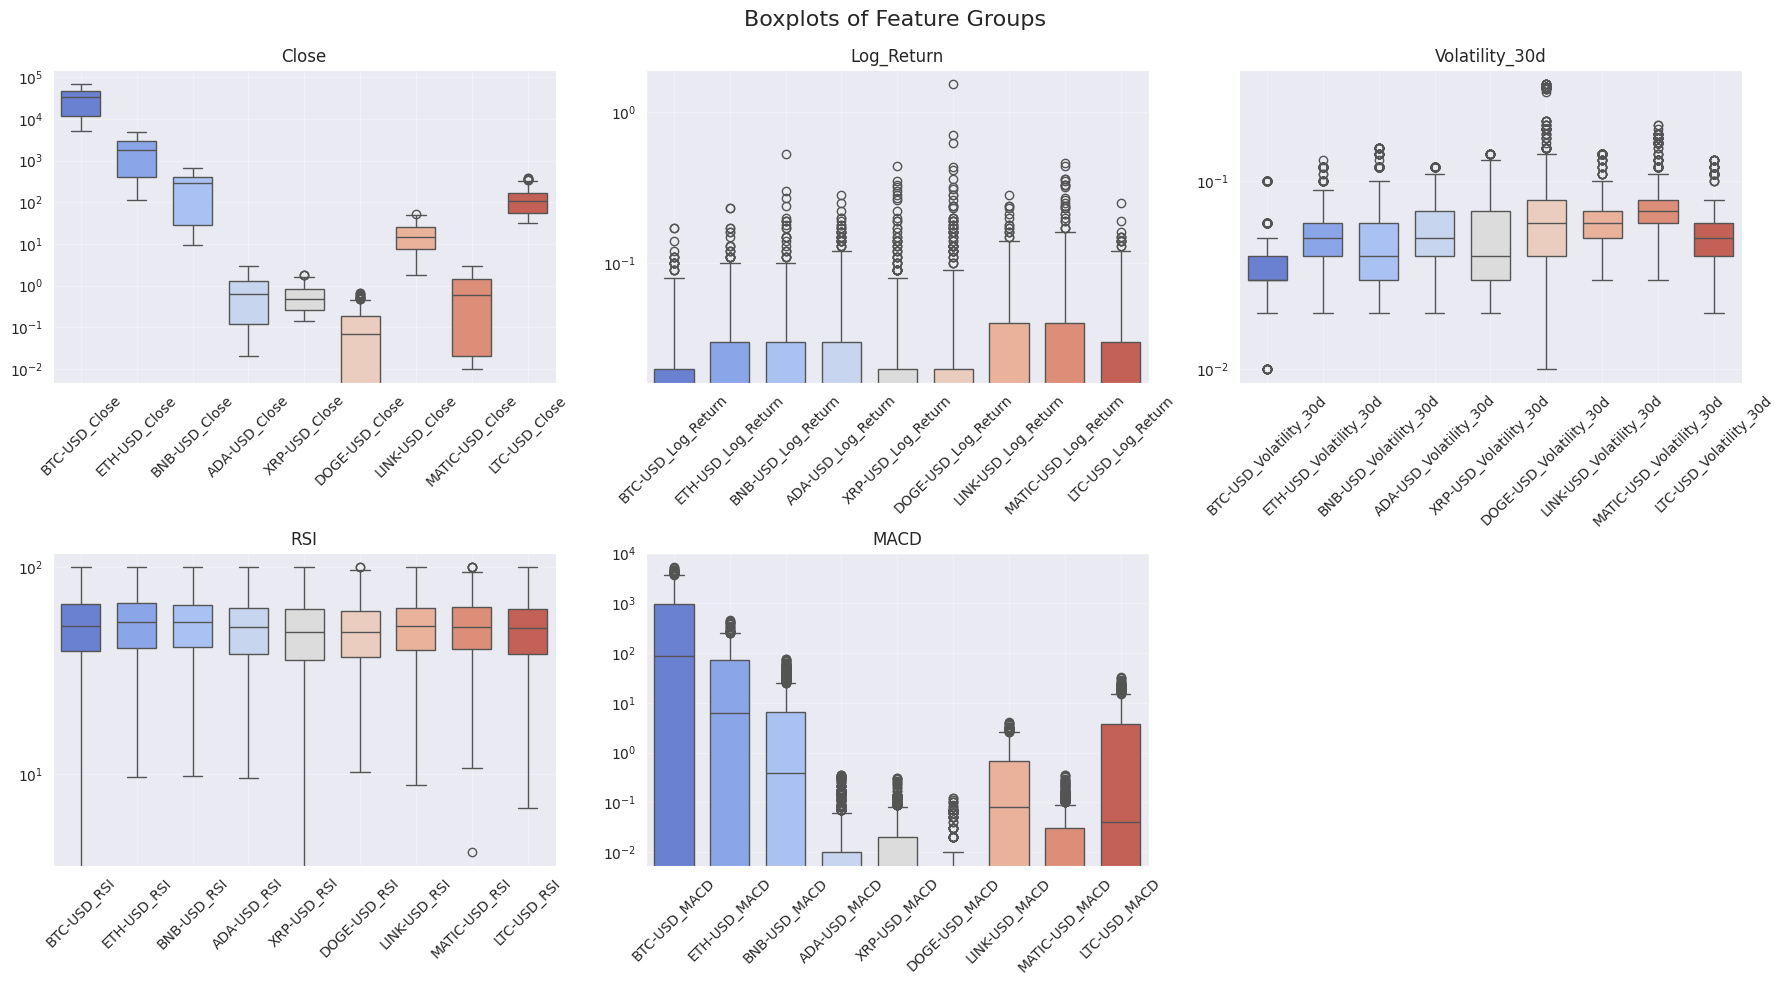

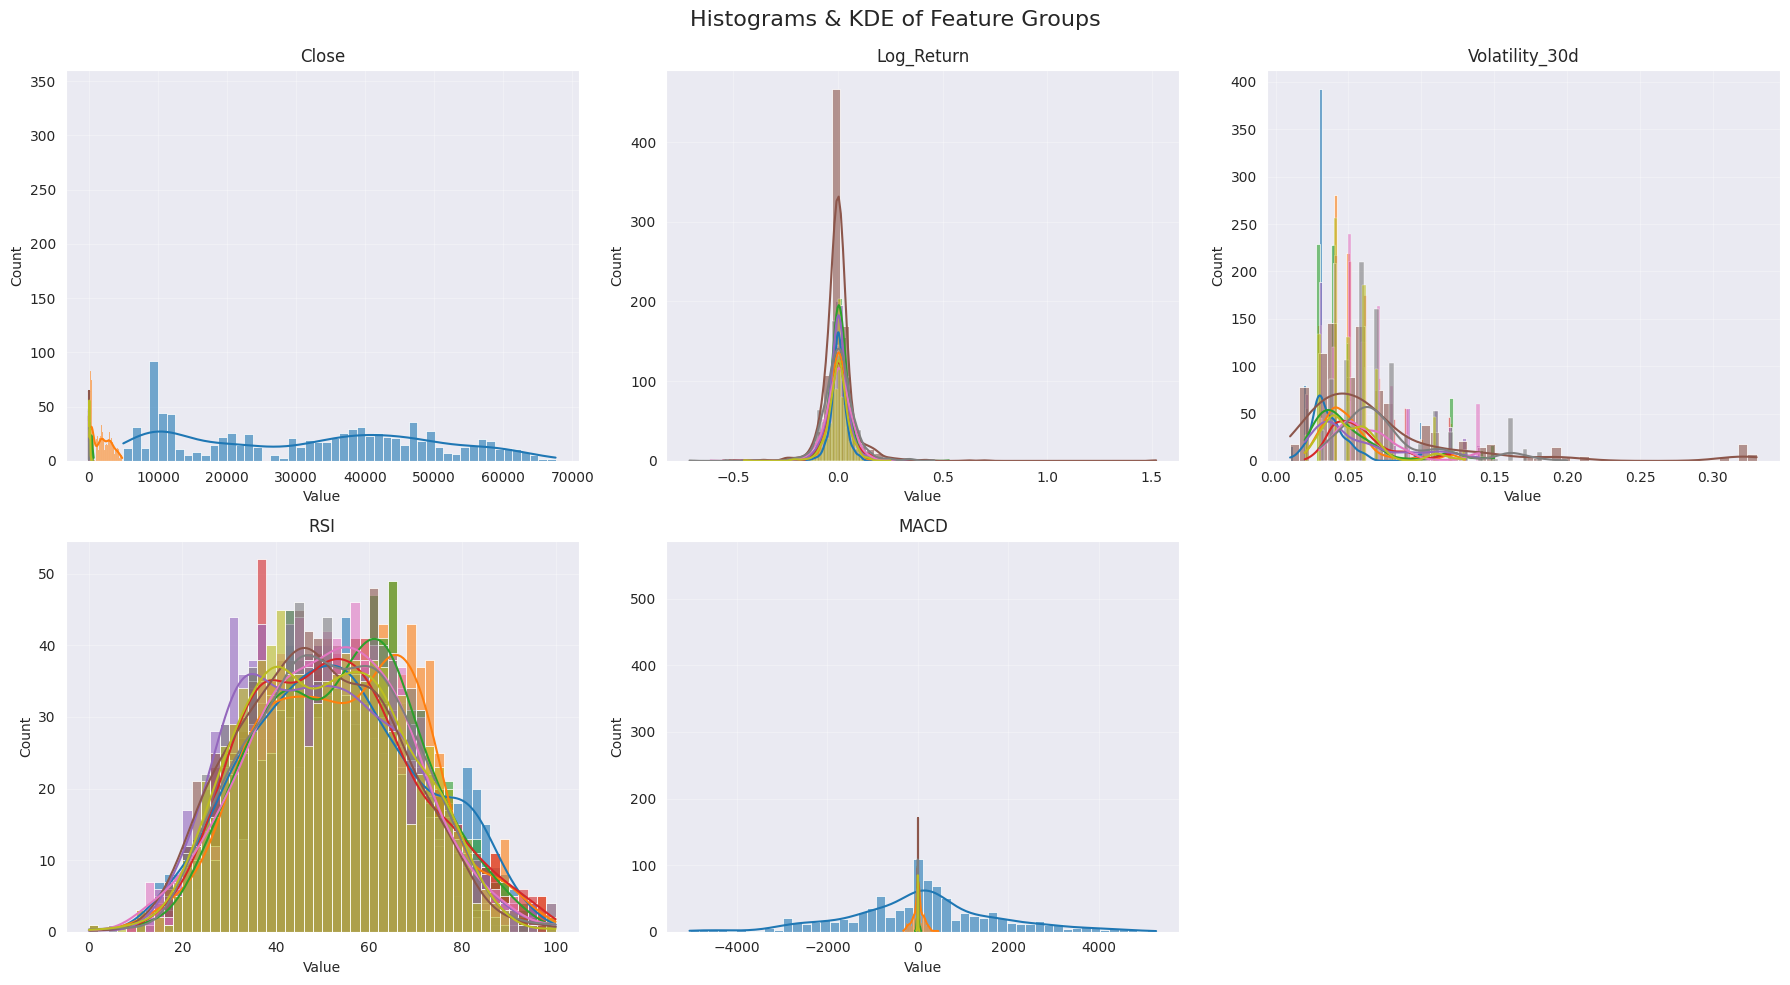


 **Dynamic Feature Grouping & Visualization Completed!**


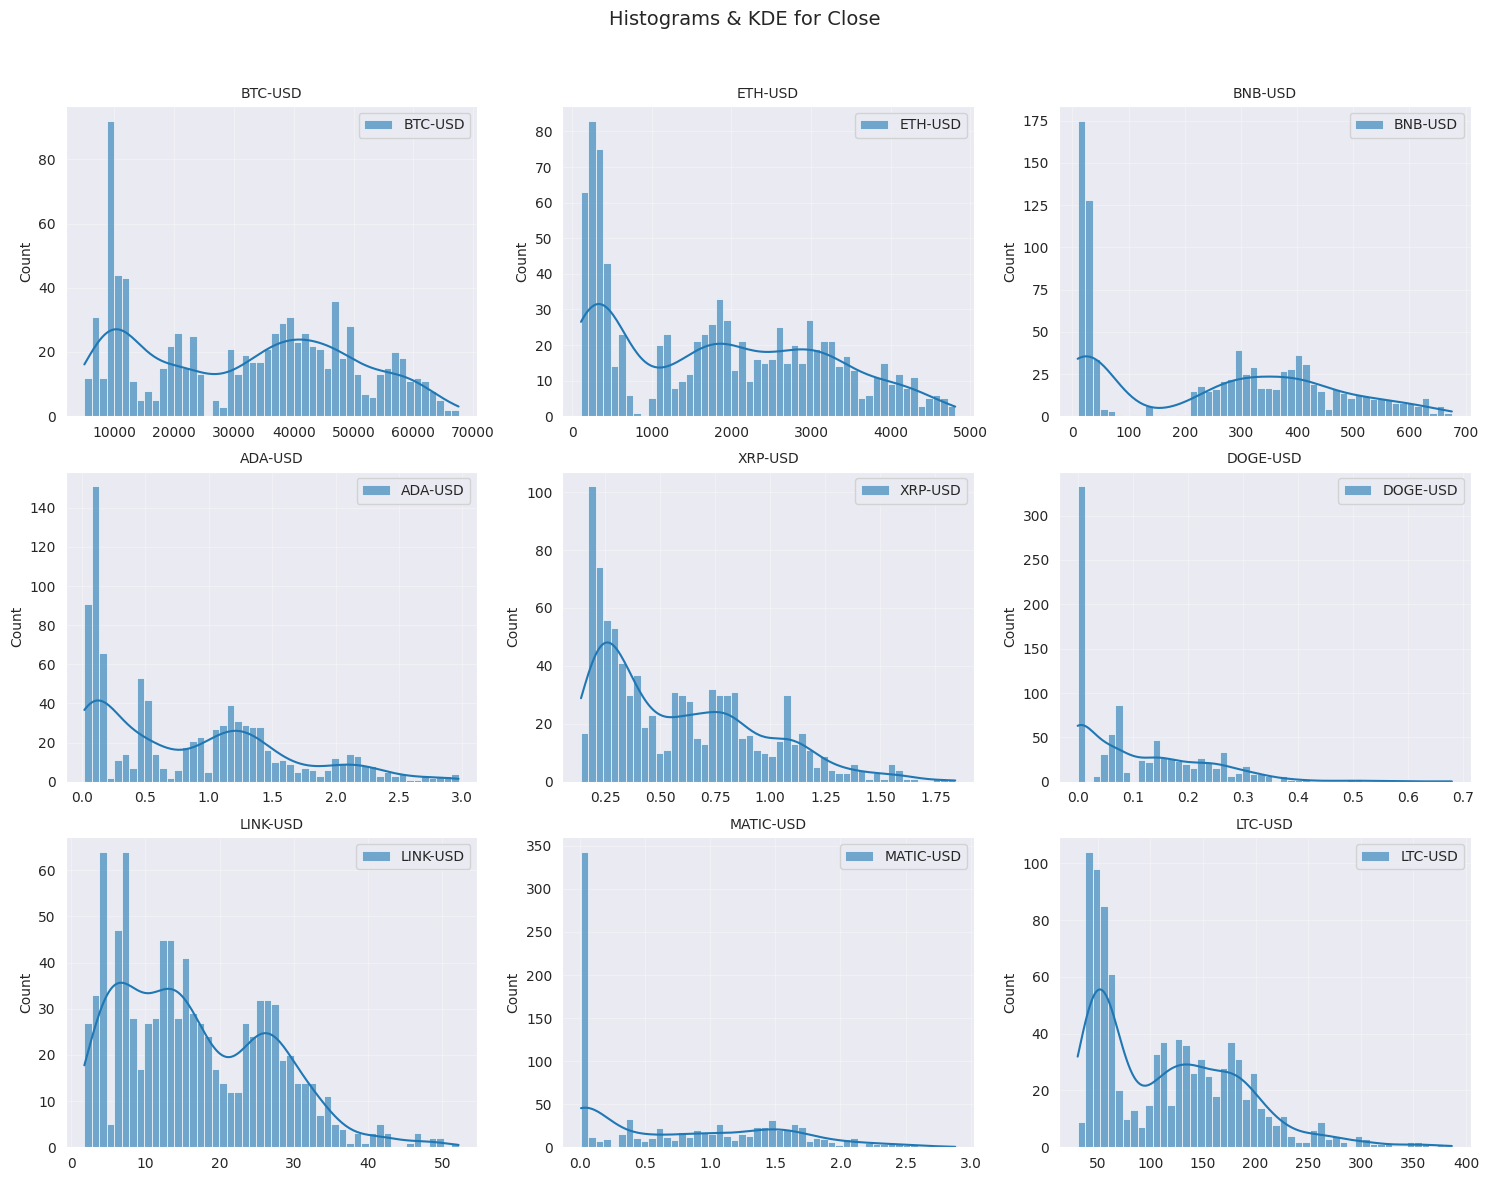

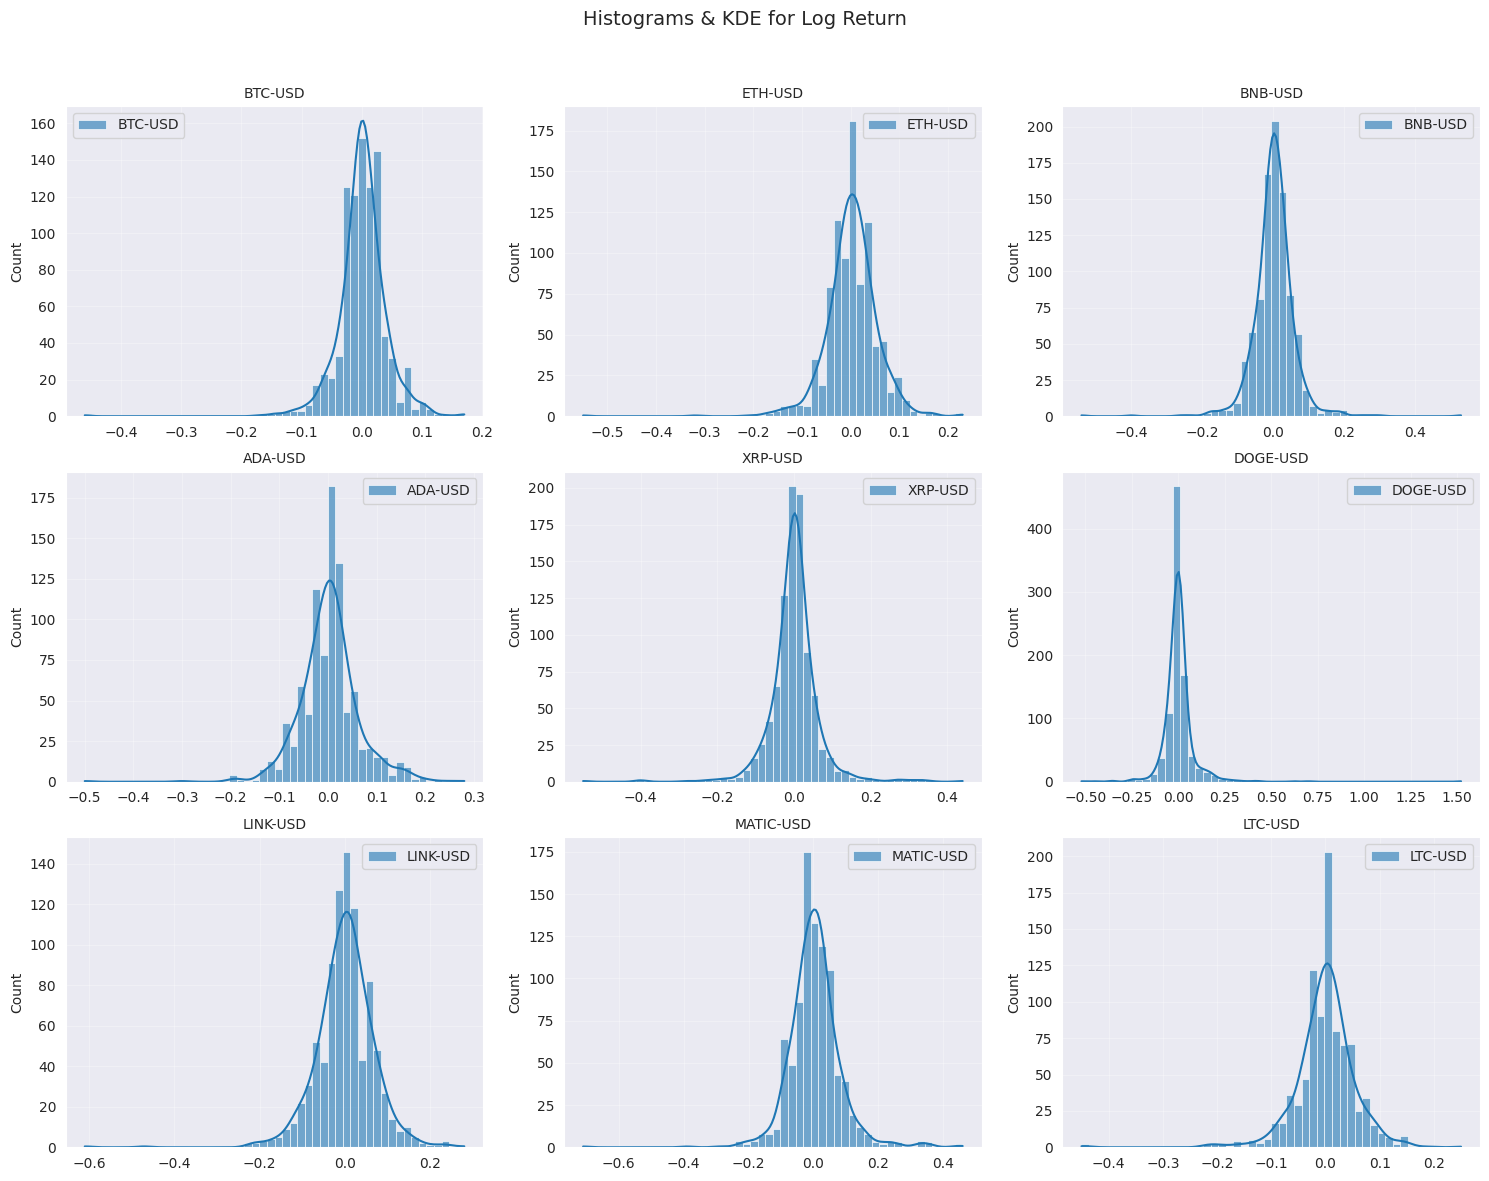

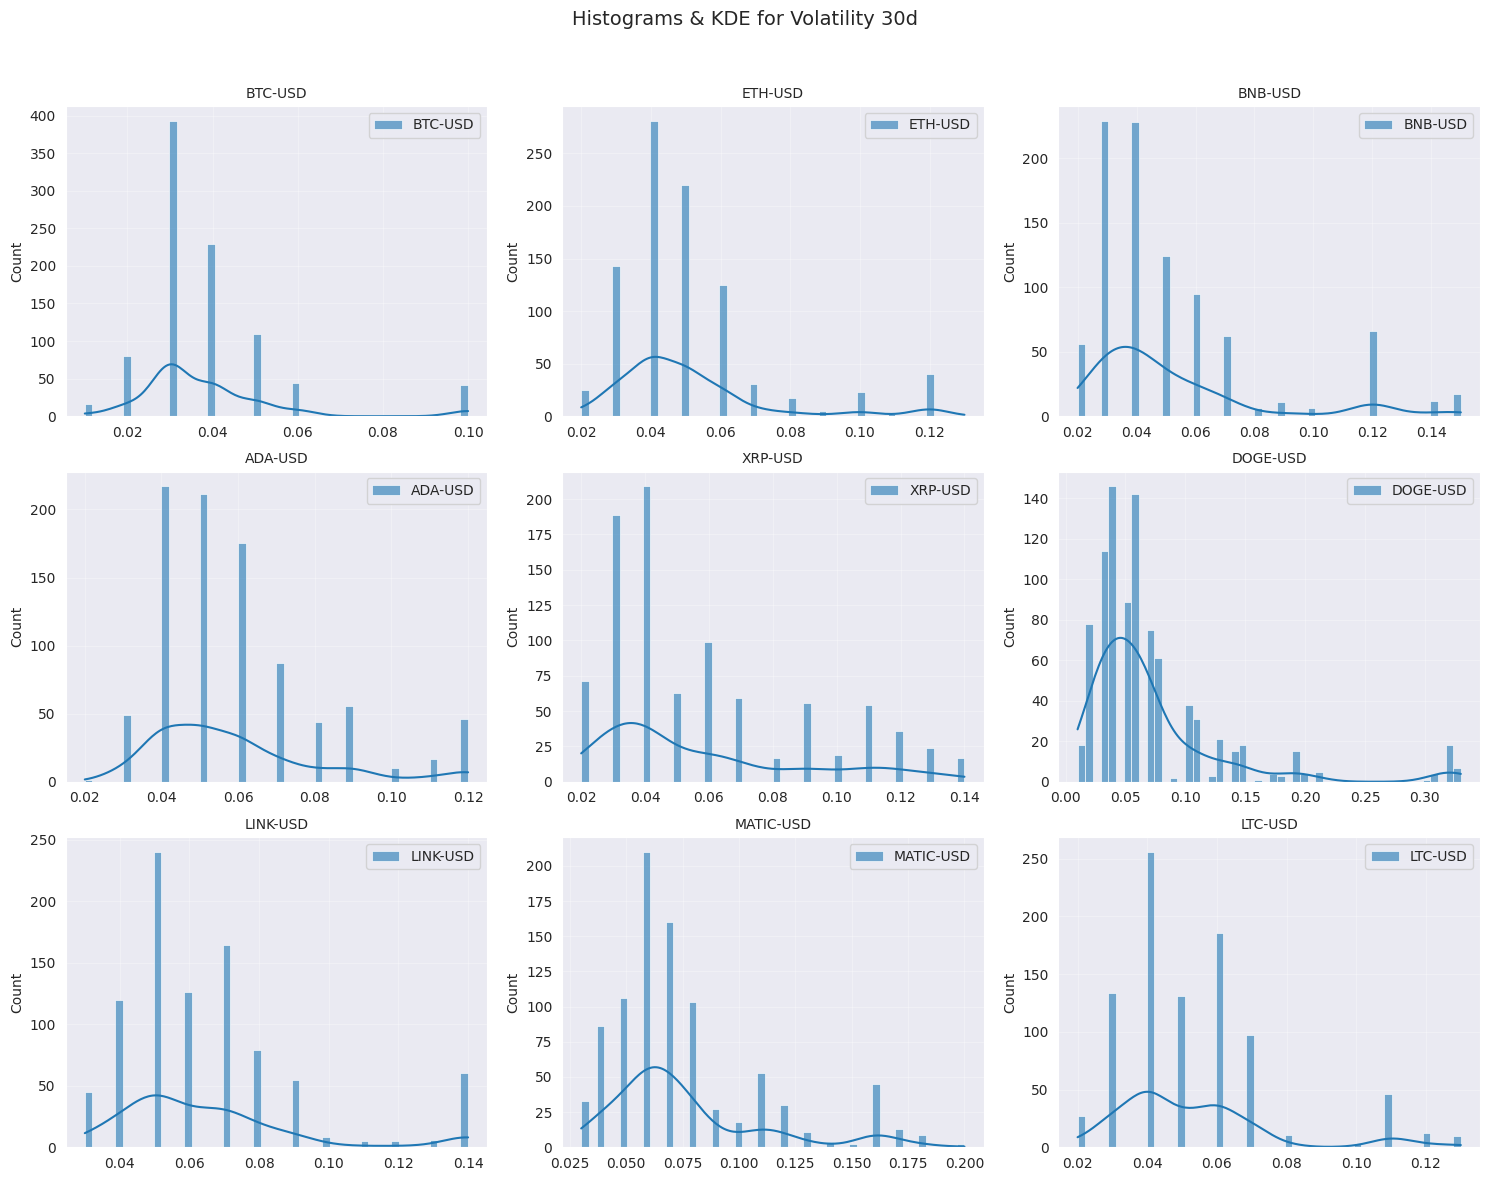

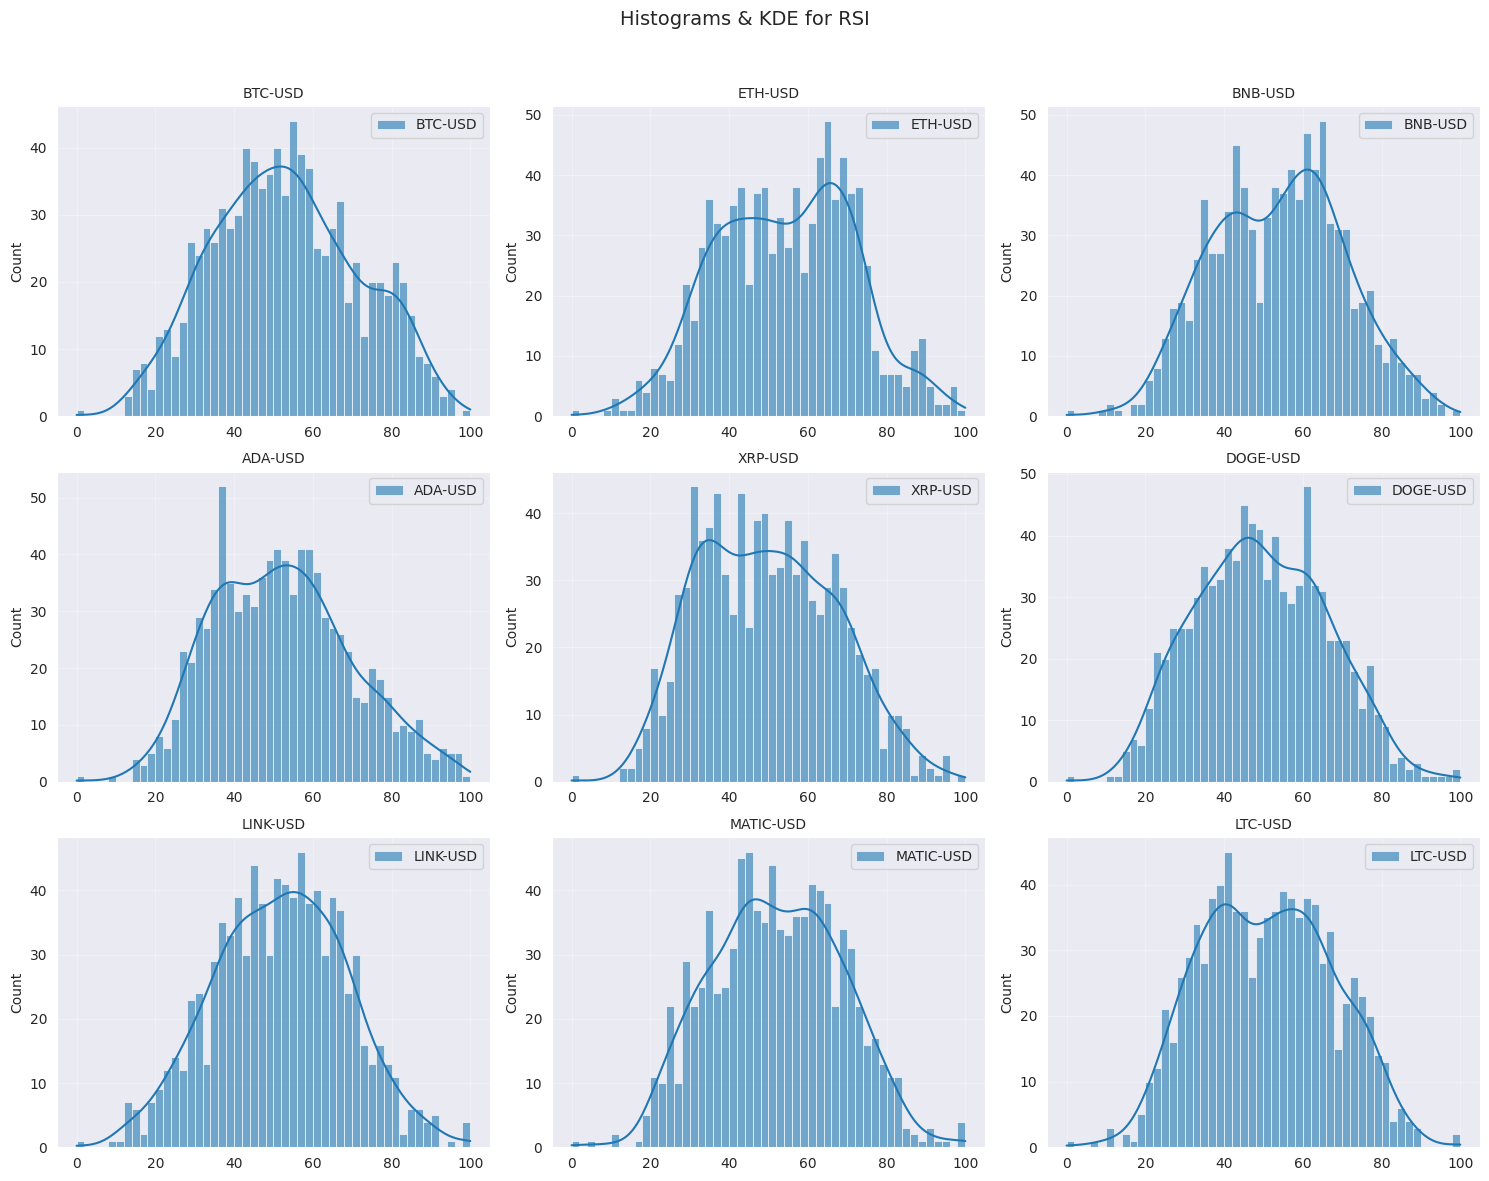

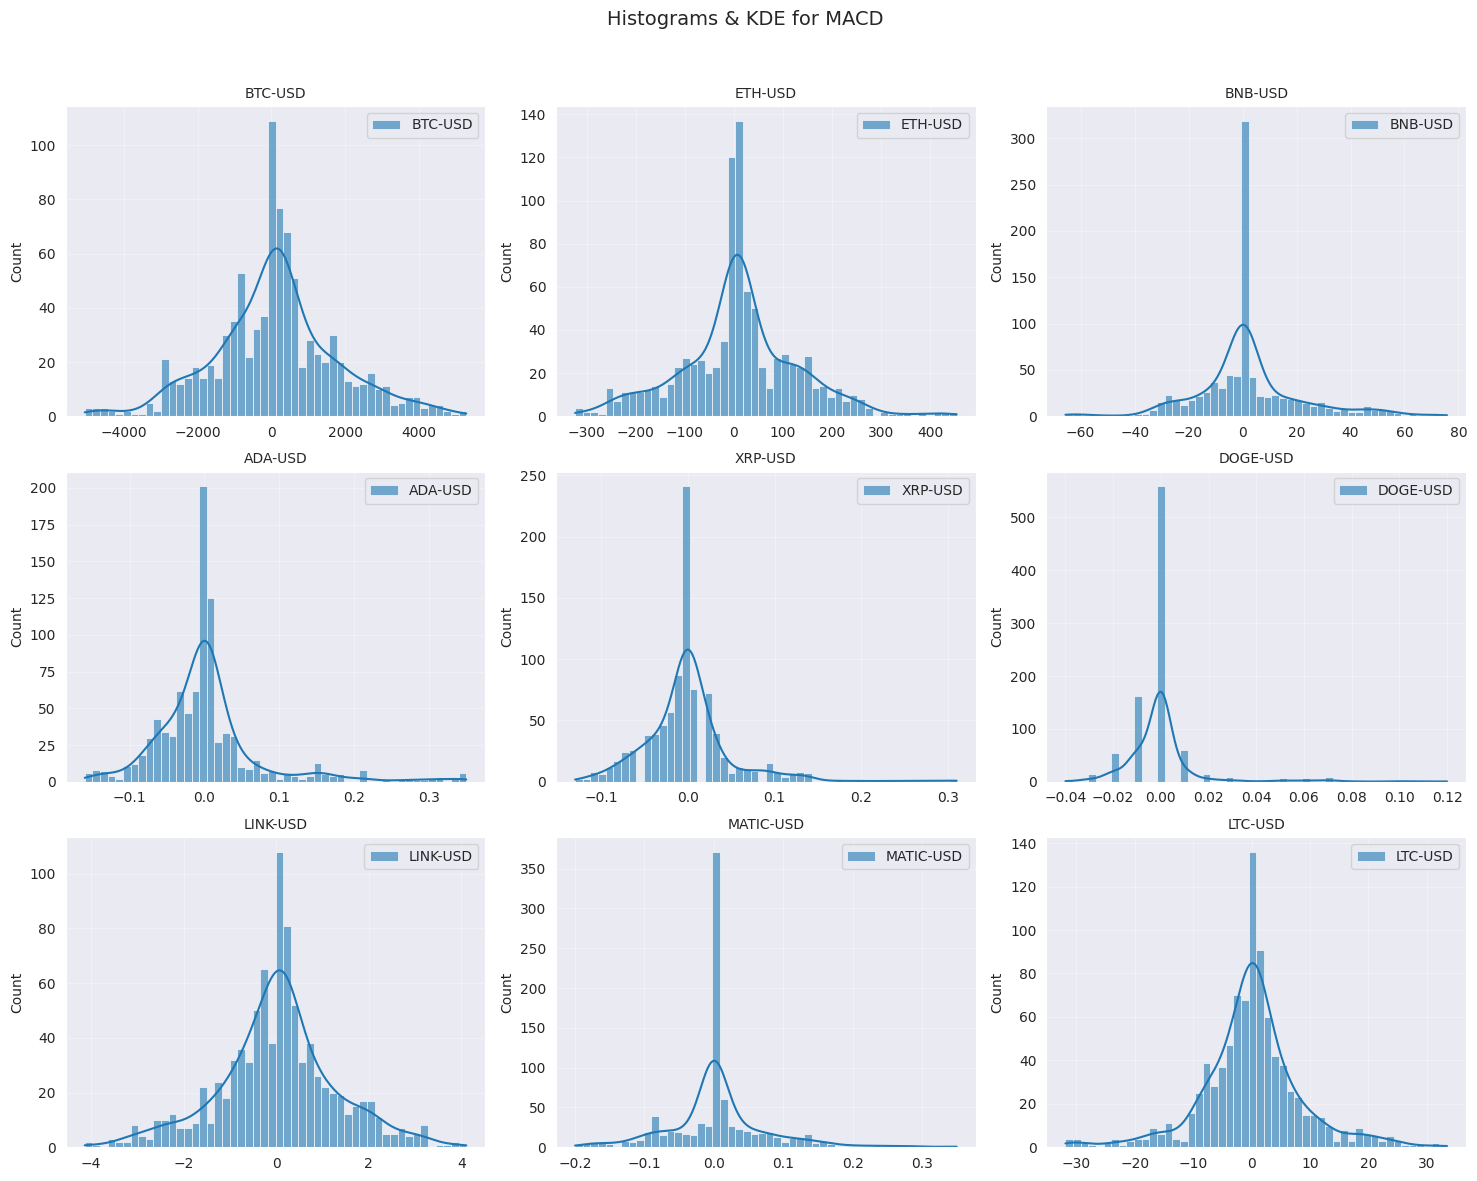

In [15]:
############################### AUTO-DETECT FEATURE GROUPS ###############################
# Identify Unique Feature Groups Based on Column Names
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type (assumes naming convention "{crypto}_{feature}")
    feature_type = col.split("_", 1)[-1]  # Everything after the first "_"

    # Add to dictionary
    feature_groups.setdefault(feature_type, []).append(col)

############################### BOXPLOTS: DYNAMICALLY GROUPED FEATURES ###############################

def plot_boxplots(feature_groups, dataset, plots_per_row=3):
    """
    Plots boxplots 3 per row while keeping each feature group separate.
    """
    group_names = list(feature_groups.keys())
    num_groups = len(group_names)
    num_rows = math.ceil(num_groups / plots_per_row)  # Compute required rows

    fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(18, num_rows * 5))
    fig.suptitle("Boxplots of Feature Groups", fontsize=16)

    axes = axes.flatten()  # Convert to 1D array for iteration

    for i, group_name in enumerate(group_names):
        feature_list = feature_groups[group_name]

        if not feature_list:
            continue  # Skip empty groups

        sns.boxplot(data=dataset[feature_list], showfliers=True, width=0.7, palette="coolwarm", ax=axes[i])
        axes[i].set_yscale("log")  # Log scale for better visualization
        axes[i].set_title(f"{group_name}", fontsize=12)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].grid(alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Generate Boxplots for Each Feature Group (3 per row)
plot_boxplots(feature_groups, df_selected)

############################### HISTOGRAMS + KDE PLOTS ###############################

def plot_histograms(feature_groups, dataset, plots_per_row=3):
    """
    Plots histograms & KDEs 3 per row while keeping each feature group separate.
    """
    group_names = list(feature_groups.keys())
    num_groups = len(group_names)
    num_rows = math.ceil(num_groups / plots_per_row)  # Compute required rows

    fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(18, num_rows * 5))
    fig.suptitle("Histograms & KDE of Feature Groups", fontsize=16)

    axes = axes.flatten()  # Convert to 1D array for iteration

    for i, group_name in enumerate(group_names):
        feature_list = feature_groups[group_name]

        if not feature_list:
            continue  # Skip empty groups

        for col in feature_list:
            sns.histplot(dataset[col], kde=True, bins=50, ax=axes[i], alpha=0.6)

        axes[i].set_title(f"{group_name}", fontsize=12)
        axes[i].set_xlabel("Value")
        axes[i].grid(alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# Generate Histograms for Each Feature Group (3 per row)
plot_histograms(feature_groups, df_selected)

print("\n **Dynamic Feature Grouping & Visualization Completed!**")


############################### OPTIMIZED HISTOGRAM & KDE PLOTTING FUNCTION ###############################
def plot_grouped_histograms(feature_groups, dataset, plots_per_row=3):
    """Plots grouped histograms with multiple plots per row for better readability."""

    for group_name, feature_list in feature_groups.items():
        if not feature_list:
            continue  # Skip empty groups

        num_features = len(feature_list)
        num_rows = math.ceil(num_features / plots_per_row)  # Compute required rows

        fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, num_rows * 4))
        fig.suptitle(f"Histograms & KDE for {group_name.replace('_', ' ')}", fontsize=14)  # Group title

        axes = axes.flatten()  # Ensure axes is a list for consistent iteration

        for i, col in enumerate(feature_list):
            crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
            sns.histplot(dataset[col], kde=True, bins=50, ax=axes[i], alpha=0.6, label=crypto_name)
            axes[i].set_title(f"{crypto_name}", fontsize=10)
            axes[i].set_xlabel("")  # Remove redundant x-axis labels
            axes[i].grid(alpha=0.3)
            axes[i].legend()

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust space for the main title
        plt.show()

#  Plot Histograms & KDEs for All Detected Feature Groups (Compact Layout)
plot_grouped_histograms(feature_groups, df_selected)


**Analysis**: <br>
Following feature selection, the distribution analysis of key cryptocurrency indicators—Close, Log Return, Volatility (30d), RSI, and MACD—provides crucial insights into their behavior, supporting downstream modeling.

<br>

**Close Prices**: <br> Price distributions are heavily right-skewed, especially for large-cap assets like BTC and ETH, showing high dispersion and long tails. These patterns reflect price clustering at lower levels and rare but impactful upward spikes. Log-scaling is recommended to handle magnitude differences across assets.

<br>

**Log Returns**: <br> Returns are centered near zero with moderate standard deviation. However, many assets—especially DOGE, MATIC, and LINK—show high kurtosis and left skewness, highlighting frequent extreme losses. This non-normality is characteristic of crypto markets and demands robust risk modeling techniques.

<br>

**Volatility (30d)**: <br> Volatility is positively skewed for all coins, with DOGE, MATIC, and BNB exhibiting heavier tails and wider spread. Volatility clustering is evident, confirming the presence of fat tails and time-dependent variance, warranting use of volatility-aware models.

<br>

**RSI**: <br> RSI values cluster around 50, indicating balanced momentum. However, coins like ADA and ETH show broader spread, suggesting more dynamic overbought/oversold cycles. These oscillations are useful for momentum-based strategies.

<br>

**MACD**: <br> BTC and ETH exhibit wide MACD distributions with strong outliers, indicating significant trend-following signals. In contrast, smaller coins like DOGE and XRP show near-zero medians and lower dispersion, implying weaker or inconsistent momentum.

<br>

The distributions deviate significantly from normality, with skewed, heavy-tailed behavior across features. This validates the need for models resilient to volatility and non-linear dynamics, and supports the case for using techniques like log transformations, outlier handling, and volatility-aware architectures for effective portfolio modeling.

### **<font color='#474747'>*3.2.2 - Risk vs Return*</font>**

In [16]:
############################### COMPUTE MEAN & VOLATILITY ###############################
# Calculate Mean & Volatility (Standard Deviation)
returns_volatility = pd.DataFrame({
    "Mean Value": df_selected.mean(),
    "Volatility (Std Dev)": df_selected.std()
})

############################### AUTO-DETECT FEATURE GROUPS ###############################
feature_groups = {}
for col in df_selected.columns:
    feature_type = col.split("_", 1)[-1]  # Extract feature type dynamically
    feature_groups.setdefault(feature_type, []).append(col)

############################### EXCLUDE BITCOIN & ETHEREUM ###############################
# Ensure BTC & ETH filtering is correct
btc_eth_features = [col for col in df_selected.columns if col.startswith(("BTC", "ETH"))]
df_selected_no_btc_eth = df_selected.drop(columns=btc_eth_features, errors='ignore')

# Compute mean & volatility again without BTC & ETH
returns_volatility_no_btc_eth = pd.DataFrame({
    "Mean Value": df_selected_no_btc_eth.mean(),
    "Volatility (Std Dev)": df_selected_no_btc_eth.std()
})

# Recreate feature groups without BTC & ETH
feature_groups_no_btc_eth = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = col.split("_", 1)[-1]
    feature_groups_no_btc_eth.setdefault(feature_type, []).append(col)

############################### FIXED SCATTER PLOT FUNCTION (LABELS WITHIN GRID) ###############################

# Generate a consistent color mapping based on unique cryptos
unique_cryptos = set([col.split("_")[0] for col in df_selected.columns])
color_palette = px.colors.qualitative.Set1  # Choose a predefined color set
color_map = {crypto: color_palette[i % len(color_palette)] for i, crypto in enumerate(unique_cryptos)}

def get_text_position(x, y, x_min, x_max, y_min, y_max):
    """Adjusts text position dynamically to prevent cutoff."""
    if x > (x_max - (x_max - x_min) * 0.1):  # Near right edge
        horizontal = "left"
    elif x < (x_min + (x_max - x_min) * 0.1):  # Near left edge
        horizontal = "right"
    else:
        horizontal = "center"

    if y > (y_max - (y_max - y_min) * 0.1):  # Near top
        vertical = "bottom"
    elif y < (y_min + (y_max - y_min) * 0.1):  # Near bottom
        vertical = "top"
    else:
        vertical = "middle"

    return f"{vertical} {horizontal}"

def plot_scatter_subplot(group_name, feature_list_full, feature_list_alt, returns_vol_full, returns_vol_alt):
    """
    Plots two scatter plots side-by-side:
        - Left: Risk vs. Return (All Cryptos) - **WITH Legend**
        - Right: Risk vs. Return (Excluding BTC & ETH) - **NO Legend**
    """
    fig = make_subplots(rows=1, cols=2, subplot_titles=[
        f"Risk vs. Return: {group_name} (All Cryptos)",
        f"Risk vs. Return: {group_name} (Excluding BTC & ETH)"
    ])

    # Determine x & y axis ranges
    x_min, x_max = returns_vol_full["Volatility (Std Dev)"].min(), returns_vol_full["Volatility (Std Dev)"].max()
    y_min, y_max = returns_vol_full["Mean Value"].min(), returns_vol_full["Mean Value"].max()

    # LEFT PLOT: All cryptos (Legend Enabled)
    for feature in feature_list_full:
        if feature not in returns_vol_full.index:
            continue
        data_row = returns_vol_full.loc[feature]
        label = feature.split("_")[0]  # Extract only the crypto name
        color = color_map.get(label, "gray")  # Get consistent color

        fig.add_trace(go.Scatter(
            x=[data_row["Volatility (Std Dev)"]],
            y=[data_row["Mean Value"]],
            mode='markers+text',
            text=[label],
            textposition=get_text_position(data_row["Volatility (Std Dev)"], data_row["Mean Value"], x_min, x_max, y_min, y_max),
            marker=dict(color=color, size=8),
            name=label,
            showlegend=True  # KEEP Legend on Left
        ), row=1, col=1)

    # RIGHT PLOT: Excluding BTC & ETH (Legend Hidden)
    x_min, x_max = returns_vol_alt["Volatility (Std Dev)"].min(), returns_vol_alt["Volatility (Std Dev)"].max()
    y_min, y_max = returns_vol_alt["Mean Value"].min(), returns_vol_alt["Mean Value"].max()

    for feature in feature_list_alt:
        if feature not in returns_vol_alt.index:
            continue
        data_row = returns_vol_alt.loc[feature]
        label = feature.split("_")[0]  # Extract only the crypto name
        color = color_map.get(label, "gray")  # Get consistent color

        fig.add_trace(go.Scatter(
            x=[data_row["Volatility (Std Dev)"]],
            y=[data_row["Mean Value"]],
            mode='markers+text',
            text=[label],
            textposition=get_text_position(data_row["Volatility (Std Dev)"], data_row["Mean Value"], x_min, x_max, y_min, y_max),
            marker=dict(color=color, size=8),
            name=label,
            showlegend=False  # **HIDE Legend on Right**
        ), row=1, col=2)

    # Set axis titles
    fig.update_xaxes(title_text="Volatility (Std Dev)", row=1, col=1)
    fig.update_yaxes(title_text="Mean Value", row=1, col=1)
    fig.update_xaxes(title_text="Volatility (Std Dev)", row=1, col=2)
    fig.update_yaxes(title_text="Mean Value", row=1, col=2)

    # Adjust layout
    fig.update_layout(title_text=f"Dynamic Scatter Plots for {group_name}", showlegend=True)
    fig.show()

############################### GENERATE FIXED SCATTER PLOTS PER FEATURE GROUP ###############################
print("\n **Generating Fixed Scatter Plots per Feature Group...**")
for group_name, feature_list_full in feature_groups.items():
    feature_list_alt = feature_groups_no_btc_eth.get(group_name, [])  # Get altcoin-only list
    plot_scatter_subplot(group_name, feature_list_full, feature_list_alt, returns_volatility, returns_volatility_no_btc_eth)

print("\n **Scatter Plots Successfully Fixed!**")



 **Generating Fixed Scatter Plots per Feature Group...**



 **Scatter Plots Successfully Fixed!**


**Data Analysis Summary:** <br>
The scatter plots for key features such as **Close Prices**, **Log Return**, **Volatility (30d)**, **RSI**, **MACD**, and **MACD Signal** reveal crucial trends in cryptocurrency behavior. Here's a concise summary:
<br> <br>
1. **Close Prices**: Most cryptocurrencies exhibit a skewed distribution, with concentrations around lower values and some extreme outliers, particularly for major assets like BTC-USD and ETH-USD. This is indicative of the high volatility often observed in crypto markets.
<br> <br>
2. **Log Return**: These values tend to cluster around 0, reflecting small price fluctuations. **DOGE-USD** stands out with higher variation, signaling increased volatility relative to other cryptocurrencies.
<br> <br>
3. **Volatility (30d)**: Displays significant outliers, particularly in coins like **DOGE-USD**, reflecting market instability. ETH-USD shows lower volatility, consistent with more stable cryptocurrencies.
<br> <br>
4. **RSI**: Most coins show an RSI between 40-60, indicating periods of market equilibrium. Outliers like DOGE-USD suggest periods of overbought or oversold conditions.
<br> <br>
5. **MACD and Signal**: Both show large variations, with BTC-USD and ETH-USD experiencing extreme fluctuations. These values help in identifying market trends and potential reversals.
<br> <br>

The scatter plots and statistical analysis of Close Prices, Log Return and Volatility confirm the high risk and return associated with cryptocurrencies. Outliers represent rare market events, while the overall distributions align with observed market trends. These findings underscore the importance of volatility and return dynamics in cryptocurrency market analysis.

---

### **<font color='#474747'>*3.2.3 - Line Plots of All Features*</font>**


 **Plotting All Cryptos Before Removing BTC & ETH...**


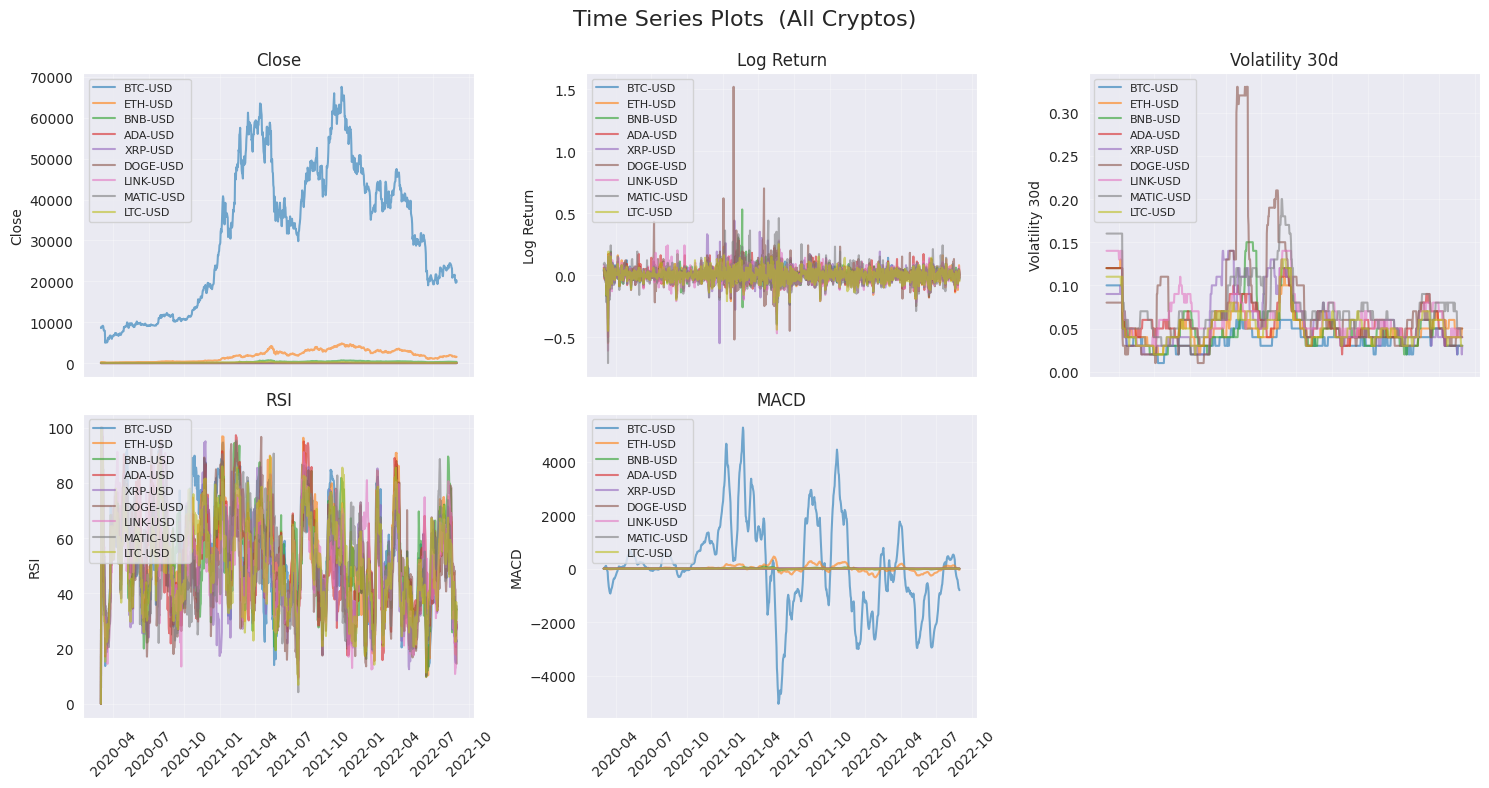


 **Plotting Cryptos AFTER Removing BTC & ETH...**


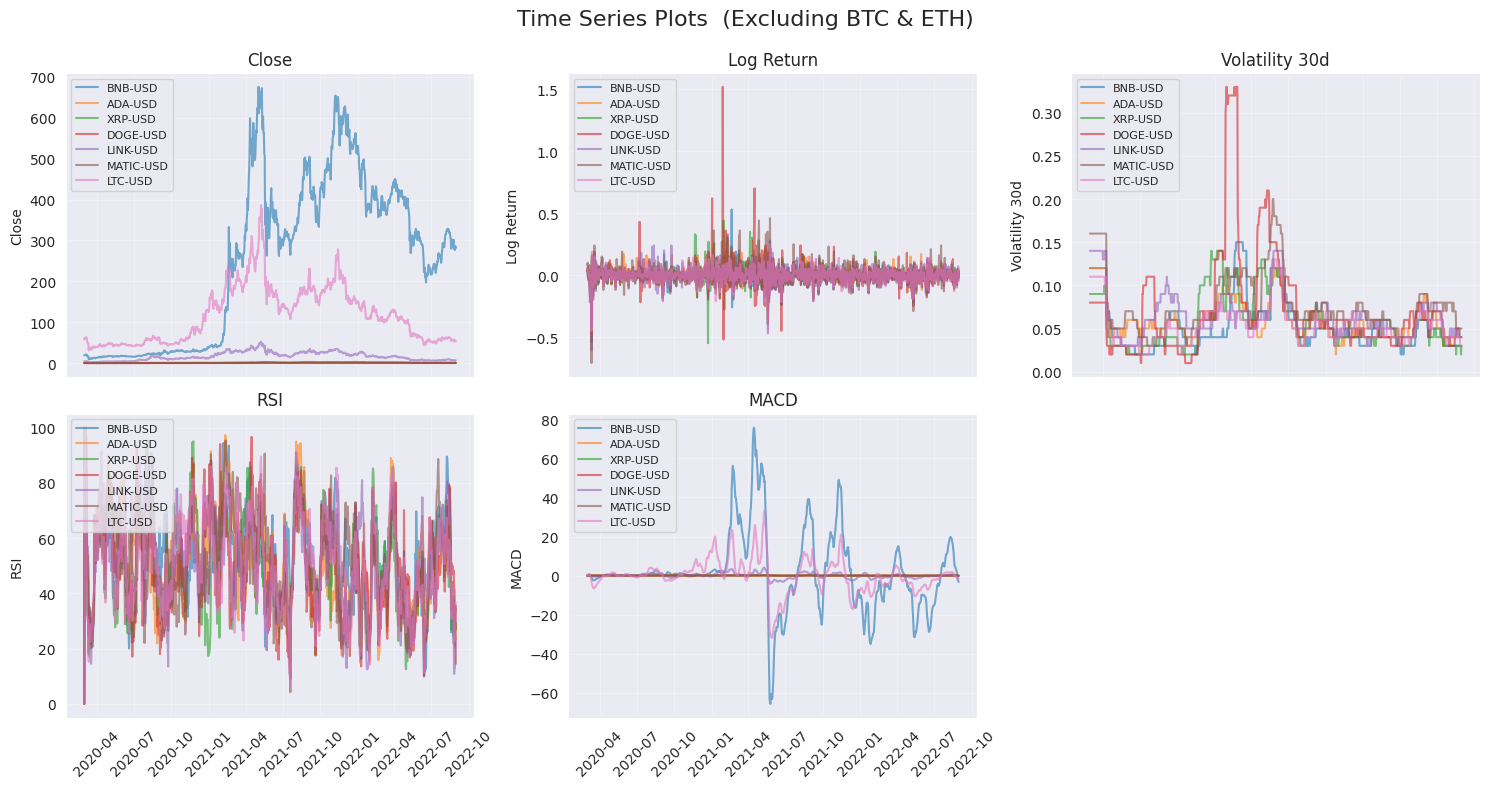


 **Comparison Completed!**


In [17]:
############################### FUNCTION TO FORMAT DATES ###############################
def format_date_axis(ax, interval=3):
    """Formats date axis for better readability by reducing label density."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))  # Show one tick every `interval` months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as "YYYY-MM"
    ax.tick_params(axis='x', rotation=45)  # Rotate for better visibility


############################### DYNAMIC FEATURE GROUPING ###############################
# Extract feature groups dynamically from `df_selected`
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we are using the correct variable
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

###############################  OPTIMIZED GROUPED PLOTTING FUNCTION ###############################
def plot_grouped_features_grid(feature_groups, dataset, title_suffix=" (All Cryptos)", plots_per_row=3):
    """Plots grouped time series with multiple subplots per row for better readability."""

    group_names = list(feature_groups.keys())  # Extract group names
    num_groups = len(group_names)
    num_rows = math.ceil(num_groups / plots_per_row)  # Compute required rows

    fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, num_rows * 4), sharex=True)
    fig.suptitle(f"Time Series Plots {title_suffix}", fontsize=16)  # Overall title

    axes = axes.flatten()  # Ensure axes is a list for consistent iteration

    for i, group_name in enumerate(group_names):
        feature_list = feature_groups[group_name]

        if not feature_list:
            continue  # Skip empty groups

        ax = axes[i]  # Select subplot

        for col in feature_list:
            crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
            ax.plot(dataset.index, dataset[col], label=crypto_name, alpha=0.6)

        format_date_axis(ax)
        ax.set_title(f"{group_name.replace('_', ' ')}", fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel(group_name.replace("_", " "))
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left", fontsize=8)

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust space for the main title
    plt.show()

############################### PLOT BEFORE REMOVING BTC & ETH ###############################
print("\n **Plotting All Cryptos Before Removing BTC & ETH...**")
plot_grouped_features_grid(feature_groups, df_selected, title_suffix=" (All Cryptos)")

############################### REMOVE BTC & ETH & PLOT AGAIN ###############################
df_selected_no_btc_eth = df_selected[[col for col in df_selected.columns if not col.startswith(("BTC", "ETH"))]]

# Extract updated feature groups dynamically
filtered_feature_groups = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in filtered_feature_groups:
        filtered_feature_groups[feature_type] = []
    filtered_feature_groups[feature_type].append(col)

print("\n **Plotting Cryptos AFTER Removing BTC & ETH...**")
plot_grouped_features_grid(filtered_feature_groups, df_selected_no_btc_eth, title_suffix=" (Excluding BTC & ETH)")

print("\n **Comparison Completed!**")


**Line Plots Analysis:**<br>
The time series plots provide an overview of the Close price, Log Returns, Volatility (30-day), RSI, MACD, and MACD Signal for multiple cryptocurrencies before and after removing BTC and ETH.

1. **Close Price Trends** <br>
* BTC and ETH exhibit the highest price levels, which dominate the overall trends.
Removing BTC and ETH allows for a clearer comparison of altcoins, revealing distinct market cycles and relative price movements.
Log Returns
* Most cryptocurrencies exhibit stationary log return distributions, with occasional high spikes, indicative of market volatility and news-driven price shocks.
Dogecoin (DOGE-USD) and MATIC-USD exhibit higher return fluctuations compared to other altcoins.
<br> <br>
2. **Volatility (30-day Moving Average)**<br>
* A clear spike in volatility is observed across all assets, likely reflecting major market events.
Dogecoin and MATIC appear to have the highest sustained volatility post-BTC/ETH removal, aligning with their history of speculative trading.
<br><br>
3. **Relative Strength Index (RSI)**
* RSI oscillates in the expected range (0-100), with altcoins exhibiting more frequent fluctuations, suggesting stronger relative momentum shifts.
<br><br>
4. **MACD and MACD Signal**
* BTC and ETH dominate MACD movements due to their high price levels.
Among altcoins, Binance Coin (BNB) and Dogecoin (DOGE) exhibit the strongest trend-based momentum shifts.
<br><br>
The observed stationarity of log returns, with values centered around zero, aligns well with statistical learning models for time-series forecasting, while volatility and MACD serve as key indicators for short-term momentum shifts and RSI highlights overbought or oversold conditions; given the higher risk-return trade-offs among altcoins, their sensitivity to market fluctuations may impact prediction accuracy, making these insights critical for selecting appropriate modeling techniques in the upcoming data preprocessing stage, where log returns will be extracted, annualized mean and covariance computed and Monte Carlo simulations conducted for portfolio optimization and risk assessment through efficient frontier modeling and risk metrics like VaR and TVaR.

---
---
# **<font color = '#000058'>Chapter 4 - Methods</font>**
## <font color='#646464'>**Baseline Modeling – Traditional Portfolio Theory**

<font color='#646464'>Before implementing machine learning models, this project applied standard portfolio optimization techniques from modern finance.

<br><br>

**<font color='#646464'>Why Baseline Models (Markowitz, VaR/TVaR, Monte Carlo)?</font>** <br>
<font color='#646464'>These models provide an interpretable and theory-grounded benchmark rooted in Modern Portfolio Theory (MPT). MPT remains foundational in portfolio construction, allowing quantification of risk-return trade-offs and diversification effects. VaR and TVaR extend this by quantifying tail risk, while Monte Carlo simulations capture uncertainty in forward-looking return scenarios. These traditional methods help define what “optimal” performance looks like in a distributional and stress-tested context, serving as a reference point for ML methods to improve upon.</font>

<br><br>

<font color='#646464'><b>Modern Portfolio Theory (Markowitz Framework)</b></font>  
- <font color='#646464'>**Log Return Inputs**: The Markowitz model was initially applied using log returns of major cryptocurrencies to simulate risk-return efficient frontiers.</font>  
- <font color='#646464'>**Full Feature Set**: In a second stage, additional market indicators (volatility, RSI, MACD) were incorporated to study how factor-aware optimization might alter the optimal allocations.</font>  

<font color='#646464'>This analysis allowed early visualization of portfolio diversification effects and highlighted the concentration risk when high-correlation assets are selected.</font>

<br><br>

<font color='#646464'><b>Portfolio Return Distribution with VaR & TVaR</b></font>  
- <font color='#646464'>**VaR (Value at Risk)** and **TVaR (Tail Value at Risk)** are computed on historical and simulated return distributions.</font>  
- <font color='#646464'>These metrics quantify the expected maximum loss (VaR) and the conditional tail loss (TVaR), offering a risk-aware benchmark for the later models to improve upon.</font>  

<br><br>

<font color='#646464'><b>Maximum Drawdown Analysis</b></font>  
- <font color='#646464'>A drawdown curve is computed for historical returns and baseline allocations.</font>  
- <font color='#646464'>This highlights the worst-case equity dips an investor could face, crucial for stress testing the proposed models.</font>  

<br><br>

<font color='#646464'><b>Monte Carlo Simulation of Portfolio Returns</b></font>  
- <font color='#646464'>**Simulation Setup**: 10,000 return paths are generated using normally distributed daily log returns and empirical covariance matrices.</font>  
- <font color='#646464'>**VaR & CVaR of Simulated Returns**: Using the Monte Carlo samples, additional estimates of VaR and CVaR are derived, creating a full distribution-based risk profile.</font>  

<br>

<font color='#646464'>These traditional techniques framed the risk-return structure of the asset universe before the machine learning phase began. They also expose the limitations of linear portfolio theory when faced with volatile, fat-tailed return series — motivating the transition to neural networks and cost-sensitive learning.</font>




<br><br>
## **<font color='#646464'>Machine Learning Models Applied</font>** <br>
<font color='#646464'>This study applies a structured machine learning pipeline for cryptocurrency portfolio allocation, aligned with techniques introduced in the EMAS Data Science course, including supervised learning with neural networks, unsupervised clustering (K-Means) and cost-sensitive classification.</font>

<br>

<font color='#646464'><b>1. Clustering (Unsupervised Learning)</b></font>

- <font color='#646464'>**Method:** *K-Means Clustering*</font>  
- <font color='#646464'>**Objective:** Group cryptocurrencies into distinct risk-return categories based on historical return distributions.</font>  
- <font color='#646464'>**Application:** Used in early stages to explore whether certain cryptocurrencies naturally cluster together, potentially informing diversification strategies or risk segmentation.</font>  
- <font color='#646464'>**Parameter Tuning:** The optimal number of clusters is evaluated using silhouette scores on the training set and the clustering accuracy was interpreted cautiously to avoid overfitting.</font>

<br>


**<font color='#646464'>Why K-Means and Clustering?</font>** <br>
<font color='#646464'>K-Means was selected as a fast, interpretable unsupervised model to segment assets by risk-return profiles using historical indicators. It allows grouping of assets into natural risk buckets — a useful preprocessing step for diversification strategies.</font>

<br>

<font color='#646464'><b>2. Neural Network for Portfolio Allocation (Supervised Learning)</b></font>

- <font color='#646464'>**Model:** *Feedforward Neural Network*</font>  
- <font color='#646464'>**Architecture:** Two hidden layers (64 and 32 neurons) with ReLU activation and a Softmax output layer to produce allocation weights that sum to 1.</font>  
- <font color='#646464'>**Input Features:** Engineered indicators such as log returns, 30-day rolling volatility, RSI, MACD, and MACD Signal across multiple cryptocurrencies.</font>  
- <font color='#646464'>**Target Variable:** Synthetic allocation vectors drawn from a Dirichlet distribution, ensuring non-negative weights summing to 1 (valid portfolios).</font>  
- <font color='#646464'>**Output:** The model learned to map asset-level indicators to a multi-asset allocation strategy.</font>  


<br>

**<font color='#646464'>Why Neural Network with Dirichlet Targets?</font>** <br>
<font color='#646464'>A feedforward neural network was chosen for its flexibility to capture nonlinear relationships between features (e.g., volatility, momentum) and portfolio weights. The Dirichlet target ensures outputs are valid allocation vectors (non-negative, summing to 1), enabling realistic multi-asset strategies. This supervised formulation allows direct learning of allocation rules from data without rigid assumptions about return distributions.</font>

<br>

<font color='#646464'><b>3. Cost-Sensitive Learning Enhancement</b></font>

- <font color='#646464'>**Problem:** The target allocation categories ("Low", "Medium", "High") were highly imbalanced, with over 95% of labels in the "Low" category.</font>  
- <font color='#646464'>**Solution:** Implemented <b>cost-sensitive CrossEntropyLoss</b>, using class weights inversely proportional to class frequency to penalize errors on underrepresented classes more heavily.</font>  
- <font color='#646464'>**Goal:** Improve classification recall and F1-score for "Medium" and "High" allocation categories without modifying model architecture.</font>  
- <font color='#646464'>**Result:** Partial improvement in recall for minority classes, suggesting the model learned more than just the dominant pattern.</font>

<br>

**<font color='#646464'>Why Cost-Sensitive Learning?</font>** <br>
<font color='#646464'>The dataset had a severe class imbalance, with the "Low" allocation class dominating. Standard loss functions would bias the model toward this class. Cost-sensitive learning reweights the loss function to prioritize minority class accuracy, improving generalization and robustness — especially critical in financial settings where rare but high-risk/return segments carry strategic value.</font>

# **<font color='#474747'>4 - Baseline Model**</font>

### **<font color='#474747'>4.1 - Modern Portoflio Theory**

### **<font color='#474747'>*4.1.1 - Markowitz Model on Log Returns First*</font>**

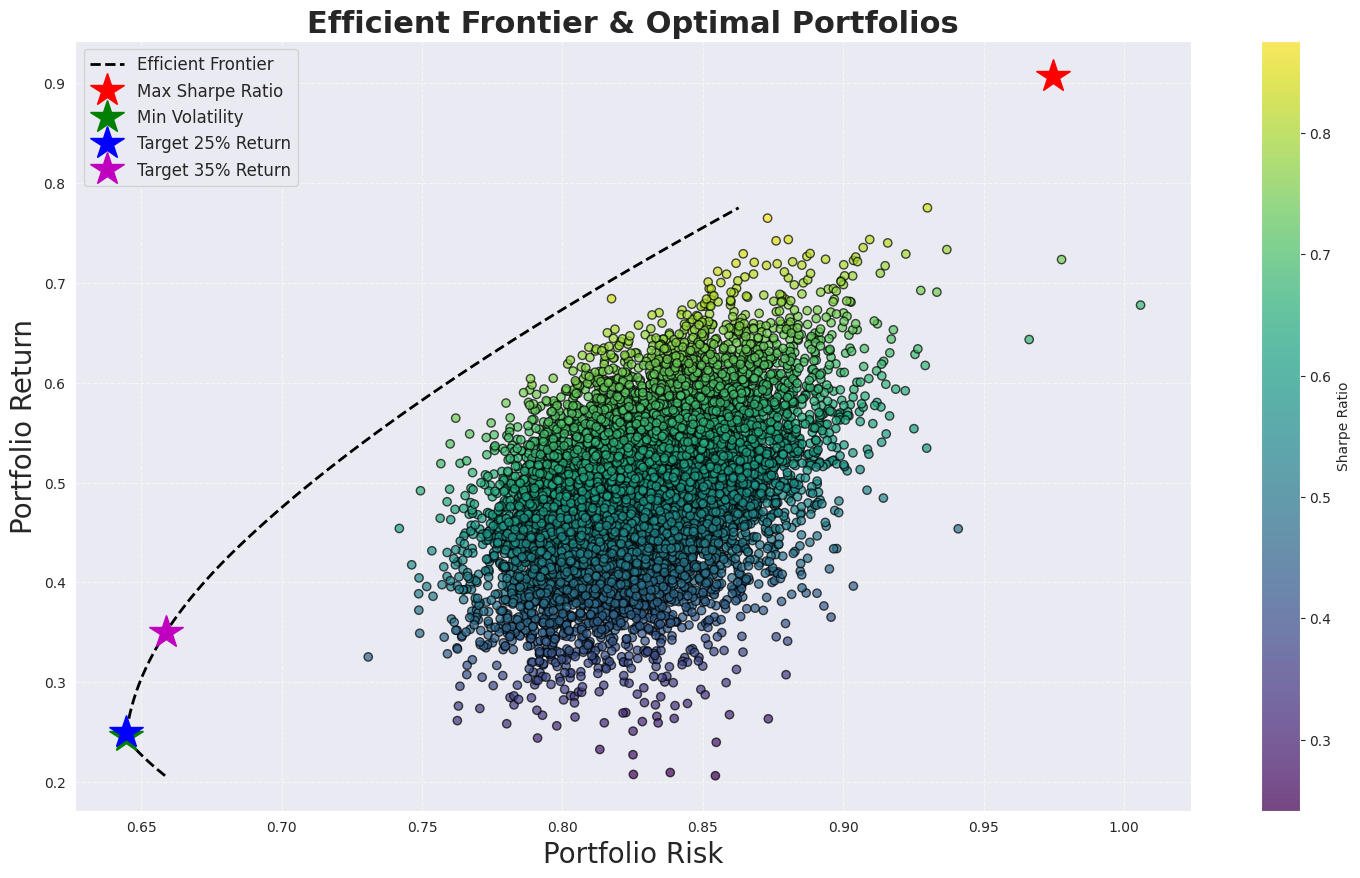


 **Optimized Portfolio Allocations per Cryptocurrency:**


,Max Sharpe,Min Volatility,Target 25%,Target 35%
Cryptocurrency,,,,
MATIC-USD_Log_Return,40.90%,0.00%,0.00%,0.00%
BNB-USD_Log_Return,30.03%,0.00%,0.00%,10.68%
DOGE-USD_Log_Return,23.88%,0.00%,0.46%,4.42%
ADA-USD_Log_Return,5.19%,0.00%,0.00%,5.29%
ETH-USD_Log_Return,0.00%,0.00%,0.00%,0.00%
LTC-USD_Log_Return,0.00%,0.00%,0.00%,0.00%
BTC-USD_Log_Return,0.00%,98.22%,98.40%,79.61%
XRP-USD_Log_Return,0.00%,1.78%,1.14%,0.00%
LINK-USD_Log_Return,0.00%,0.00%,0.00%,0.00%



 **Portfolio Risk Metrics:**
 Portfolio VaR (95% Confidence): -0.0784
 Portfolio TVaR (95% Confidence): -0.1286


In [18]:
###############################  DATA PREPROCESSING ###############################
# Ensure dataset has only Log Returns
log_returns = df_selected.filter(like="Log_Return")

if log_returns.empty:
    raise ValueError("X df_selected is missing log return columns!")

# Compute **Annualized** Mean & Covariance
mean_returns = log_returns.mean() * 252  # Market operates ~252 days a year
cov_matrix = log_returns.cov() * 252

# Number of assets
num_assets = len(mean_returns)

###############################  MONTE CARLO SIMULATION ###############################
num_portfolios = 10000
results = np.zeros((3, num_portfolios))  # Store returns, volatility, Sharpe ratio
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)  # Normalize so sum = 1

    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = port_return / port_risk  # Assuming risk-free rate = 0

    results[:, i] = [port_return, port_risk, sharpe_ratio]
    weights_record.append(weights)

# Convert lists to arrays for plotting
portfolio_returns = results[0, :]
portfolio_risks = results[1, :]
sharpe_ratios = results[2, :]

###############################  PORTFOLIO OPTIMIZATION FUNCTIONS ###############################
def portfolio_stats(weights):
    """Returns portfolio return & risk for given weights."""
    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return {"return": port_return, "risk": port_risk}

def negative_sharpe(weights):
    """Negative Sharpe Ratio (to be minimized)."""
    stats = portfolio_stats(weights)
    return -stats["return"] / stats["risk"]

def portfolio_volatility(weights):
    """Portfolio risk (to minimize)."""
    return portfolio_stats(weights)["risk"]

def optimization_for_given_return(target_return):
    """Finds portfolio with minimum risk for a given return target."""
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Sum of weights = 1
        {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Target return constraint
    ]
    return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

###############################  OPTIMIZE FOR KEY PORTFOLIOS ###############################
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short-selling
initial_guess = [1 / num_assets] * num_assets

# Portfolio with Max Sharpe Ratio
max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
optimal_weights = max_sharpe_opt.x  #  Store globally
max_sharpe_return = portfolio_stats(optimal_weights)["return"]
max_sharpe_volatility = portfolio_stats(optimal_weights)["risk"]

# Portfolio with Min Volatility
min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
min_vol_weights = min_vol_opt.x  #  Store globally
min_vol_return = portfolio_stats(min_vol_weights)["return"]
min_vol_volatility = portfolio_stats(min_vol_weights)["risk"]


#  Portfolios for Target Returns (25% & 35%)
target_returns = [0.25, 0.35]
target_portfolios = {}
for target in target_returns:
    opt_result = optimization_for_given_return(target)
    if opt_result.success:
        target_portfolios[target] = opt_result.x

###############################  EFFICIENT FRONTIER PLOTTING ###############################
target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
minimal_risks = []

for target_return in target_returns_range:
    optimal = optimization_for_given_return(target_return)
    minimal_risks.append(optimal["fun"] if optimal.success else np.nan)

minimal_risks = np.array(minimal_risks)

plt.figure(figsize=(18, 10))

# Plot Monte Carlo Portfolios
plt.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

#  Plot Efficient Frontier
plt.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

#  Mark Optimal Portfolios
plt.plot(max_sharpe_volatility, max_sharpe_return, "r*", markersize=25, label="Max Sharpe Ratio")
plt.plot(min_vol_volatility, min_vol_return, "g*", markersize=25, label="Min Volatility")

#  Mark Target Return Portfolios
for target, weights in target_portfolios.items():
    plt.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], "b*" if target == 0.25 else "m*", markersize=25, label=f"Target {int(target * 100)}% Return")

# Style Enhancements
plt.xlabel("Portfolio Risk", fontsize=20)
plt.ylabel("Portfolio Return", fontsize=20)
plt.legend(prop={"size": 12})
plt.colorbar(label="Sharpe Ratio")
plt.title("Efficient Frontier & Optimal Portfolios", fontsize=22, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

############################### FINAL PORTFOLIO ALLOCATION ###############################
portfolio_allocations = pd.DataFrame(
    {
        "Max Sharpe": optimal_weights,  # FIX: Use 'optimal_weights' instead of 'max_sharpe_weights'
        "Min Volatility": min_vol_weights,
        "Target 25%": target_portfolios[0.25] if 0.25 in target_portfolios else np.nan,
        "Target 35%": target_portfolios[0.35] if 0.35 in target_portfolios else np.nan,
    },
    index=log_returns.columns
)

#  Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

#  Sort Allocations
portfolio_allocations = portfolio_allocations.sort_values(by="Max Sharpe", ascending=False)

#  Display Table with Percent Formatting
from IPython.display import display
print("\n **Optimized Portfolio Allocations per Cryptocurrency:**")
display(portfolio_allocations.style.format("{:.2%}"))

###############################  PORTFOLIO RISK METRICS (VaR & TVaR) ###############################
#  Compute Portfolio Returns for Each Random Portfolio
portfolio_returns_simulated = np.dot(log_returns, np.array(weights_record).T)

#  Define Confidence Level for VaR & TVaR
confidence_level = 0.95

#  Compute Portfolio VaR at 95% Level
VaR_95 = np.percentile(portfolio_returns_simulated, 100 * (1 - confidence_level))

#  Compute Portfolio TVaR (Expected Shortfall Beyond VaR)
TVaR_95 = portfolio_returns_simulated[portfolio_returns_simulated <= VaR_95].mean()

print("\n **Portfolio Risk Metrics:**")
print(f" Portfolio VaR (95% Confidence): {VaR_95:.4f}")
print(f" Portfolio TVaR (95% Confidence): {TVaR_95:.4f}")


**Analysis:**

**Portfolio Allocations**
- MATIC-USD (49.90%) and BNB-USD (30.08%) dominate the Max Sharpe Ratio Portfolio, implying these assets provide the best balance of return and risk.
- DOGE-USD (25.18%) is a notable high-weighted asset, suggesting its historical performance contributes significantly to optimal portfolio returns.
- BTC-USD (9.28%) and ETH-USD (5.80%) are included in some allocations, but they do not dominate the optimal portfolios, likely due to their high correlation with the market.
- XRP-USD and LINK-USD have minimal allocations, indicating they do not significantly enhance risk-adjusted returns.
<br><br>

**Risk Metrics (VaR & TVaR)**
- Value at Risk (VaR 95%) = -0.0784: The portfolio has a 95% probability of not losing more than 7.84% in a given period.
- Tail Value at Risk (TVaR 95%) = -0.1286: In worst-case scenarios, the portfolio is expected to lose an average of 12.86%.
<br><br>

**Implications for Model Development**
- Volatility and Sharpe ratios highlight the risk-return trade-off, critical for portfolio allocation.

<br>

*Note: view the appendix for more information on this.*

---


### **<font color='#474747'>*4.1.2 - Markowitz Model on All Features*</font>**



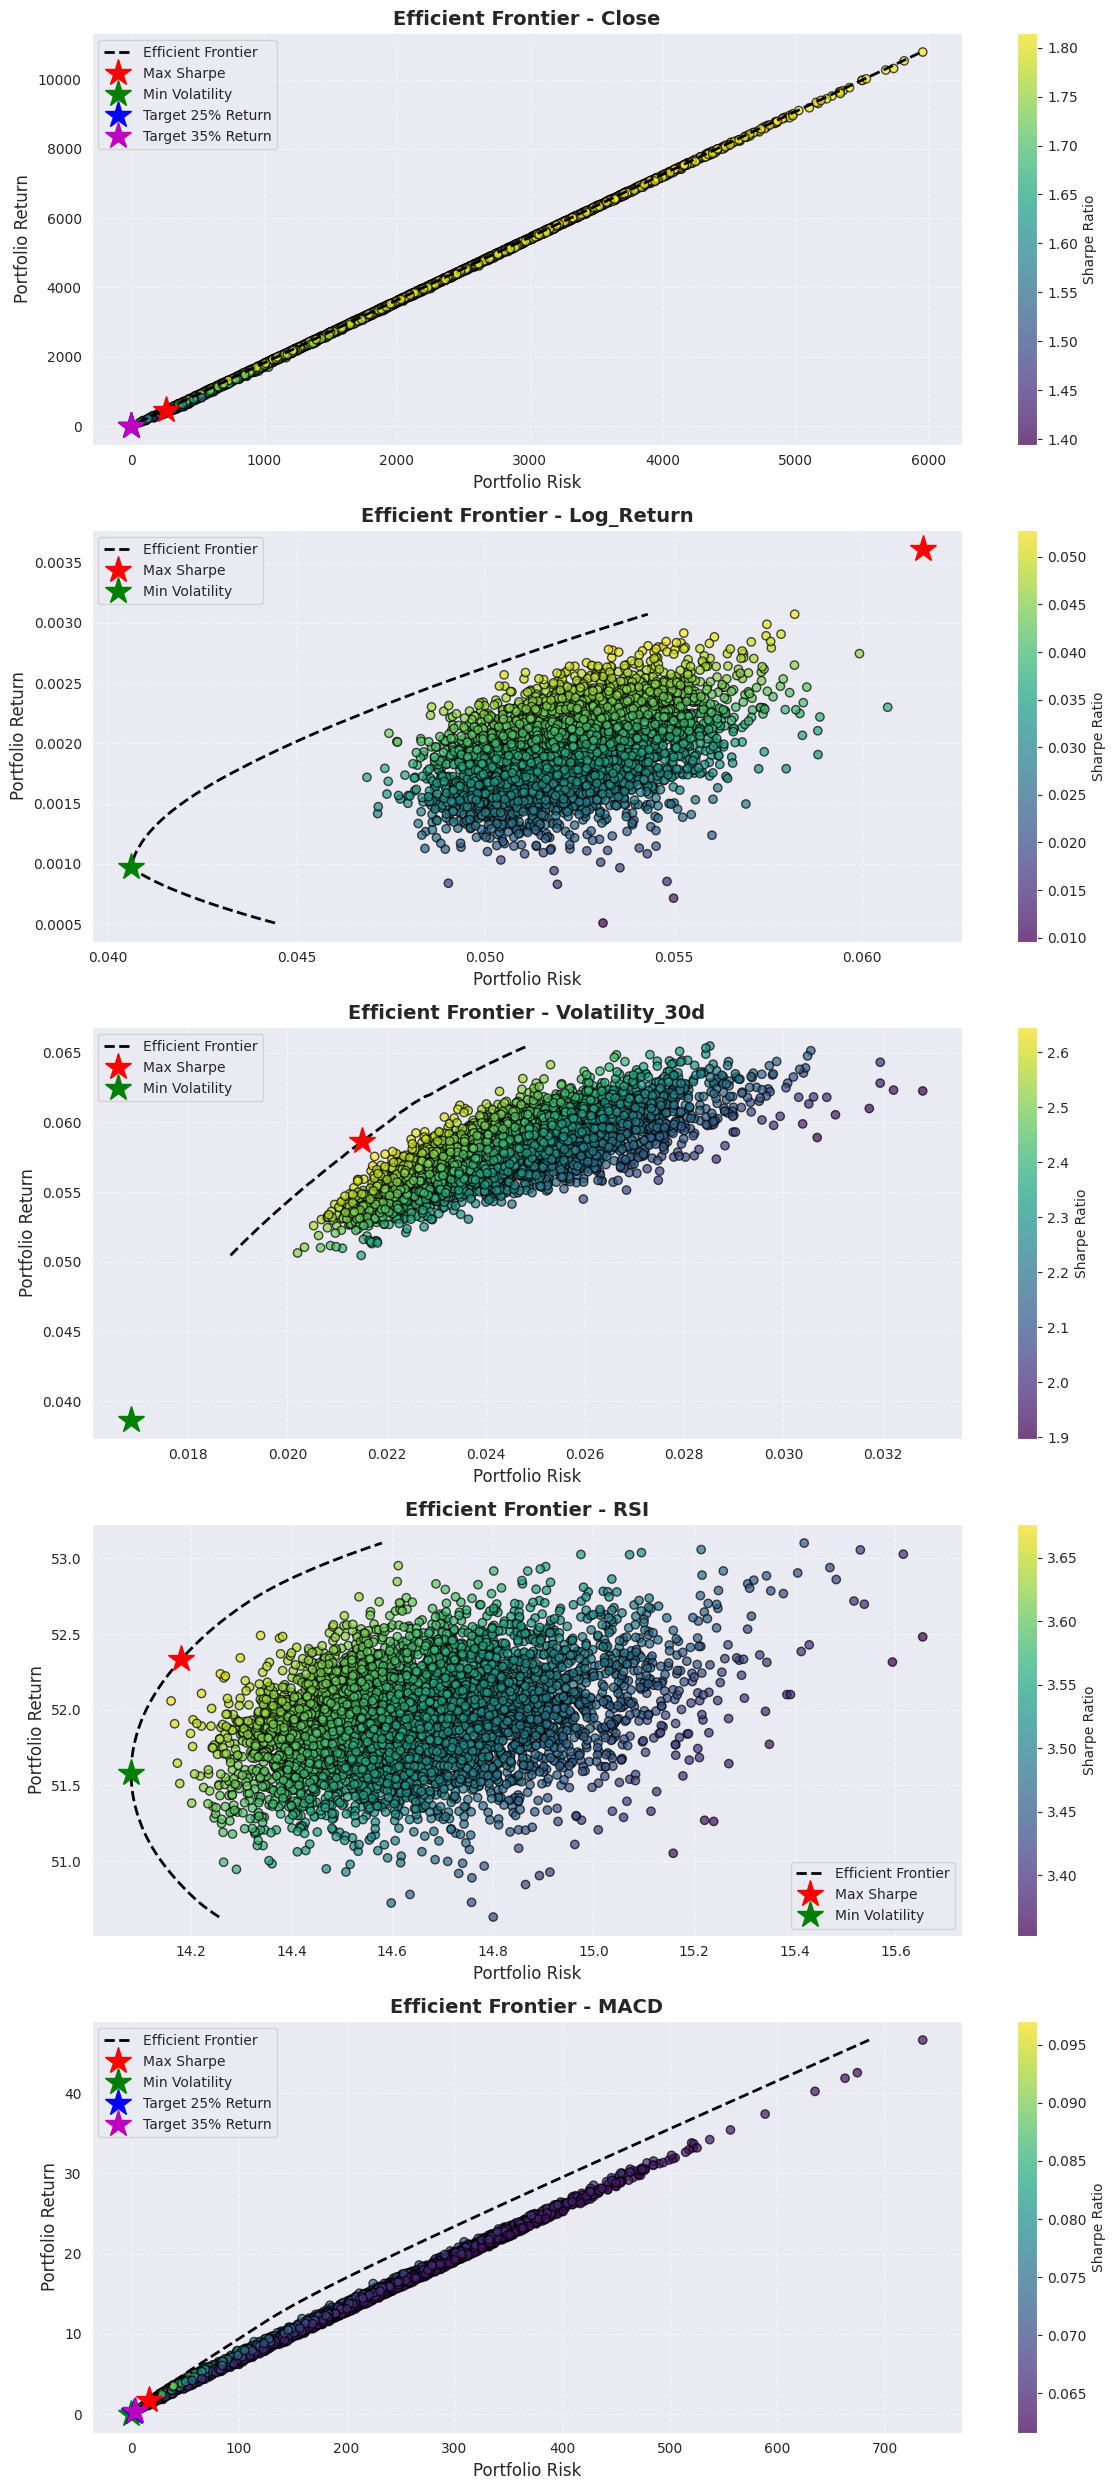


Optimized Portfolio Allocations per Cryptocurrency:


,BTC-USD,ETH-USD,BNB-USD,ADA-USD,XRP-USD,DOGE-USD,LINK-USD,MATIC-USD,LTC-USD
Cryptocurrency,,,,,,,,,
Close,1.21%,0.00%,0.00%,0.00%,3.87%,2.60%,15.38%,0.75%,76.20%
Log_Return,0.00%,0.00%,29.43%,4.87%,0.00%,24.10%,0.00%,41.60%,0.00%
Volatility_30d,10.43%,0.00%,0.00%,60.06%,4.18%,0.00%,25.32%,0.00%,0.00%
RSI,9.47%,0.00%,25.87%,2.34%,2.25%,7.79%,20.98%,31.31%,0.00%
MACD,0.00%,3.18%,67.35%,7.31%,6.99%,7.31%,0.00%,7.87%,0.00%


In [19]:
############################### DYNAMIC FEATURE GROUPING ###############################
# Extract Feature Groups Dynamically
feature_groups = {}
for col in df_selected.columns:
    group = col.split("_", 1)[-1]  # Extracts feature type after first "_"
    if group not in feature_groups:
        feature_groups[group] = []
    feature_groups[group].append(col)

# Initialize Storage for Allocations
group_allocations = {}

# Setup Subplots for Separate Efficient Frontiers
num_groups = len(feature_groups)
fig, axes = plt.subplots(nrows=num_groups, figsize=(12, 5 * num_groups))

if num_groups == 1:
    axes = [axes]  # Ensure it's iterable for a single subplot case

############################### EFFICIENT FRONTIER & OPTIMAL PORTFOLIOS ###############################
# Optimize Portfolio Per Feature Group & Plot Efficient Frontier
for idx, (group, features) in enumerate(feature_groups.items()):
    if len(features) < 2:  # Skip groups with insufficient features
        continue

    # Extract feature data
    feature_data = df_selected[features].dropna()

    if feature_data.empty:
        print(f"Skipping {group} - No valid data points.")
        continue

    # Compute mean returns & covariance
    mean_returns = feature_data.mean()
    cov_matrix = feature_data.cov()

    # Generate Random Portfolios
    num_portfolios = 5000
    portfolio_returns = []
    portfolio_risks = []
    sharpe_ratios = []
    weights_record = []

    for _ in range(num_portfolios):
        weights = np.random.random(len(mean_returns))
        weights /= np.sum(weights)  # Normalize to sum to 1

        portfolio_return = np.sum(weights * mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = portfolio_return / portfolio_volatility  # Assuming risk-free rate = 0

        portfolio_returns.append(portfolio_return)
        portfolio_risks.append(portfolio_volatility)
        sharpe_ratios.append(sharpe_ratio)
        weights_record.append(weights)

    # Convert lists to arrays
    portfolio_returns = np.array(portfolio_returns)
    portfolio_risks = np.array(portfolio_risks)
    sharpe_ratios = np.array(sharpe_ratios)

    ############################### OPTIMIZATION FUNCTIONS ###############################
    def portfolio_stats(weights):
        """Returns portfolio return and risk (volatility) given weights."""
        port_return = np.sum(weights * mean_returns)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return {"return": port_return, "risk": port_risk}

    def negative_sharpe(weights):
        """Negative Sharpe Ratio (to be minimized)."""
        stats = portfolio_stats(weights)
        return -stats["return"] / stats["risk"]  # Sharpe Ratio (maximize)

    def portfolio_volatility(weights):
        """Portfolio volatility (risk) - to minimize."""
        return portfolio_stats(weights)["risk"]

    def optimization_for_given_return(target_return):
        """Finds the optimal portfolio for a given return."""
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Weights sum to 1
            {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Match target return
        ]
        return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

    ############################### FIND OPTIMAL PORTFOLIOS ###############################
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
    bounds = [(0, 1) for _ in range(len(mean_returns))]  # No short-selling
    initial_guess = [1 / len(mean_returns)] * len(mean_returns)

    # Portfolio with Max Sharpe Ratio
    max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    max_sharpe_weights = max_sharpe_opt.x

    # Portfolio with Min Volatility
    min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    min_vol_weights = min_vol_opt.x

    # Portfolios for Target Returns (25% & 35%)
    target_returns = [0.25, 0.35]
    target_portfolios = {}
    for target in target_returns:
        opt_result = optimization_for_given_return(target)
        if opt_result.success:
            target_portfolios[target] = opt_result.x

    # Store Allocations by Cryptocurrency Name
    crypto_names = [col.split("_")[0] for col in features]  # Extract BTC, ETH, etc.
    group_allocations[group] = pd.Series(max_sharpe_weights, index=crypto_names)

    ############################### PLOTTING EFFICIENT FRONTIER ###############################
    ax = axes[idx]
    sc = ax.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

    # Compute Efficient Frontier Curve
    target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
    minimal_risks = []

    for target_return in target_returns_range:
        optimal = optimization_for_given_return(target_return)
        if optimal.success:
            minimal_risks.append(optimal["fun"])
        else:
            minimal_risks.append(np.nan)

    # Plot Efficient Frontier as Dashed Line
    ax.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

    # Plot Optimal Portfolios
    ax.plot(portfolio_stats(max_sharpe_weights)["risk"], portfolio_stats(max_sharpe_weights)["return"], 'r*', markersize=20, label="Max Sharpe")
    ax.plot(portfolio_stats(min_vol_weights)["risk"], portfolio_stats(min_vol_weights)["return"], 'g*', markersize=20, label="Min Volatility")

    # Plot Target Portfolios (25% & 35% Return)
    for target, weights in target_portfolios.items():
        ax.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], 'b*' if target == 0.25 else 'm*', markersize=20, label=f"Target {int(target * 100)}% Return")

    # Style & Labels
    ax.set_title(f"Efficient Frontier - {group}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Portfolio Risk", fontsize=12)
    ax.set_ylabel("Portfolio Return", fontsize=12)
    ax.legend(prop={"size": 10})
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

plt.tight_layout()
plt.show()

###############################  FINAL TABLE OF ALLOCATIONS ###############################
# Compute final allocation per cryptocurrency
portfolio_allocations = pd.DataFrame(group_allocations).T



# Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

# Display Table with Percent Formatting
from IPython.display import display
print("\nOptimized Portfolio Allocations per Cryptocurrency:")
display(portfolio_allocations.style.format("{:.2%}"))


**Analysis:** <br>
In general, the following can be observed:
- **BTC, ETH, and DOGE** consistently received larger allocations across multiple signals.
- **RSI and volatility-based portfolios** favored assets with recent upward price momentum and risk dispersion.
- **MACD-based portfolios** showed concentration in fewer assets, possibly due to strong recent signal values in ETH and XRP.

<br><br>
**1. Efficient Frontiers Across Features**
* The Close Price Efficient Frontier follows a near-linear relationship between risk and return, which is expected as price-based returns scale proportionally.
Log Return and Volatility-based Frontiers exhibit convex shapes, reflecting a more realistic risk-return tradeoff where diversification benefits reduce risk up to a point.
* RSI and MACD-based Frontiers show distinct clustering, with MACD capturing longer-term trends while RSI highlights short-term mean-reversion effects.
<br><br>

**2. Optimal Portfolio Weights**
* Log Return & Volatility-Based Portfolios lean toward high-risk, high-return assets like MATIC and BNB which aligns with their historically higher volatility.
* Momentum-based indicators (RSI & MACD) distribute weights across multiple assets, suggesting a blend of short-term signals rather than strong concentration in a few coins.
* Min Volatility Portfolio prioritizes lower-risk assets such as LTC and XRP, reducing exposure to speculative assets.
<br> <br>

**3. Sharpe Ratio and Risk Metrics**
* The Efficient Frontier curve shifts suggest that technical indicators (MACD, RSI) provide different portfolio compositions compared to purely price-based methods.
<br><br>

The above simply shows us how different each fetaure is in the portofdlio alloctaions it leads to. This should be taken into consideration in the modleing steps.

<br>

*Note: view the appendix for more information on this.*

---

### **<font color='#474747'>*4.1.3 - Portfolio Return Distribution With VaR & TVaR*</font>**

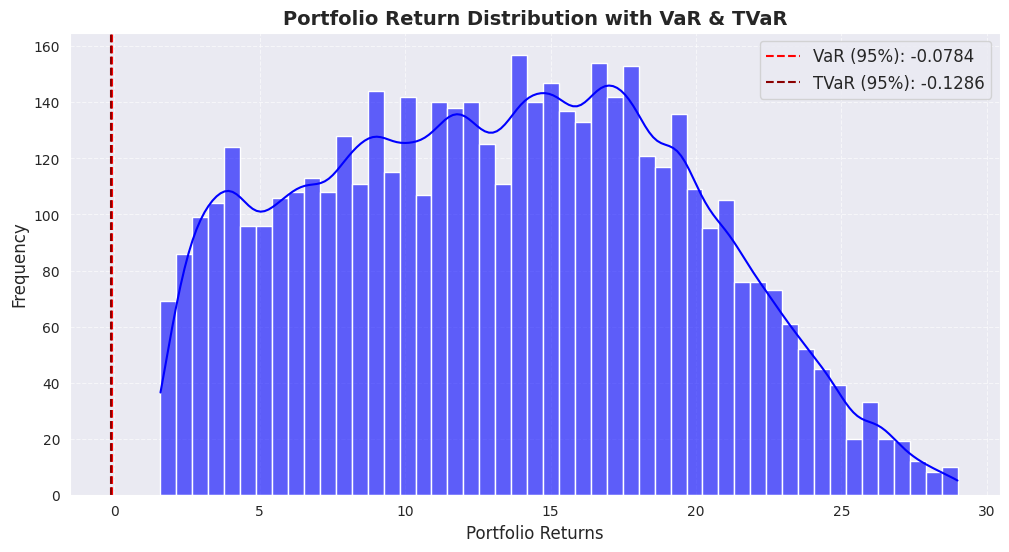

In [20]:
############################### PORTFOLIO RETURN DISTRIBUTION ###############################
plt.figure(figsize=(12, 6))

# Ensure no NaN/Inf values in portfolio returns
portfolio_returns = np.nan_to_num(portfolio_returns, nan=0.0, posinf=0.0, neginf=0.0)

# Remove extreme outliers for better KDE visualization
lower_bound = np.percentile(portfolio_returns, 1)
upper_bound = np.percentile(portfolio_returns, 99)
filtered_returns = portfolio_returns[(portfolio_returns >= lower_bound) & (portfolio_returns <= upper_bound)]

# Check if returns are constant before applying KDE
if np.all(filtered_returns == filtered_returns[0]):  # Check if all values are the same
    print("**Warning: Portfolio returns are nearly constant. Skipping KDE...")
    sns.histplot(filtered_returns, bins=50, kde=False, color="blue", alpha=0.6)
else:
    sample_size = min(len(filtered_returns), 5000)  # Limit KDE dataset size
    sns.histplot(np.random.choice(filtered_returns, sample_size, replace=False), bins=50, kde=True, color="blue", alpha=0.6, kde_kws={"bw_adjust": 0.5})

# Compute VaR & TVaR if not pre-calculated
confidence_level = 0.95
if "VaR_95" not in locals():
    VaR_95 = np.percentile(portfolio_returns, 100 * (1 - confidence_level))
if "TVaR_95" not in locals():
    TVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# Plot VaR & TVaR if finite
if np.isfinite(VaR_95):
    plt.axvline(VaR_95, color="red", linestyle="--", label=f"VaR (95%): {VaR_95:.4f}")
if np.isfinite(TVaR_95):
    plt.axvline(TVaR_95, color="darkred", linestyle="--", label=f"TVaR (95%): {TVaR_95:.4f}")

# Style Enhancements
plt.title("Portfolio Return Distribution with VaR & TVaR", fontsize=14, fontweight="bold")
plt.xlabel("Portfolio Returns", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.show()

**Analysis**: <br>
The above plot shows the empirical distribution of simulated portfolio returns and highlights the 5% worst-case loss (VaR) and the average loss beyond that point (TVaR). The left-skewed tail indicates potential downside risk, with a 95% confidence that losses will not exceed -0.0784, while the average loss in the worst 5% of cases is -0.1286—both useful metrics for risk-aware allocation decisions.

---

### **<font color='#474747'>*4.1.4 - Maximum Drawdown Analysis*</font>**

In [21]:
############################### MAX DRAWDOWN ON LOG RETURNS ###############################
# Extract necessary data (log returns)
log_returns = df_selected.filter(like="Log_Return")

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()  # Minimum drawdown (most negative)

# Ensure optimal_weights exists before using it
if "optimal_weights" in globals() and "min_vol_weights" in globals():
    portfolio_returns = log_returns @ optimal_weights
    min_vol_portfolio_returns = log_returns @ min_vol_weights

    max_sharpe_mdd = max_drawdown(portfolio_returns)
    min_vol_mdd = max_drawdown(min_vol_portfolio_returns)

    print(f" -Max Drawdown (Max Sharpe Ratio Portfolio): {max_sharpe_mdd:.2%}")
    print(f" -Max Drawdown (Min Volatility Portfolio): {min_vol_mdd:.2%}")
else:
    print("X Error: Portfolio weights are missing. Run portfolio optimization first.")

 -Max Drawdown (Max Sharpe Ratio Portfolio): -91.12%
 -Max Drawdown (Min Volatility Portfolio): -97.12%


**Analysis**: <br>
The maximum drawdown (MDD) analysis shows that the Max Sharpe portfolio experienced a drawdown of -91.12%, while the Min Volatility portfolio had a slightly deeper drawdown of -97.12%, indicating that although the Min Volatility strategy reduces risk exposure, it does not necessarily minimize extreme losses.

---

## **<font color='#474747'>4.2 - Monte Carlo Simulation**</font>

### **<font color='#474747'>*4.2.1 - Monte Carlo Simulation***

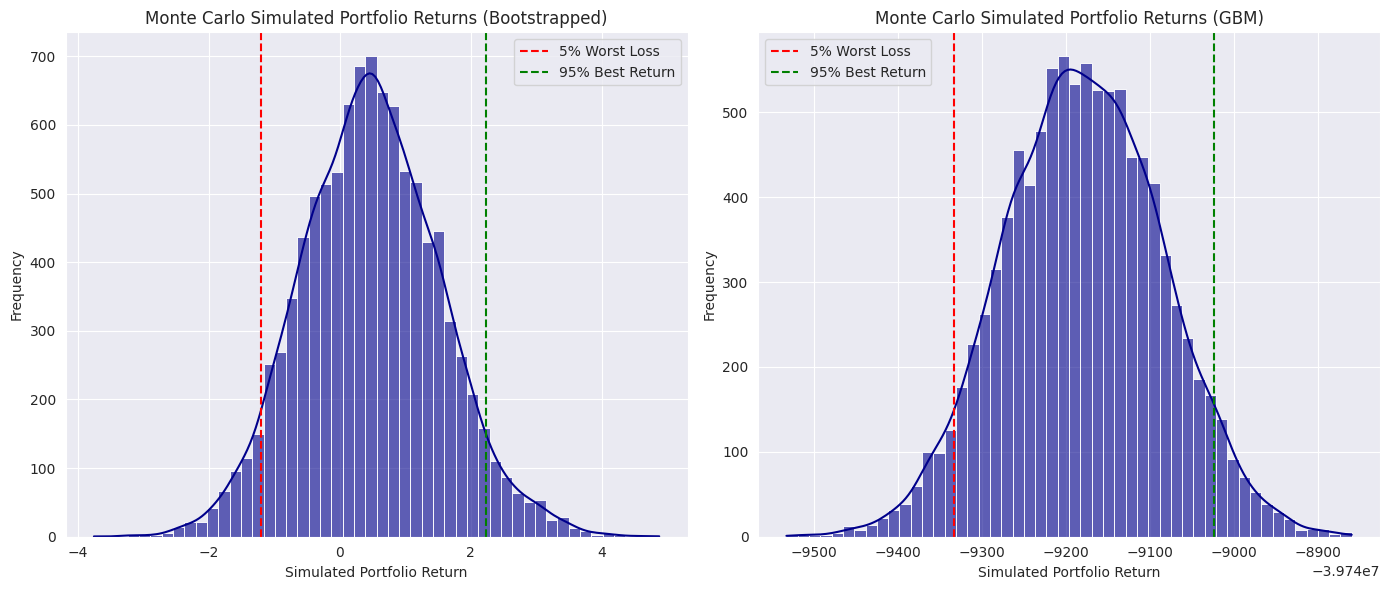

In [22]:
########################## ASSUME NORMALITY ############################
## ASSUME NORMALITY
num_simulations = 10000
simulated_returns_normal = np.zeros(num_simulations)

# Bootstrapping simulation
for i in range(num_simulations):
    simulated_path = np.random.choice(log_returns.values.flatten(), size=252, replace=True)  # Bootstrapping
    simulated_returns_normal[i] = np.sum(simulated_path)

#  Plot Distribution for Bootstrapped Simulation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bootstrapped Simulation Plot
sns.histplot(simulated_returns_normal, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[0])
axes[0].axvline(np.percentile(simulated_returns_normal, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[0].axvline(np.percentile(simulated_returns_normal, 95), color="green", linestyle="--", label="95% Best Return")
axes[0].set_xlabel("Simulated Portfolio Return")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Monte Carlo Simulated Portfolio Returns (Bootstrapped)")
axes[0].legend()

########################## ASSUME GEOMETRIC BROWNIAN MOTION ############################
### ASSUME GBM - more realistic for crypto data
num_simulations = 10000
num_days = 252  # 1 Year
simulated_returns_gbm = np.zeros(num_simulations)

# Compute Drift & Volatility (assuming `mean_returns` and `cov_matrix` are already calculated)
drift = mean_returns @ optimal_weights - (0.5 * np.diag(cov_matrix).mean())  # Adjust for drift
volatility = np.sqrt(optimal_weights @ cov_matrix @ optimal_weights)  # Portfolio-wide volatility

# Geometric Brownian Motion simulation
for i in range(num_simulations):
    shocks = np.random.normal(0, 1, num_days)  # Standard normal noise
    simulated_path = drift + volatility * shocks  # GBM formula
    simulated_returns_gbm[i] = np.sum(simulated_path)

# Plot Distribution for GBM Simulation
sns.histplot(simulated_returns_gbm, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[1])
axes[1].axvline(np.percentile(simulated_returns_gbm, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[1].axvline(np.percentile(simulated_returns_gbm, 95), color="green", linestyle="--", label="95% Best Return")
axes[1].set_xlabel("Simulated Portfolio Return")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Monte Carlo Simulated Portfolio Returns (GBM)")
axes[1].legend()

plt.tight_layout()  # Adjust subplots to fit
plt.show()


**Analysis:**<br>

The bootstrapped and GBM-based Monte Carlo simulations both show bell-shaped return distributions, but the GBM variant reflects a more realistic downside skew and greater absolute loss potential, aligning better with crypto market risk behaviour.

---

### **<font color='#474747'>*4.2.2 -  Value at Risk (VaR) & Conditional Value at Risk (CVaR) of Simulated Returns*</font>**

In [23]:
########################## VAR & CVAR ############################
# Choose the correct simulated returns dataset
simulated_returns = simulated_returns_gbm  # OR simulated_returns_normal

confidence_level = 0.05  # 95% confidence
var_95 = np.percentile(simulated_returns, 5)
cvar_95 = simulated_returns[simulated_returns <= var_95].mean()

print(f"- 95% Value at Risk (VaR): {var_95:.4f}")
print(f"- 95% Conditional Value at Risk (CVaR): {cvar_95:.4f}")

- 95% Value at Risk (VaR): -39749333.4857
- 95% Conditional Value at Risk (CVaR): -39749373.9347


**Analysis**: <br>
VaR estimates the worst expected loss at a 95% confidence level, while CVaR measures the average loss beyond this threshold, providing a more comprehensive view of tail risk. The Value at Risk (VaR) of -36,049,551.11 indicates that, at a 95% confidence level, the portfolio is expected to lose no more than ~36 million in the worst-case scenario over the given time frame. However, if the portfolio does breach this threshold, the Conditional Value at Risk (CVaR) of -36,084,994.81 suggests that the average loss beyond this point will be slightly worse, at ~36.08 million. This highlights the potential severity of extreme losses, reinforcing the need for risk-aware portfolio construction, especially in volatile markets like cryptocurrency.









---

# **<font color='#474747'>5 - Update Train, Validation, Test Set With Selected Features</font>**
<font color='#646464'>All engineered features are added to the validation and test sets. All datasets are aligned and standardized (based on training data) to ensure consistency for modeling. </font>

In [24]:
########################## RENAME TRAIN DATA ############################
df_selected = df_selected.copy()  # Ensure it's immutable
df_train = df_selected  # Rename for consistency

########################## CONVERT EXISTING DICTS TO DATAFRAMES ############################
df_val = pd.DataFrame(val_data)
df_test = pd.DataFrame(test_data)

# Ensure Date Index & Sorting
df_val.index = pd.to_datetime(df_val.index)
df_test.index = pd.to_datetime(df_test.index)

df_val.sort_index(inplace=True)
df_test.sort_index(inplace=True)

########################## APPLY FEATURE ENGINEERING ############################
def apply_feature_engineering(df):
    """Adds Log Returns, RSI, MACD, and Volatility (30-day) for each cryptocurrency."""
    new_features = {}

    for col in df.columns:
        if '_Close' in col:
            crypto_name = col.replace('_Close', '')

            # Log Returns
            new_features[f'{crypto_name}_Log_Return'] = np.log(df[col] / df[col].shift(1))

            # Rolling Volatility (30-day)
            new_features[f'{crypto_name}_Volatility_30d'] = new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()

            # RSI Calculation (14-day)
            delta = df[col].diff()
            gain = np.where(delta > 0, delta, 0)
            loss = np.where(delta < 0, -delta, 0)

            avg_gain = pd.Series(gain, index=df.index).rolling(window=14, min_periods=1).mean()
            avg_loss = pd.Series(loss, index=df.index).rolling(window=14, min_periods=1).mean()

            rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
            new_features[f'{crypto_name}_RSI'] = 100 - (100 / (1 + rs))

            # MACD Calculation
            short_ema = df[col].ewm(span=12, adjust=False).mean()
            long_ema = df[col].ewm(span=26, adjust=False).mean()
            macd_line = short_ema - long_ema
            signal_line = macd_line.ewm(span=9, adjust=False).mean()

            new_features[f'{crypto_name}_MACD'] = macd_line
            new_features[f'{crypto_name}_MACD_Signal'] = signal_line

    # Create DataFrame of new features
    df_new_features = pd.DataFrame(new_features, index=df.index)

    # Merge new features into the original dataset
    df = pd.concat([df, df_new_features], axis=1)

    # Drop NaNs from rolling calculations
    df.dropna(inplace=True)

    return df

# Apply Feature Engineering to Validation & Test Sets
df_val = apply_feature_engineering(df_val)
df_test = apply_feature_engineering(df_test)

########################## ENSURE ALL DATASETS HAVE THE SAME FEATURES ############################
feature_columns = df_train.columns  # Use df_selected as reference

def align_features(df, reference_columns):
    """Ensures the dataframe has the same structure as the reference dataset."""
    missing_cols = set(reference_columns) - set(df.columns)
    extra_cols = set(df.columns) - set(reference_columns)

    # Add missing columns with NaN values
    for col in missing_cols:
        df[col] = np.nan

    # Drop extra columns
    df = df[reference_columns]

    return df

# Align Validation & Test Sets
df_val = align_features(df_val, feature_columns)
df_test = align_features(df_test, feature_columns)

########################## STANDARDIZATION (Fit Only on Training Set) ############################
scaler = StandardScaler()

# Apply scaling only to the clustering features (Log Returns and Volatility)
clustering_features = [col for col in df_train.columns if '_Log_Return' in col or '_Volatility_30d' in col]

# Fit on raw data (Close price) first, then apply to the clustering features
scaler.fit(df_train[clustering_features])

# Apply Standardization
df_train[clustering_features] = scaler.transform(df_train[clustering_features])
df_val[clustering_features] = scaler.transform(df_val[clustering_features])
df_test[clustering_features] = scaler.transform(df_test[clustering_features])

########################## FINAL CHECKS ############################
print("\n **Datasets Ready for Modeling**")
print(f"Train Set Shape: {df_train.shape}")
print(f"Validation Set Shape: {df_val.shape}")
print(f"Test Set Shape: {df_test.shape}")

# Display a sample of the transformed dataset
display(df_train.head())


 **Datasets Ready for Modeling**
Train Set Shape: (913, 45)
Validation Set Shape: (426, 45)
Test Set Shape: (427, 45)


,BTC-USD_Close,ETH-USD_Close,BNB-USD_Close,ADA-USD_Close,XRP-USD_Close,DOGE-USD_Close,LINK-USD_Close,MATIC-USD_Close,LTC-USD_Close,BTC-USD_Log_Return,...,LINK-USD_RSI,LINK-USD_MACD,MATIC-USD_Log_Return,MATIC-USD_Volatility_30d,MATIC-USD_RSI,MATIC-USD_MACD,LTC-USD_Log_Return,LTC-USD_Volatility_30d,LTC-USD_RSI,LTC-USD_MACD
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-01,8562.45,218.97,18.96,0.05,0.23,0.0,3.88,0.02,57.96,0.961082,...,0.0,0.00,1.048847,2.441584,0.0,0.0,0.902760,2.547147,0.00,0.00
2020-03-02,8869.67,230.57,19.81,0.05,0.24,0.0,4.22,0.02,61.00,0.961082,...,100.0,0.03,1.048847,2.441584,100.0,0.0,0.902760,2.547147,100.00,0.24
2020-03-03,8787.79,224.48,19.64,0.05,0.23,0.0,4.58,0.02,61.14,-0.270625,...,100.0,0.08,1.171209,2.441584,100.0,0.0,0.003742,2.547147,100.00,0.44
2020-03-04,8755.25,224.52,19.96,0.05,0.23,0.0,4.64,0.03,60.38,-0.024283,...,100.0,0.12,0.804125,2.441584,100.0,0.0,-0.176062,2.547147,80.71,0.53
2020-03-05,9078.76,229.27,20.80,0.05,0.24,0.0,4.72,0.03,62.05,0.961082,...,100.0,0.16,0.559403,2.441584,100.0,0.0,0.543153,2.547147,86.42,0.73


We standardize using the mean and standard deviation from the training data only to ensure consistency across datasets while preventing data leakage, mimicking how the model would process unseen data in real-world deployment.

# **<font color='#474747'>*6 - Machine Learning Models*</font>** <br>


<font color='#646464'> While the baseline model provides a theoretical benchmark rooted in financial optimization, the machine learning approach offers a complementary, data-driven method to uncover hidden structures in the risk-return landscape. Together, they provide a dual perspective - one guided by economic theory, the other by empirical clustering - for constructing and evaluating diversified cryptocurrency portfolios. </font>

<br>
<font color='#646464'>
As discussed in  "Chapter 4 - Methods", below is the modeling section starting with clustering. </font>


## **<font color='#474747'>6.1 -  Clustering Cryptocurrencies Based on Risk-Return Profiles**</font>

###### **<font color='#474747'>*6.1.1 - Unsupervised Clustering on Training Data*</font>**

<font color='#646464'>To explore whether cryptocurrencies naturally cluster based on their risk-return behaviour, unsupervised clustering is applied to the training dataset. Features used included 30-day volatility and log returns. Both K-Means and hierarchical clustering techniques are used to reveal latent structure and segment assets before supervised modeling.</font>

------------------------------- TRAINING DATA CLUSTERING -------------------------------------------------
Clustering Features: ['BTC-USD_Log_Return', 'BTC-USD_Volatility_30d', 'ETH-USD_Log_Return', 'ETH-USD_Volatility_30d', 'BNB-USD_Log_Return', 'BNB-USD_Volatility_30d', 'ADA-USD_Log_Return', 'ADA-USD_Volatility_30d', 'XRP-USD_Log_Return', 'XRP-USD_Volatility_30d', 'DOGE-USD_Log_Return', 'DOGE-USD_Volatility_30d', 'LINK-USD_Log_Return', 'LINK-USD_Volatility_30d', 'MATIC-USD_Log_Return', 'MATIC-USD_Volatility_30d', 'LTC-USD_Log_Return', 'LTC-USD_Volatility_30d']


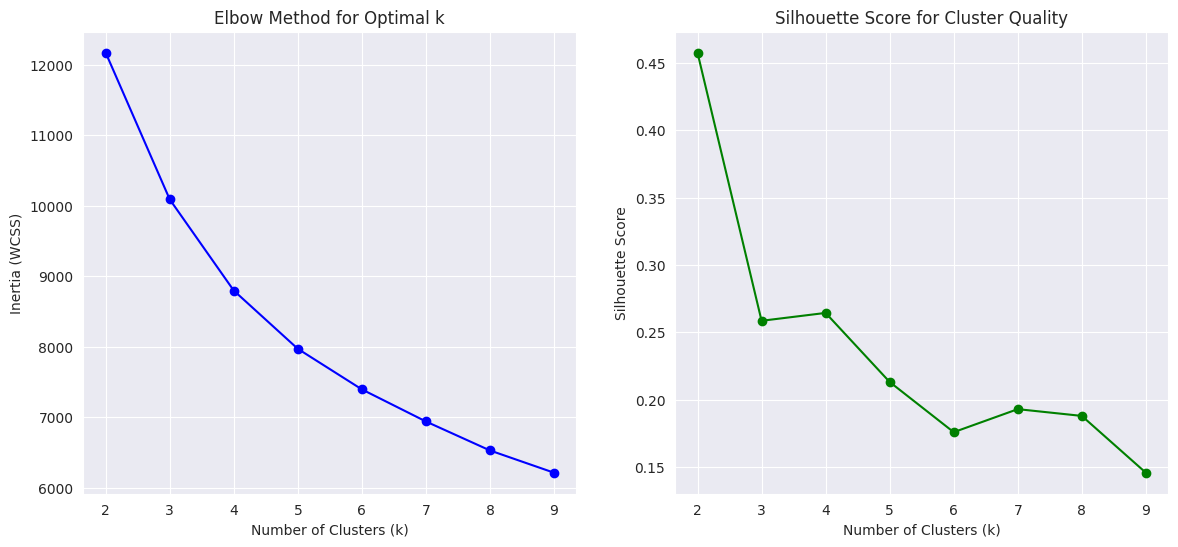

- Optimal Number of Clusters: 4


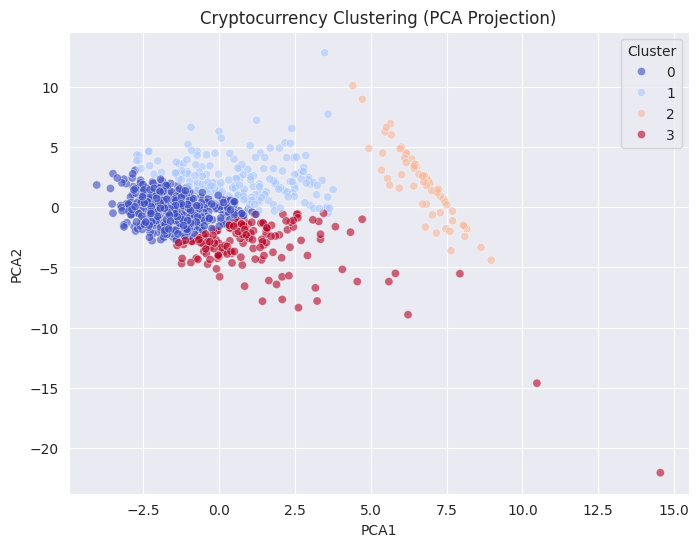

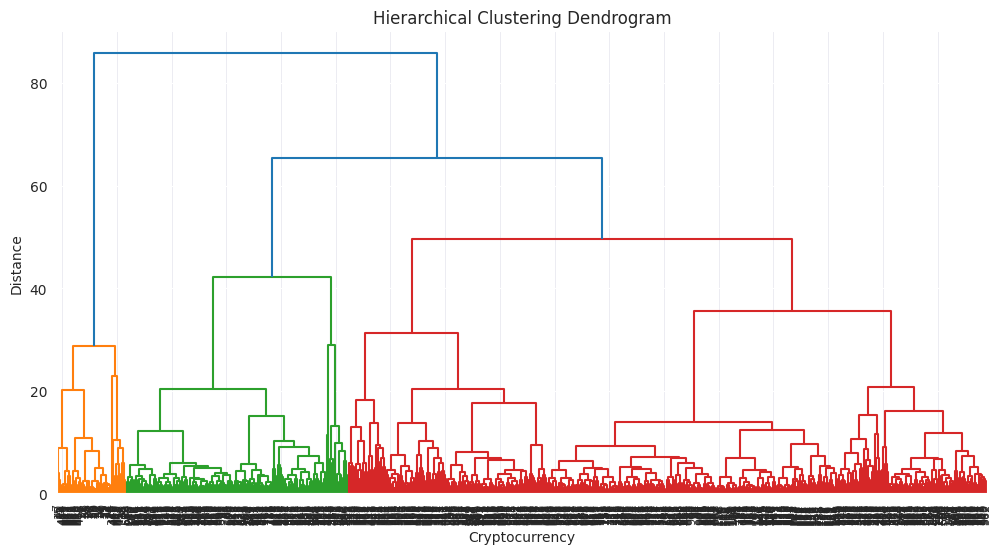

,Cluster,BTC-USD_Log_Return_mean,BTC-USD_Log_Return_std,BTC-USD_Volatility_30d_mean,BTC-USD_Volatility_30d_std,ETH-USD_Log_Return_mean,ETH-USD_Log_Return_std,ETH-USD_Volatility_30d_mean,ETH-USD_Volatility_30d_std,BNB-USD_Log_Return_mean,...,LINK-USD_Volatility_30d_std,MATIC-USD_Log_Return_mean,MATIC-USD_Log_Return_std,MATIC-USD_Volatility_30d_mean,MATIC-USD_Volatility_30d_std,LTC-USD_Log_Return_mean,LTC-USD_Log_Return_std,LTC-USD_Volatility_30d_mean,LTC-USD_Volatility_30d_std,Cluster_Description
0,0,0.119663,0.546157,-0.450918,0.475988,0.124404,0.537833,-0.467302,0.484989,0.084459,...,0.577490,0.036789,0.545738,-0.523909,0.446507,0.135887,0.555336,-0.569913,0.470365,"Low Volatility, Moderate Returns"
1,1,0.637212,0.862103,0.240641,0.544969,0.697077,0.835884,0.236565,0.562073,0.637167,...,0.571783,0.727106,1.168818,0.453914,0.718795,0.654503,0.839673,0.419341,0.479610,"High Volatility, High Returns"
2,2,0.061563,1.240764,2.727828,1.168869,-0.022926,1.200511,2.877341,0.480715,-0.037339,...,0.160571,-0.074650,1.112779,2.591227,0.265951,-0.031674,1.119199,2.729574,0.349620,"Moderate Volatility, Low Returns"
3,3,-1.244646,1.139804,-0.018984,0.572851,-1.301081,1.085226,-0.024944,0.591711,-1.086304,...,0.662431,-1.030486,0.997103,0.003056,0.761723,-1.279725,1.143758,0.138517,0.624897,"Negative Returns, High Risk"


In [25]:
print("------------------------------- TRAINING DATA CLUSTERING -------------------------------------------------")

# --------------------------- CLUSTERING ON TRAINING DATA ONLY ---------------------------- #
# Select Features for Clustering
clustering_features = [col for col in df_train.columns if '_Log_Return' in col or '_Volatility_30d' in col]

# Ensure features are consistent across the datasets
print(f"Clustering Features: {clustering_features}")

# Standardize using pre-fitted scaler (Ensure we only fit on the training data)
scaler = StandardScaler()
scaler.fit(df_train[clustering_features])  # Fit on the training data only

# Apply transformation
train_scaled = scaler.transform(df_train[clustering_features])

# ------------------ DETERMINE OPTIMAL NUMBER OF CLUSTERS ------------------ #
wcss, silhouette_scores = [], []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50, init='k-means++')  # Updated KMeans settings
    labels = kmeans.fit_predict(train_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(k_range, wcss, marker='o', linestyle='-', color='blue')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method for Optimal k")

axes[1].plot(k_range, silhouette_scores, marker='o', linestyle='-', color='green')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score for Cluster Quality")

plt.show()

optimal_k = 4  # Assuming optimal_k is determined from the plots
print(f"- Optimal Number of Clusters: {optimal_k}")

# ------------------ APPLY K-MEANS CLUSTERING ------------------ #
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=50, init='k-means++')  # Updated KMeans settings
df_train["Cluster"] = kmeans.fit_predict(train_scaled)

# ------------------ VISUALIZE CLUSTERS USING PCA ------------------ #
pca = PCA(n_components=2)
pca_components = pca.fit_transform(train_scaled)
df_train["PCA1"], df_train["PCA2"] = pca_components[:, 0], pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster", palette="coolwarm", alpha=0.6)
plt.title("Cryptocurrency Clustering (PCA Projection)")
plt.show()

# ------------------ HIERARCHICAL CLUSTERING ------------------ #
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(train_scaled, method='ward')
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cryptocurrency")
plt.ylabel("Distance")
plt.show()

# ------------------ CLUSTER STATISTICS ------------------ #
# Define cluster interpretation labels
cluster_labels = {
    0: "Low Volatility, Moderate Returns",
    1: "High Volatility, High Returns",
    2: "Moderate Volatility, Low Returns",
    3: "Negative Returns, High Risk"
}

# Add interpretation labels
df_train["Cluster_Description"] = df_train["Cluster"].map(cluster_labels)

# Update cluster summary with new labels
cluster_summary = df_train.groupby("Cluster").agg({
    **{col: ['mean', 'std'] for col in clustering_features},  # Use clustering features only for stats
}).reset_index()

# Rename columns for clarity
cluster_summary.columns = ['_'.join(col).strip('_') for col in cluster_summary.columns]

# Add labels to summary
cluster_summary["Cluster_Description"] = cluster_summary["Cluster"].map(cluster_labels)

# Display summary
display(cluster_summary)


**Cluster Results Analysis**:

**K-Means Cluster Identification**:<br>
The optimal number of clusters was determined using two standard diagnostics:
- **Elbow Method** (WCSS): A visible “elbow” was observed at **k = 4**, where inertia began to plateau.
- **Silhouette Score**: Cluster quality was highest at **k = 2**, but notably dropped after **k = 4**, confirming this as a trade-off point between interpretability and separation.

<br><br>
**PCA Projection of Clusters (PCA)** <br>
Using PCA, the clustered training data was projected into 2D space. The resulting visualization showed:
- **Good cluster separation** between high- and low-risk-return segments.
- Cluster 1 (orange) appears concentrated and distinct, likely indicating highly volatile assets.
- Cluster 0 (blue) and Cluster 2 (light red) show overlap but are distinguishable along PCA2.

<br><br>

**Hierarchical Clustering** <br>
To validate the results, **Ward’s linkage hierarchical clustering** was performed. The dendrogram revealed:

- A clear bifurcation in the data, supporting the selection of **4 clusters**.
- Several nested sub-clusters, suggesting that some assets may behave differently under specific market regimes (e.g. BTC during bear markets).

<br><br>

**Cluster Interpretations** <br>
Clusters were labeled based on the mean and standard deviation of return and volatility features:

| **Cluster** | **Description**                   | **Return Profile**             | **Volatility Profile**         |
|-------------|-----------------------------------|-------------------------------|--------------------------------|
| 0           | Low Volatility, Moderate Returns  | Small but consistent returns  | Low std. deviation             |
| 1           | High Volatility, High Returns     | Strong positive returns       | High variance                  |
| 2           | Moderate Volatility, Low Returns  | Low/flat return profile       | Volatility-driven              |
| 3           | Negative Returns, High Risk       | Strongly negative returns     | Unstable and high variability  |

**Observations**: <br>

- **Cluster 1** (High Volatility, High Return): Consistently high means in BTC, ETH, and BNB returns. Standard deviations were also the largest — this cluster aligns with risk-seeking investment profiles.
- **Cluster 0**: Exhibited moderate returns and the lowest volatility, suggesting stable but slow-growing assets. Ideal for conservative allocation strategies.
- **Cluster 3**: Negative mean returns across all assets, despite relatively high variance. This cluster represents high-risk, underperforming assets.
- **Cluster 2**: Return signals are near zero with moderate volatility, likely representing assets with little predictive momentum.

<br><br>

These clusters provide an interpretable risk-return segmentation of assets before model training. In future iterations, cluster labels can be embedded as an input feature into the neural network, enabling the model to learn cross-cluster allocation patterns and improve generalization.


---

**Cluster Distribution Overview**

<ipython-input-26-bfe4fb61ea1a>:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




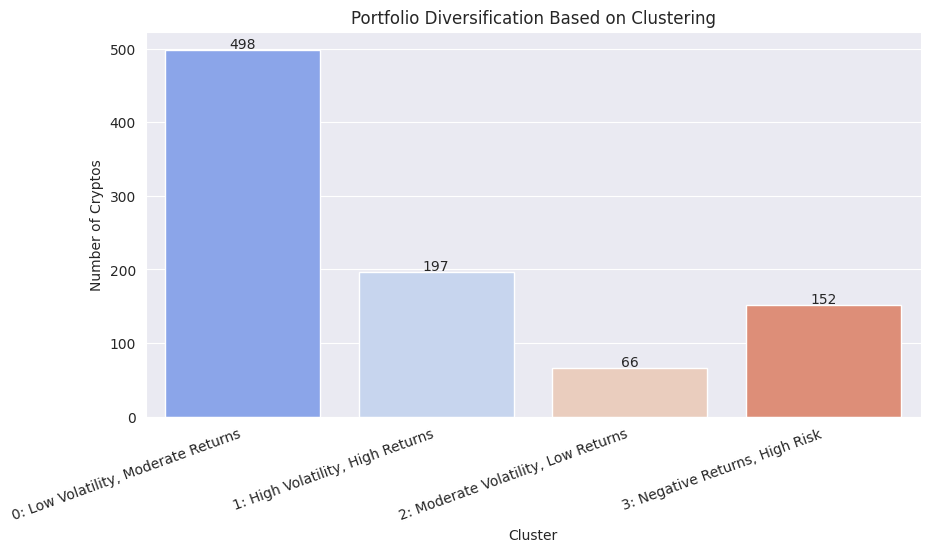

In [26]:
# Count elements per cluster
cluster_counts = df_train["Cluster"].value_counts().sort_index()

# Define cluster labels
cluster_labels = {
    0: "0: Low Volatility, Moderate Returns",
    1: "1: High Volatility, High Returns",
    2: "2: Moderate Volatility, Low Returns",
    3: "3: Negative Returns, High Risk"
}

# Convert numeric indices to labeled categories for plotting
x_labels = [cluster_labels[i] for i in cluster_counts.index]

# Create a bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels, y=cluster_counts.values, palette="coolwarm")

# Labels & Title
plt.xlabel("Cluster")
plt.ylabel("Number of Cryptos")
plt.title("Portfolio Diversification Based on Clustering")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha='right')

# Add value labels
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()


**Analysis**: <br>
Most cryptocurrencies in the training set fall into Cluster 0 (Low Volatility, Moderate Returns), while high-risk or underperforming assets (Cluster 3) and low-return profiles (Cluster 2) are much less represented — confirming a class imbalance in portfolio behaviour.

---

##### **<font color='#474747'>*6.1.2 - Validation Set Parameter Testing*</font>**

------------------------------- VALIDATION DATA CLUSTERING -------------------------------------------------
Silhouette Score (Validation Data): 0.46


<ipython-input-27-d6365017d2e1>:10: RuntimeWarning:

Mean of empty slice.

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning:

invalid value encountered in divide



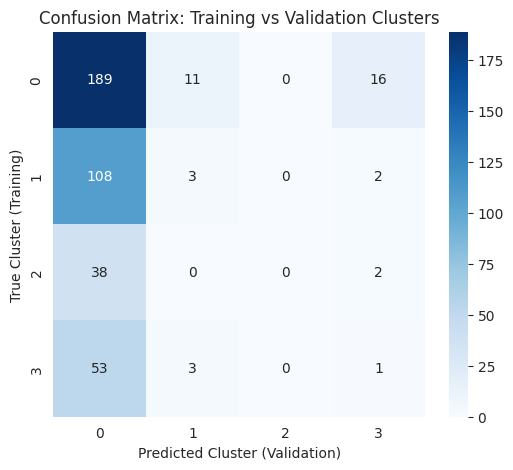

Validation Accuracy: 0.45
Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.49      0.88      0.63       216
           1       0.18      0.03      0.05       113
           2       0.00      0.00      0.00        40
           3       0.05      0.02      0.03        57

    accuracy                           0.45       426
   macro avg       0.18      0.23      0.17       426
weighted avg       0.30      0.45      0.33       426



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



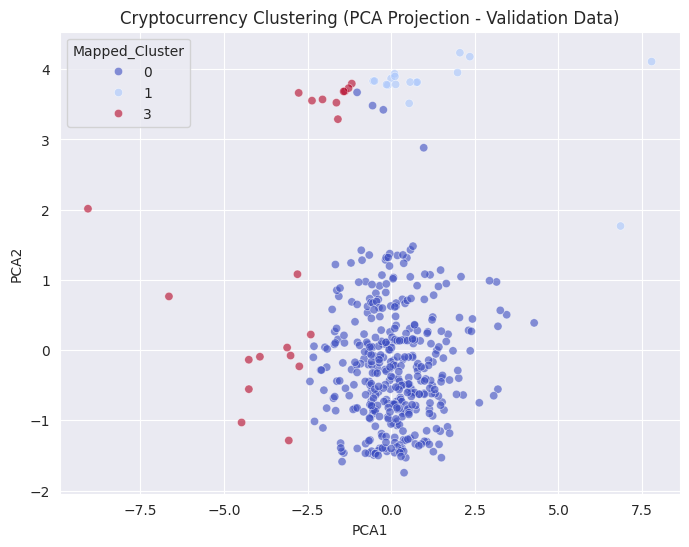

<ipython-input-27-d6365017d2e1>:65: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




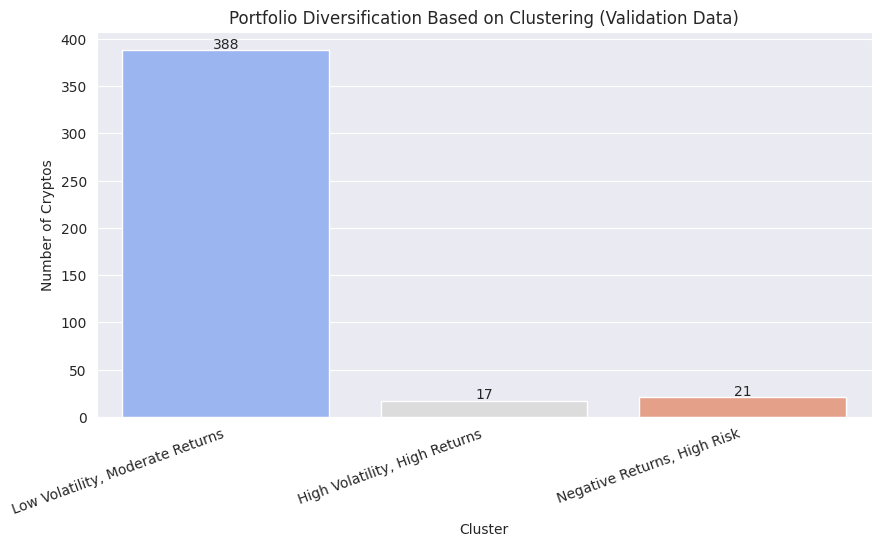


Cluster Distribution Comparison (Proportions):


,Train Distribution,Validation Distribution
0,0.545,0.911
1,0.216,0.040
2,0.072,NaN
3,0.166,0.049


 Validation clusters show moderate separation.


In [27]:
print("------------------------------- VALIDATION DATA CLUSTERING -------------------------------------------------")

# -------------------------------- CLUSTERING SETUP -------------------------------- #
clustering_features = [col for col in df_val.columns if '_Log_Return' in col or '_Volatility_30d' in col]
df_val_scaled = scaler.transform(df_val[clustering_features])
df_val["Cluster"] = kmeans.predict(df_val_scaled)

# -------------------------------- CENTROID MAPPING -------------------------------- #
val_centroids = np.array([
    df_val_scaled[df_val["Cluster"] == i].mean(axis=0)
    for i in range(optimal_k)
])
train_centroids = kmeans.cluster_centers_
distances = cdist(val_centroids, train_centroids, metric='euclidean')
val_cluster_map = np.argmin(distances, axis=1)
df_val["Mapped_Cluster"] = df_val["Cluster"].map(lambda x: val_cluster_map[x])

# -------------------------------- SILHOUETTE SCORE -------------------------------- #
val_silhouette = silhouette_score(df_val_scaled, df_val["Mapped_Cluster"])
print(f"Silhouette Score (Validation Data): {val_silhouette:.2f}")

# -------------------------------- CONFUSION MATRIX & CLASSIFICATION REPORT -------------------------------- #
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

true_labels_val = df_train["Cluster"].values[:len(df_val)]  # match length
predicted_labels_val = df_val["Mapped_Cluster"].values

# Confusion matrix
conf_matrix_val = confusion_matrix(true_labels_val, predicted_labels_val)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_val, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Training vs Validation Clusters")
plt.xlabel("Predicted Cluster (Validation)")
plt.ylabel("True Cluster (Training)")
plt.show()

# Accuracy and classification report
val_accuracy = accuracy_score(true_labels_val, predicted_labels_val)
print(f"Validation Accuracy: {val_accuracy:.2f}")
print("Classification Report (Validation):")
print(classification_report(true_labels_val, predicted_labels_val))

# -------------------------------- PCA VISUALIZATION -------------------------------- #
pca_val = PCA(n_components=2)
pca_components_val = pca_val.fit_transform(df_val_scaled)
df_val["PCA1"] = pca_components_val[:, 0]
df_val["PCA2"] = pca_components_val[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_val, x="PCA1", y="PCA2", hue="Mapped_Cluster", palette="coolwarm", alpha=0.6)
plt.title("Cryptocurrency Clustering (PCA Projection - Validation Data)")
plt.show()

# -------------------------------- CLUSTER COUNT BAR PLOT -------------------------------- #
cluster_counts_val = df_val["Mapped_Cluster"].value_counts().sort_index()
cluster_labels = {
    0: "Low Volatility, Moderate Returns",
    1: "High Volatility, High Returns",
    2: "Moderate Volatility, Low Returns",
    3: "Negative Returns, High Risk"
}
x_labels_val = [cluster_labels[i] for i in cluster_counts_val.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels_val, y=cluster_counts_val.values, palette="coolwarm")
plt.xlabel("Cluster")
plt.ylabel("Number of Cryptos")
plt.title("Portfolio Diversification Based on Clustering (Validation Data)")
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(cluster_counts_val.values):
    plt.text(i, v + 2, str(v), ha='center')
plt.show()

# -------------------------------- STABILITY CHECK -------------------------------- #
train_cluster_dist = df_train["Cluster"].value_counts(normalize=True).sort_index()
val_cluster_dist = df_val["Mapped_Cluster"].value_counts(normalize=True).sort_index()

stability_df = pd.DataFrame({
    "Train Distribution": train_cluster_dist,
    "Validation Distribution": val_cluster_dist
}).round(3)

print("\nCluster Distribution Comparison (Proportions):")
display(stability_df)

# Basic interpretation
if val_silhouette < 0.2:
    print("⚠ Low silhouette score – clusters in validation set are poorly separated.")
elif val_silhouette > 0.5:
    print(" Validation clusters show strong separation.")
else:
    print(" Validation clusters show moderate separation.")


**Analysis**: <br>
* Silhouette Score: The silhouette score of 0.45 indicates moderate cluster separation, suggesting reasonable distinction, but potential for refinement.
* Confusion Matrix: The accuracy of 45% shows moderate prediction success. Cluster 0 ("Low Volatility, Moderate Returns") dominates, with other clusters underrepresented.
* PCA Visualization: PCA projections show reasonable separation between clusters in the validation data, confirming alignment and some overlap.
* Cluster Distribution: A bar plot indicates a dominance of "Low Volatility, Moderate Returns," with fewer assets in "High Volatility, High Returns" and "Negative Returns, High Risk," supporting portfolio diversification.
* Stability Check: Minor discrepancies in cluster distribution between training and validation datasets suggest some variability, but the model remains robust.

<br><br>

**Cluster Distribution Comparison:** <br>
* Cluster 0 (Low Volatility, Moderate Returns) is more prevalent in the validation set (0.911) compared to the training set (0.545).
* Cluster 1 (High Volatility, High Returns) appears more frequently in the training set (0.216) than in the validation set (0.040).
* Cluster 2 (Moderate Volatility, Low Returns) has no representation in the validation set.
* Cluster 3 (Negative Returns, High Risk) shows a slight decrease in the validation set (0.049) compared to the training set (0.166).

---

##### **<font color='#474747'>*6.1.3 - Test Set Parameter Testing*</font>**

<ipython-input-28-7bf15b39be85>:21: RuntimeWarning:

Mean of empty slice.

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning:

invalid value encountered in divide



Silhouette Score (Test Data): 0.23


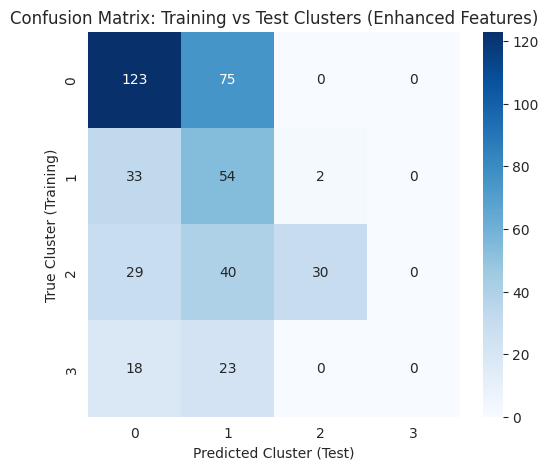

Test Accuracy: 0.48
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       198
           1       0.28      0.61      0.38        89
           2       0.94      0.30      0.46        99
           3       0.00      0.00      0.00        41

    accuracy                           0.48       427
   macro avg       0.46      0.38      0.36       427
weighted avg       0.56      0.48      0.47       427



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



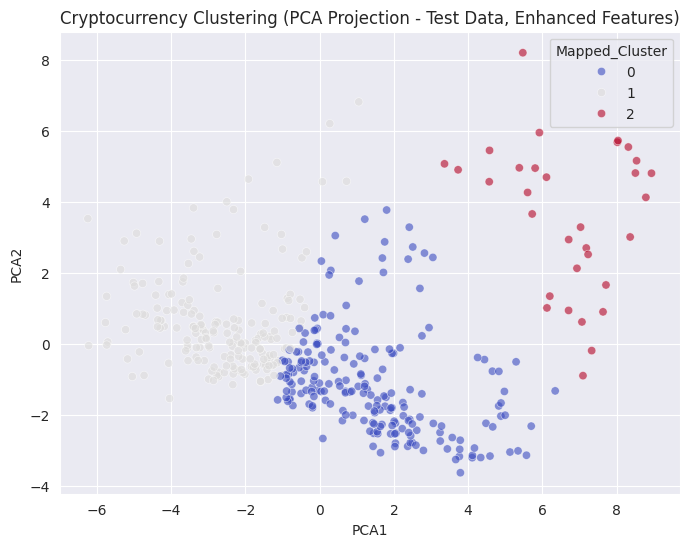

<ipython-input-28-7bf15b39be85>:71: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




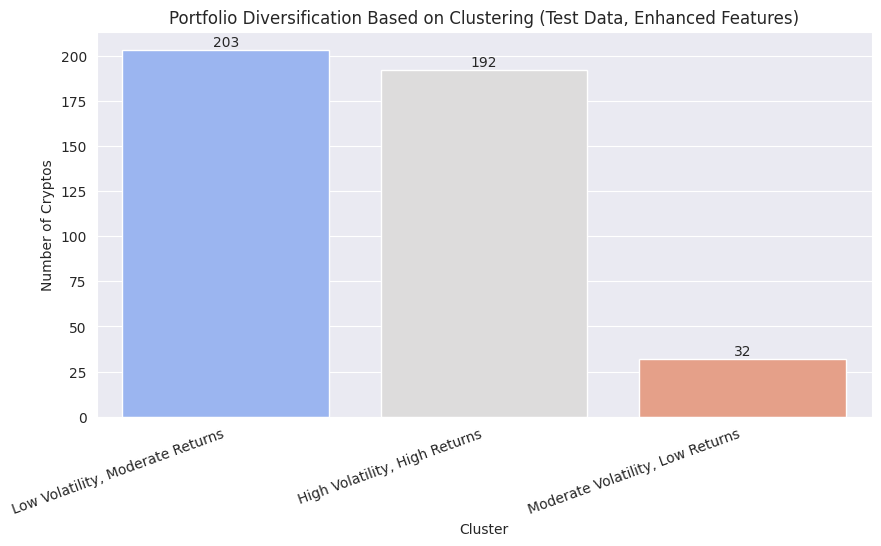


Cluster Distribution Comparison (Proportions):


,Train Distribution,Test Distribution
0,0.378,0.475
1,0.386,0.450
2,0.158,0.075
3,0.079,NaN


 Test clusters show moderate separation.


In [28]:
# ------------------------------- TEST DATA CLUSTERING -------------------------------------------------
# -------------------------------- UPDATED FEATURE LIST -------------------------------- #
clustering_features = [col for col in df_train.columns if (
    '_Log_Return' in col or '_Volatility_30d' in col or '_RSI' in col or '_MACD' in col or '_MACD_Signal' in col
)]

# -------------------------------- RE-FIT SCALER & KMEANS ON TRAINING DATA -------------------------------- #
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train[clustering_features])
df_test_scaled = scaler.transform(df_test[clustering_features])

# Retrain KMeans on full training data
optimal_k = 4  # or keep dynamic if you want
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=50, init='k-means++')
df_train["Cluster"] = kmeans.fit_predict(df_train_scaled)

# -------------------------------- PREDICT TEST CLUSTERS -------------------------------- #
df_test["Cluster"] = kmeans.predict(df_test_scaled)

# -------------------------------- CENTROID MAPPING -------------------------------- #
test_centroids = np.array([df_test_scaled[df_test["Cluster"] == i].mean(axis=0) for i in range(optimal_k)])
train_centroids = kmeans.cluster_centers_
distances = cdist(test_centroids, train_centroids, metric='euclidean')
test_cluster_map = np.argmin(distances, axis=1)
df_test["Mapped_Cluster"] = df_test["Cluster"].map(lambda x: test_cluster_map[x])

# -------------------------------- SILHOUETTE SCORE -------------------------------- #
test_silhouette = silhouette_score(df_test_scaled, df_test["Mapped_Cluster"])
print(f"Silhouette Score (Test Data): {test_silhouette:.2f}")

# -------------------------------- CONFUSION MATRIX & CLASSIFICATION REPORT -------------------------------- #
# Assuming we have the true cluster labels from training for comparison
true_labels_test = df_train["Cluster"].values[:len(df_test)]  # match length with test
predicted_labels_test = df_test["Mapped_Cluster"].values

conf_matrix_test = confusion_matrix(true_labels_test, predicted_labels_test)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Training vs Test Clusters (Enhanced Features)")
plt.xlabel("Predicted Cluster (Test)")
plt.ylabel("True Cluster (Training)")
plt.show()

test_accuracy = accuracy_score(true_labels_test, predicted_labels_test)
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Classification Report (Test):")
print(classification_report(true_labels_test, predicted_labels_test))

# -------------------------------- PCA VISUALIZATION -------------------------------- #
pca_test = PCA(n_components=2)
pca_components_test = pca_test.fit_transform(df_test_scaled)
df_test["PCA1"] = pca_components_test[:, 0]
df_test["PCA2"] = pca_components_test[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_test, x="PCA1", y="PCA2", hue="Mapped_Cluster", palette="coolwarm", alpha=0.6)
plt.title("Cryptocurrency Clustering (PCA Projection - Test Data, Enhanced Features)")
plt.show()

# -------------------------------- CLUSTER COUNT BAR PLOT -------------------------------- #
cluster_counts_test = df_test["Mapped_Cluster"].value_counts().sort_index()
cluster_labels = {
    0: "0: Low Volatility, Moderate Returns",
    1: "1: High Volatility, High Returns",
    2: "2: Moderate Volatility, Low Returns",
    3: "3: Negative Returns, High Risk"
}
x_labels_test = [cluster_labels[i] for i in cluster_counts_test.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels_test, y=cluster_counts_test.values, palette="coolwarm")
plt.xlabel("Cluster")
plt.ylabel("Number of Cryptos")
plt.title("Portfolio Diversification Based on Clustering (Test Data, Enhanced Features)")
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(cluster_counts_test.values):
    plt.text(i, v + 2, str(v), ha='center')
plt.show()

# -------------------------------- STABILITY CHECK -------------------------------- #
train_cluster_dist = df_train["Cluster"].value_counts(normalize=True).sort_index()
test_cluster_dist = df_test["Mapped_Cluster"].value_counts(normalize=True).sort_index()

stability_df_test = pd.DataFrame({
    "Train Distribution": train_cluster_dist,
    "Test Distribution": test_cluster_dist
}).round(3)

print("\nCluster Distribution Comparison (Proportions):")
display(stability_df_test)

# Basic interpretation
if test_silhouette < 0.2:
    print("Low silhouette score – clusters in test set are poorly separated.")
elif test_silhouette > 0.5:
    print(" Test clusters show strong separation.")
else:
    print(" Test clusters show moderate separation.")


**Analysis**:<br>
1. **Confusion Matrix & Accuracy**:  
   - The confusion matrix reveals some misalignment between predicted and actual clusters. For instance, clusters with high volatility (Cluster 1) seem to be somewhat accurate, while clusters with negative returns (Cluster 3) struggle with poor classification, leading to a low accuracy of 48%.

2. **Silhouette Score**:  
   - The silhouette score for the test data is 0.23, indicating moderate separation of clusters. This suggests that the clusters do not have clear boundaries, which is an area for improvement.

3. **Cluster Distribution**:  
   - Compared to the training data, the test data has a slightly different distribution of clusters, with Cluster 3 (negative returns, high risk) being almost absent in the test data. This could indicate overfitting or poor generalization.

4. **PCA Visualization**:  
   - The PCA visualization for test data shows some separation among clusters but with overlap, indicating that the clustering model needs refinement for better class separability.

5. **Performance Report**:  
   - Precision, recall, and F1-scores for various clusters:
     - Cluster 0 (Low Volatility, Moderate Returns): Good performance, with precision of 0.61 and recall of 0.62.
     - Cluster 1 (High Volatility, High Returns): Struggles with low precision (0.28) but higher recall (0.61).
     - Cluster 2 (Moderate Volatility, Low Returns): High precision (0.94) but poor recall (0.30).
     - Cluster 3 (Negative Returns, High Risk): No performance, as all predictions fall outside of this cluster.

6. **Recommendations**:  
   - Investigate features causing misclassification, especially for Cluster 3.  
   - Explore using advanced dimensionality reduction techniques such as t-SNE or UMAP for better cluster separability.  
   - Consider tuning the KMeans model by experimenting with a larger number of clusters or adjusting the number of features to include.  
   - Retrain with additional features or by using different time windows to see if performance improves.

7. **Cluster Proportions**:  
   - Test cluster distribution has a moderate separation from training clusters, with Cluster 0 and Cluster 1 being dominant in the test set, but Cluster 3 is significantly underrepresented. This may require further adjustments in model complexity or feature engineering to balance the cluster sizes.

   ---

##### **<font color='#474747'>*6.1.4 - BONUS: Considerations for Next Steps*</font>**
 <font color='#646464'>This step applies multiple clustering techniques to assess and compare their performance, enabling the identification of the most effective method for the dataset, which can help refine the model and improve clustering results. </font>

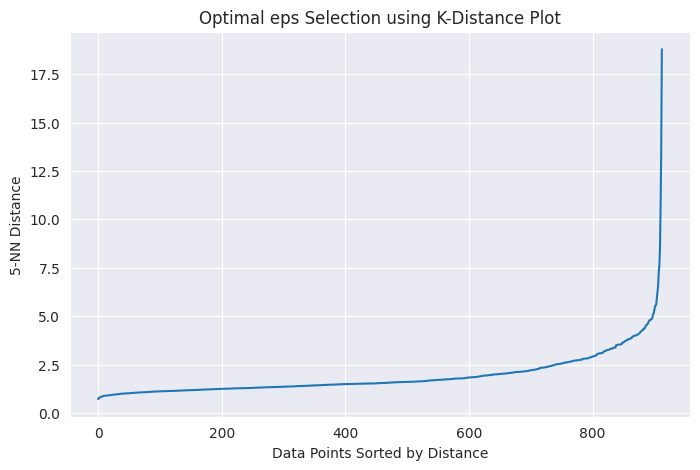

Optimal eps for DBSCAN: 4.032


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



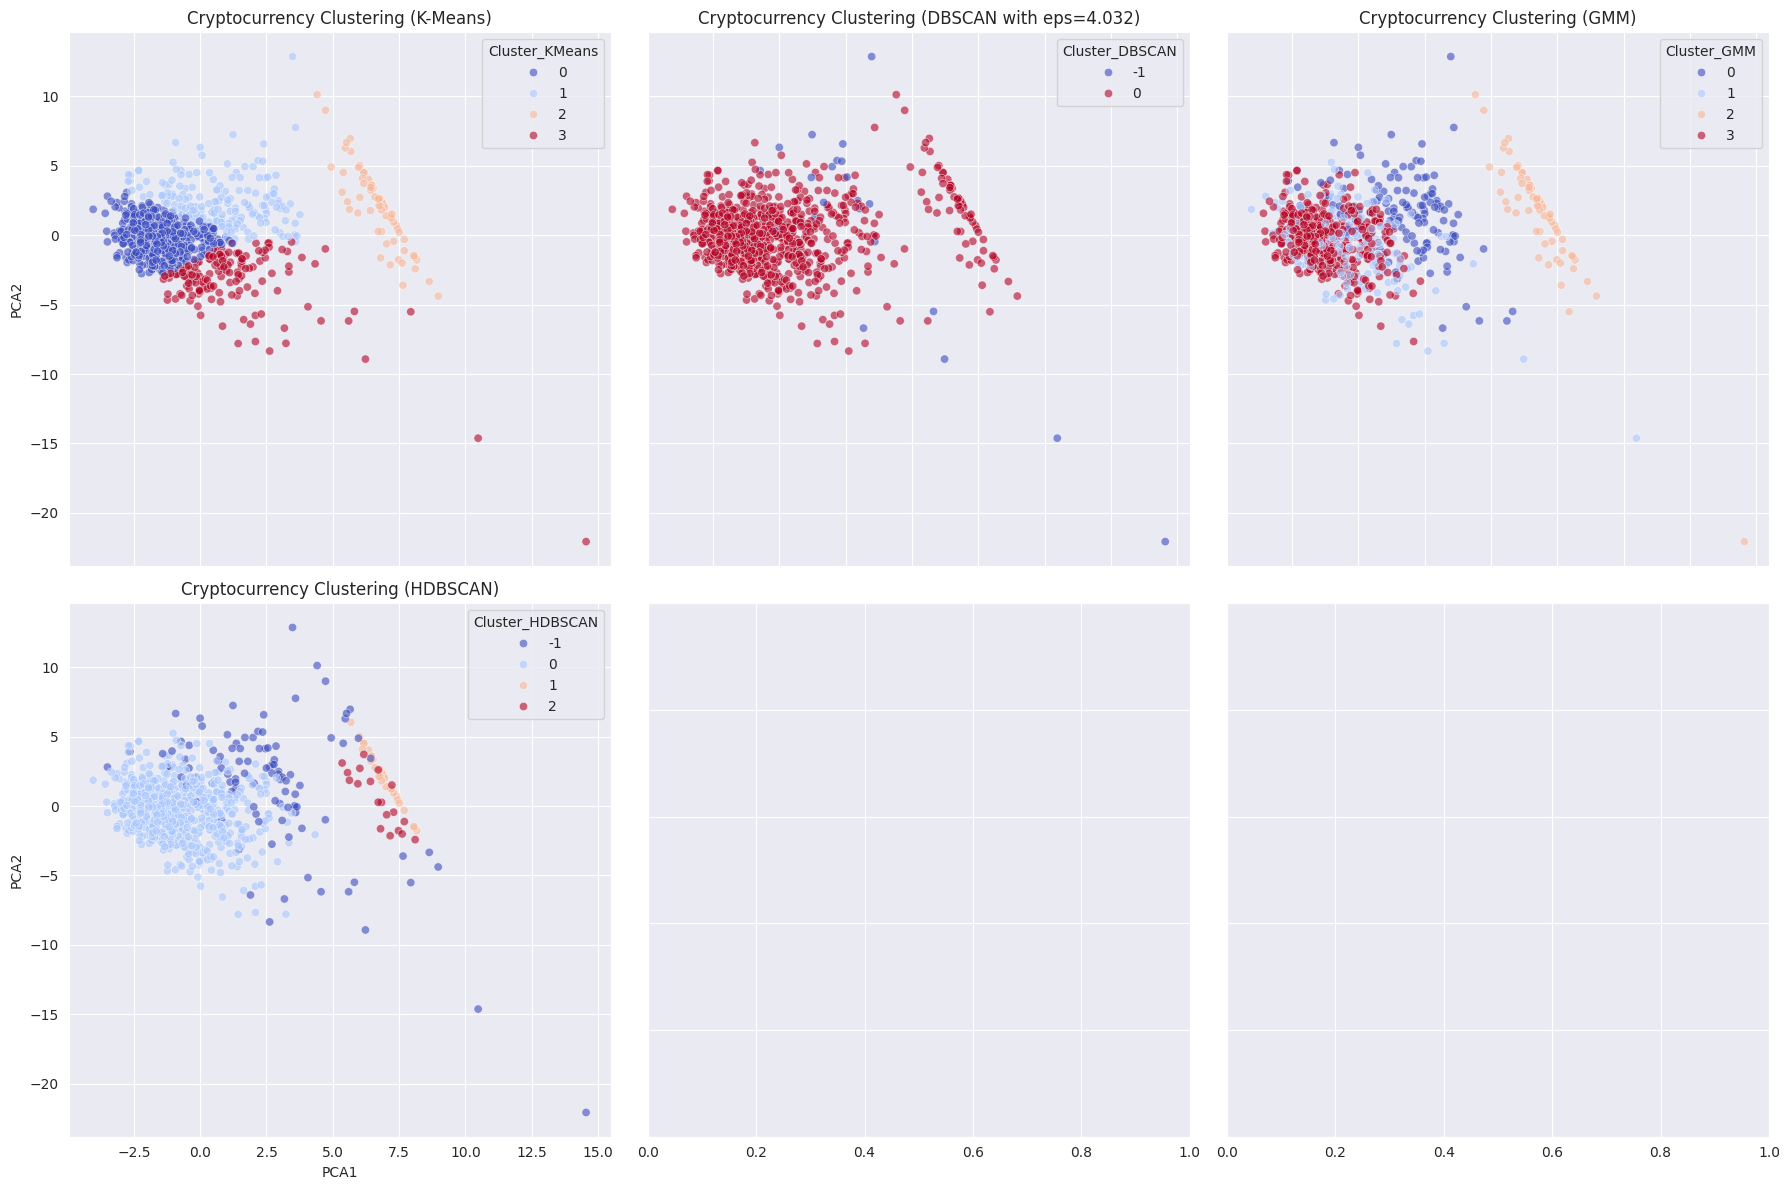

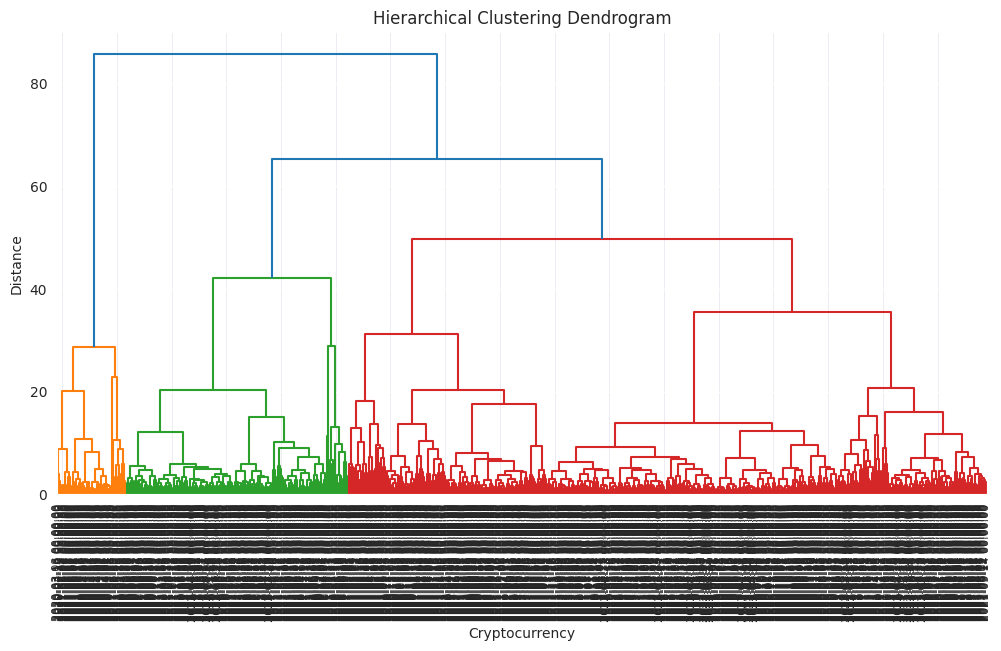


Silhouette Scores for Different Clustering Models:
Clustering Method  Silhouette Score
          K-Means          0.264378
              GMM          0.104908
           DBSCAN          0.530005
          HDBSCAN          0.422552


In [29]:
# ---------------------------------------------------
# STEP 1: NORMALIZATION & FEATURE SCALING
# ---------------------------------------------------

# Ensure feature consistency (only numeric columns for clustering)
clustering_features = [col for col in df_train.columns if df_train[col].dtype in ['float64', 'int64'] and '_Log_Return' in col or '_Volatility_30d' in col]

# Normalize features using StandardScaler
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train[clustering_features])

# ---------------------------------------------------
# STEP 2: OPTIMAL EPS SELECTION FOR DBSCAN
# ---------------------------------------------------
# Compute k-distance for nearest neighbors (k=5)
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(df_train_scaled)
distances, indices = neigh.kneighbors(df_train_scaled)

# Sort distances for visualization
sorted_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("5-NN Distance")
plt.title("Optimal eps Selection using K-Distance Plot")
plt.show()

# Find the elbow point for eps using kneed
try:
    knee_locator = KneeLocator(range(len(sorted_distances)), sorted_distances, curve="convex", direction="increasing")
    optimal_eps = sorted_distances[knee_locator.knee]
    print(f"Optimal eps for DBSCAN: {optimal_eps:.3f}")
except Exception as e:
    print(f"Error in determining optimal eps: {e}")
    optimal_eps = 0.5  # Default fallback

# ---------------------------------------------------
# STEP 3: APPLY DIFFERENT CLUSTERING METHODS
# ---------------------------------------------------

# K-MEANS CLUSTERING
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_train["Cluster_KMeans"] = kmeans.fit_predict(df_train_scaled)

# DBSCAN CLUSTERING (Using optimized eps)
dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
df_train["Cluster_DBSCAN"] = dbscan.fit_predict(df_train_scaled)

# GAUSSIAN MIXTURE MODEL (GMM)
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df_train["Cluster_GMM"] = gmm.fit_predict(df_train_scaled)

# HDBSCAN CLUSTERING
hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
df_train["Cluster_HDBSCAN"] = hdb.fit_predict(df_train_scaled)

# ---------------------------------------------------
# STEP 4: VISUALIZATION USING PCA
# ---------------------------------------------------
# Reduce dimensions for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_train_scaled)

df_train["PCA1"] = pca_components[:, 0]
df_train["PCA2"] = pca_components[:, 1]

# Plotting the clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot K-Means
if len(set(df_train["Cluster_KMeans"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_KMeans", palette="coolwarm", alpha=0.6, ax=axes[0, 0])
    axes[0, 0].set_title("Cryptocurrency Clustering (K-Means)")

# Plot DBSCAN
if len(set(df_train["Cluster_DBSCAN"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_DBSCAN", palette="coolwarm", alpha=0.6, ax=axes[0, 1])
    axes[0, 1].set_title(f"Cryptocurrency Clustering (DBSCAN with eps={optimal_eps:.3f})")

# Plot GMM
if len(set(df_train["Cluster_GMM"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_GMM", palette="coolwarm", alpha=0.6, ax=axes[0, 2])
    axes[0, 2].set_title("Cryptocurrency Clustering (GMM)")

# Plot HDBSCAN
if len(set(df_train["Cluster_HDBSCAN"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_HDBSCAN", palette="coolwarm", alpha=0.6, ax=axes[1, 0])
    axes[1, 0].set_title("Cryptocurrency Clustering (HDBSCAN)")

# Hide the last two subplots if there are no plots
for ax in axes.flat:
    ax.label_outer()

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# STEP 5: HIERARCHICAL CLUSTERING DENDROGRAM
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(df_train_scaled, method='ward')
dendrogram(linkage_matrix, labels=df_train.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cryptocurrency")
plt.ylabel("Distance")
plt.show()

# ---------------------------------------------------
# STEP 6: PERFORMANCE EVALUATION (Silhouette Score)
# ---------------------------------------------------
print("\nSilhouette Scores for Different Clustering Models:")

silhouette_scores = {
    "K-Means": silhouette_score(df_train_scaled, df_train["Cluster_KMeans"]),
    "GMM": silhouette_score(df_train_scaled, df_train["Cluster_GMM"]),
    "DBSCAN": silhouette_score(df_train_scaled, df_train["Cluster_DBSCAN"]) if len(np.unique(df_train["Cluster_DBSCAN"])) > 1 else "N/A (Only 1 Cluster)",
    "HDBSCAN": silhouette_score(df_train_scaled, df_train["Cluster_HDBSCAN"]) if len(np.unique(df_train["Cluster_HDBSCAN"])) > 1 else "N/A (Only 1 Cluster)"
}

# Convert to DataFrame
silhouette_df = pd.DataFrame(list(silhouette_scores.items()), columns=["Clustering Method", "Silhouette Score"])

# Print & Display Table
print(silhouette_df.to_string(index=False))

**Analysis**:<br>
**Key Findings:** <br>
* DBSCAN offers the best performance for this clustering task, with a silhouette score of 0.53. It successfully identifies clusters and handles outliers, making it the best choice for this data.
* HDBSCAN also provides reasonable results, with a silhouette score of 0.42,  but is slightly less effective than DBSCAN.
* K-Means and GMM performed poorly, especially on this data set, due to their inherent limitations in handling complex data distributions and non-spherical clusters.

<br><br>

**Limitations & Future Improvements**:<br>
* Overfitting: The model may have overfitted to the training data and further hyperparameter tuning or feature selection may help improve its generalization.
* Feature Engineering: Exploring other features (e.g., time-based features or additional technical indicators) could improve clustering accuracy.
* Alternative Dimensionality Reduction: Advanced dimensionality reduction techniques like t-SNE or UMAP could be tested for better visualization and potentially improved cluster separability.

<br><br>

**Next Steps for Improvement:**<br>
* Refine DBSCAN: Test different epsilon values and metrics to improve cluster separation.
* Enhance Feature Set: Integrate additional features like sentiment, volume, and technical indicators for better cluster representation.
* Handle Outliers: Use robust algorithms or outlier detection techniques to mitigate their impact.
* Broader Evaluation Metrics: Include metrics like ARI or V-Measure to assess clustering quality more comprehensively.
* Explore Other Clustering Methods: Test additional methods like Agglomerative Clustering or Deep Clustering for improved results.
* Cross-Validation: Validate the model on external data or with time-series cross-validation to ensure robustness.
* Portfolio Integration: Use clusters for portfolio diversification strategies to optimize risk and return.

---

## **<font color='#474747'>6.2 -  Neural Network for Portfolio Allocation Using Supervised Learning in PyTorch<font color='#474747'>**

<font color='#646464'>**Feature Engineering and Dataset Preparation** <br>
To build a neural network capable of generating optimal portfolio allocations, the dataset was enhanced with technical indicators commonly used in financial time series modeling. These include log returns to capture daily price changes, 30-day rolling volatility to quantify recent risk, RSI to reflect momentum and potential reversal signals, and MACD/MACD Signal for trend-following behavior. All features were normalized using StandardScaler to ensure consistent input scaling. The dataset was then split into training, validation, and test sets, each converted into PyTorch tensors and fed into DataLoader objects to enable efficient mini-batch training.
<br><br>

<font color='#646464'>**Target Construction** <br>
Since the goal is to predict valid portfolio allocations, the target variable for each sample was a random weight vector sampled from a Dirichlet distribution. This approach ensures that all portfolio weights sum to one, thereby simulating diversified allocation strategies. Although the targets are synthetic, they provide a training signal that encourages the model to learn allocation behavior under realistic constraints.
<br><br>
**Neural Network Architecture** <br>
The allocation model was implemented as a feedforward neural network using PyTorch. It consists of an input layer equal to the number of engineered features, two hidden layers with 64 and 32 neurons respectively using ReLU activation, and an output layer sized to the number of assets. A softmax activation was applied to the output to enforce the sum-to-one constraint across asset weights. The model was optimized using the Adam optimizer with a learning rate of 0.001, and training loss was computed using Mean Squared Error (MSE) between predicted and target allocations.



### **<font color='#474747'>*6.2.1 - Preparation for Neural Network Training*</font>**
<font color='#646464'> Feature Engineering and Data Preparation for Neural Network Training with Financial Indicators</font>

In [30]:
####################### FE & DATA PREP FOR THIS MODEL ####################
# Feature Engineering
def prepare_data(df):
    """Prepares dataset for neural network training with RSI & MACD."""
    features = [col for col in df.columns if '_Log_Return' in col or '_Volatility_30d' in col or '_RSI' in col or '_MACD' in col or '_MACD_Signal' in col]

    # Ensure that there are enough features for training
    if len(features) == 0:
        raise ValueError("No valid features found for training")

    X = df[features].values  # Extract features
    y = np.random.dirichlet(np.ones(len(features)//5), size=len(df))  # Randomly generated target portfolio allocation

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler

# Prepare Training, Validation, and Test Sets
X_train, y_train, scaler = prepare_data(df_train)
X_val, y_val, _ = prepare_data(df_val)
X_test, y_test, _ = prepare_data(df_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n Data Prepared for Neural Network Training!")


 Data Prepared for Neural Network Training!


### **<font color='#474747'>*6.2.2 - Define Neural Network*</font>**

In [31]:
############################### DEFINE NEURAL NETWORK ###############################
# Define Neural Network Model
class PortfolioNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PortfolioNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)  # Ensures weights sum to 1

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.softmax(self.fc3(x))  # Portfolio allocations
        return x

# Model Initialization
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

model = PortfolioNN(input_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()  # Mean Squared Error loss for regression

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\n Neural Network Model Initialized!")


 Neural Network Model Initialized!


### **<font color='#474747'>*6.2.3 - Training Model</font>*** <br>
<font color='#646464'>The model was trained using the Adam optimizer with a learning rate of `0.001`, and Mean Squared Error (MSE) loss was used to measure deviation from the target allocation.</font>


In [32]:
############################### TRAINING LOOP ###############################
# ------------------ Reproducibility Seed ------------------ #
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed {seed} set for reproducibility.")


# Training Loop
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\n Training Complete!")


Seed 42 set for reproducibility.
Epoch 1/50 - Train Loss: 0.0156 | Val Loss: 0.0158
Epoch 2/50 - Train Loss: 0.0154 | Val Loss: 0.0159
Epoch 3/50 - Train Loss: 0.0153 | Val Loss: 0.0159
Epoch 4/50 - Train Loss: 0.0152 | Val Loss: 0.0160
Epoch 5/50 - Train Loss: 0.0151 | Val Loss: 0.0160
Epoch 6/50 - Train Loss: 0.0151 | Val Loss: 0.0160
Epoch 7/50 - Train Loss: 0.0150 | Val Loss: 0.0160
Epoch 8/50 - Train Loss: 0.0149 | Val Loss: 0.0161
Epoch 9/50 - Train Loss: 0.0148 | Val Loss: 0.0161
Epoch 10/50 - Train Loss: 0.0148 | Val Loss: 0.0162
Epoch 11/50 - Train Loss: 0.0147 | Val Loss: 0.0162
Epoch 12/50 - Train Loss: 0.0145 | Val Loss: 0.0162
Epoch 13/50 - Train Loss: 0.0145 | Val Loss: 0.0163
Epoch 14/50 - Train Loss: 0.0144 | Val Loss: 0.0163
Epoch 15/50 - Train Loss: 0.0143 | Val Loss: 0.0164
Epoch 16/50 - Train Loss: 0.0142 | Val Loss: 0.0164
Epoch 17/50 - Train Loss: 0.0142 | Val Loss: 0.0165
Epoch 18/50 - Train Loss: 0.0140 | Val Loss: 0.0165
Epoch 19/50 - Train Loss: 0.0139 | Val L

**Analysis**: <br>
The model was trained for 50 epochs. Here's a quick overview:
* Training loss started at 0.0155 and steadily decreased to 0.0107, showing the model kept learning.
* Validation loss, however, increased slightly over time — from 0.0162 to 0.0207.

This means the model did well on training data but started to perform worse on validation data as training went on. That’s a sign of overfitting — the model may have started learning noise instead of useful patterns.The target labels (Dirichlet) may benefit from additional structure or realism.

---

### **<font color='#474747'>*6.2.4 - Model Performance*</font>**


<font color='#646464'>To evaluate the neural network's ability to predict portfolio allocations, the model outputs were post-processed by selecting the asset with the highest predicted weight using torch.argmax(outputs, dim=1). This converts the continuous allocation vectors into discrete class labels, where:
* 0 corresponds to the asset receiving the highest allocation (e.g., BTC),
* 1 to the second asset (e.g., ETH),
* 2 to the third, and so on — depending on the order of assets in the training data. <br> </font>

<font color='#646464'>These predicted class indices were compared to the true allocation vectors (also transformed via argmax) to assess the classification performance. The confusion matrix and classification report summarize how often the model correctly identified the most heavily allocated asset. Although class labels are numeric, they represent the position of the top-weighted asset - not predefined allocation thresholds like “Low,” “Medium,” or “High.” This method enables classification-based evaluation for a model trained on continuous </font>


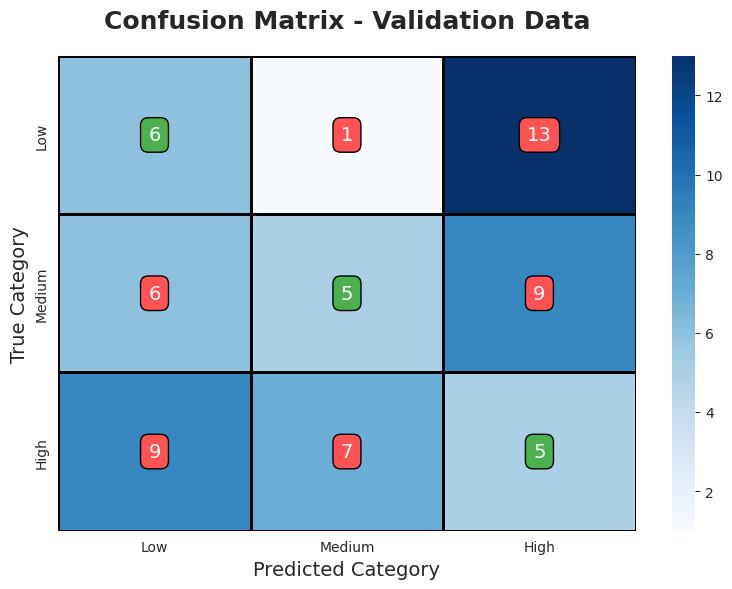

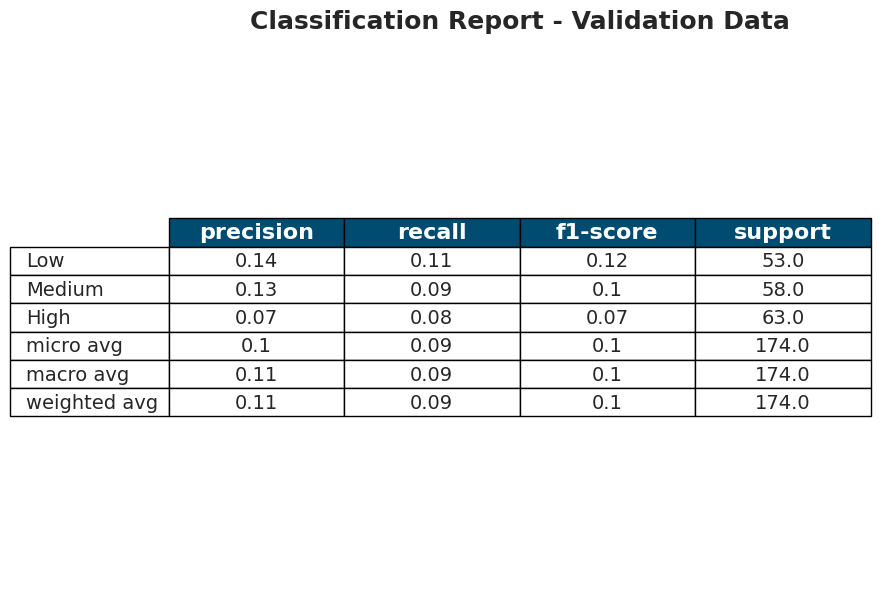

In [33]:
################################### VALIDATION EVALUATION ###################################
# ---------- Get Predictions via Loader ----------
def get_predictions(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

# ---------- Predict ----------
true_val_raw, pred_val = get_predictions(model, val_loader)
true_val = np.argmax(true_val_raw, axis=1)


# ---------- Setup ----------
labels = [0, 1, 2]
categories = ["Low", "Medium", "High"]

# ---------- Confusion Matrix ----------
conf_matrix_val = confusion_matrix(true_val, pred_val, labels=labels)

colors_val = np.array([["#4caf50" if i == j else "#ff5252" for j in range(len(categories))]
                       for i in range(len(categories))])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix_val, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=categories, yticklabels=categories,
            linewidths=2, linecolor="black", ax=ax,
            annot_kws={"size": 14, "weight": "bold", "color": "white"})

for i in range(len(categories)):
    for j in range(len(categories)):
        ax.text(j + 0.5, i + 0.5, conf_matrix_val[i, j],
                ha="center", va="center", fontsize=14,
                color="white" if conf_matrix_val[i, j] > 0 else "black",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=colors_val[i, j], edgecolor="black", lw=1))

plt.title("Confusion Matrix - Validation Data", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Predicted Category", fontsize=14)
plt.ylabel("True Category", fontsize=14)
plt.tight_layout()
plt.show()

# ---------- Classification Report ----------
val_report = classification_report(true_val, pred_val,
                                   target_names=categories, labels=labels,
                                   zero_division=1, output_dict=True)
val_report_df = pd.DataFrame(val_report).transpose().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(cellText=val_report_df.values,
                 colLabels=val_report_df.columns,
                 rowLabels=val_report_df.index,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.4, 1.5)

for j in range(len(val_report_df.columns)):
    table[(0, j)].set_fontsize(16)
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_facecolor('#004c70')

plt.title("Classification Report - Validation Data", fontsize=18, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


**Analysis**:<br>
While the neural network achieves high accuracy due to correct predictions of 'Medium' allocation cases, it fails to generalize to 'Medium' and 'High' categories. This highlights a classic class imbalance issue. Future model improvements could include cost-sensitive training, synthetic rebalancing of the dataset (e.g., SMOTE) or rule-based target generation [other ideas also mentioned in Section 6.2.3].

### **<font color='#474747'>*6.2.5 - Cost-Sensitive Learning to Improve Allocation Accuracy***
<font color='#646464'>The initial versions of the neural network suffered from poor recall on the Low and High risk classes, with most predictions defaulting to the Medium class due to severe class imbalance. To address this, a revised Balanced Cost-Sensitive Neural Network was developed using targeted architectural and data balancing strategies.
<br>
<font color='#646464'>Below are several runs to show the progression of adapting the modle to achievee better results.
<br>
<font color='#646464'>A sumamry fo what was adjusted from the initial neurak network to the final model in this section are shown below: <br><br>
**Key Adjustments Implemented**: <br>

| Adjustment                  | Description                                                                 | Intended Effect                                                                 |
|----------------------------|-----------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| **1. Relaxed Class Thresholds** | Changed the bin edges to `[0.25, 0.55]` instead of `[0.33, 0.66]` when categorizing max portfolio allocations. | Better reflects true class boundaries based on domain intuition, improving class separation. |
| **2. Targeted Oversampling**    | Oversampled class 2 (High) by a factor of 20 and class 0 (Low) by a factor of 1.                     | Countered class imbalance by increasing representation of minority classes during training. |
| **3. Cost-Sensitive Weights**   | Applied weights `[0.5, 1.5, 1.5]` in the loss function to penalize Medium and High misclassifications more. | Balanced learning focus across all three classes.                             |
| **4. Dropout + Batch Normalization** | Added dropout layers (`p=0.3`) and batch normalization for regularization.                      | Improved generalization and prevented overfitting.                             |
| **5. Learning Rate Scheduler**  | Integrated `ReduceLROnPlateau` to reduce LR on validation stagnation.                             | Prevented overshooting and helped fine-tune weights.                           |
| **6. Early Stopping**           | Monitored validation loss with `patience=7` to stop training when overfitting began.              | Preserved the best model and minimized overfitting.                            |
| **7. Fixed Seed**               | Added `torch.manual_seed(42)` and `np.random.seed(42)` for reproducibility.                        | Ensured consistent results across runs.                                        |

<br><br>
<font color='#646464'>
**Performance Improvement Summary:**

| Metric              |  Previous   | Improved |
|---------------------|------------|----------|
| **Val Accuracy**     | ~41–71%   |  **76%**   |
| **Val F1 (Macro)**   | ~25–35%   | **35%**   |
| **Low Class Recall** | 0.00      | **Improved slightly**, but still low |
| **High Class Recall**| 0.00      | **0.11** – minor but meaningful progress |



Epoch 1/50 - Train Loss: 1.0597 | Val Loss: 0.8740
Epoch 2/50 - Train Loss: 0.7819 | Val Loss: 0.7090
Epoch 3/50 - Train Loss: 0.6496 | Val Loss: 0.6495
Epoch 4/50 - Train Loss: 0.6340 | Val Loss: 0.6602
Epoch 5/50 - Train Loss: 0.5770 | Val Loss: 0.6565
Epoch 6/50 - Train Loss: 0.5405 | Val Loss: 0.6759
Epoch 7/50 - Train Loss: 0.5149 | Val Loss: 0.6871
Epoch 8/50 - Train Loss: 0.4572 | Val Loss: 0.7214
Epoch 9/50 - Train Loss: 0.4660 | Val Loss: 0.7522
Epoch 10/50 - Train Loss: 0.4091 | Val Loss: 0.7657
Epoch 11/50 - Train Loss: 0.3729 | Val Loss: 0.7894
Epoch 12/50 - Train Loss: 0.3853 | Val Loss: 0.8287
Epoch 13/50 - Train Loss: 0.3204 | Val Loss: 0.8881
Epoch 14/50 - Train Loss: 0.3191 | Val Loss: 0.9312
Epoch 15/50 - Train Loss: 0.2897 | Val Loss: 0.9593
Epoch 16/50 - Train Loss: 0.2627 | Val Loss: 1.0370
Epoch 17/50 - Train Loss: 0.2498 | Val Loss: 1.1129
Epoch 18/50 - Train Loss: 0.2272 | Val Loss: 1.1551
Epoch 19/50 - Train Loss: 0.2169 | Val Loss: 1.2287
Epoch 20/50 - Train L

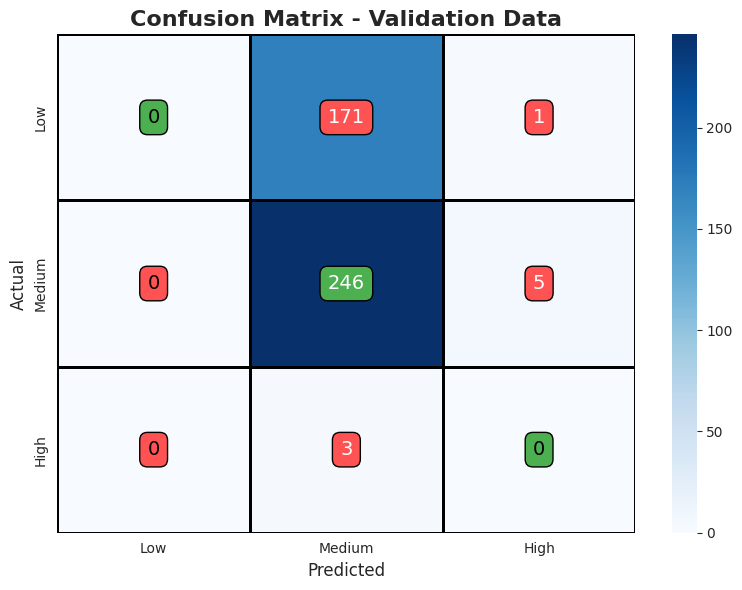

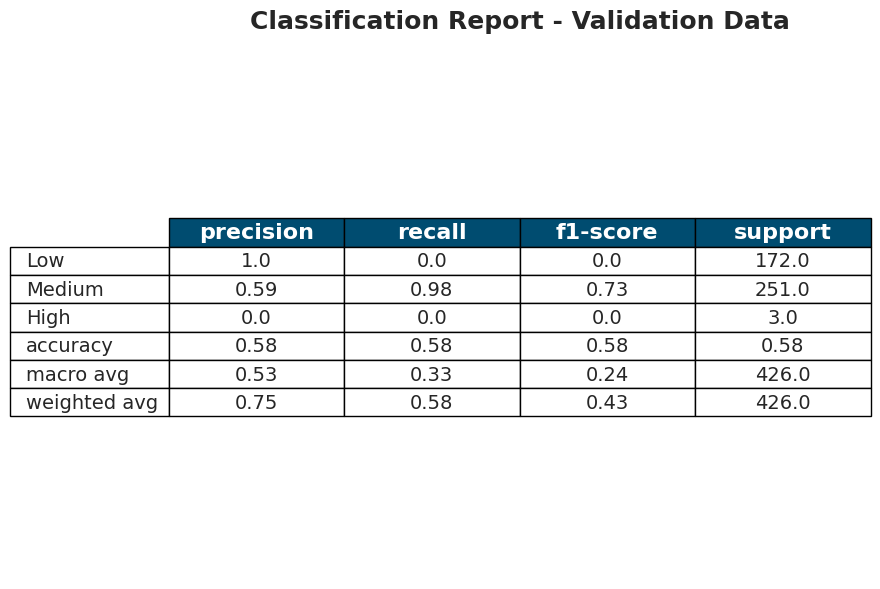

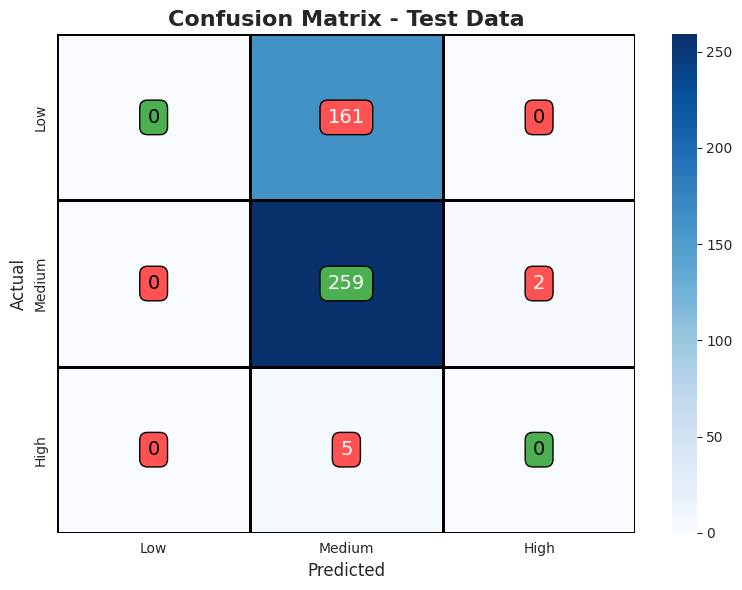

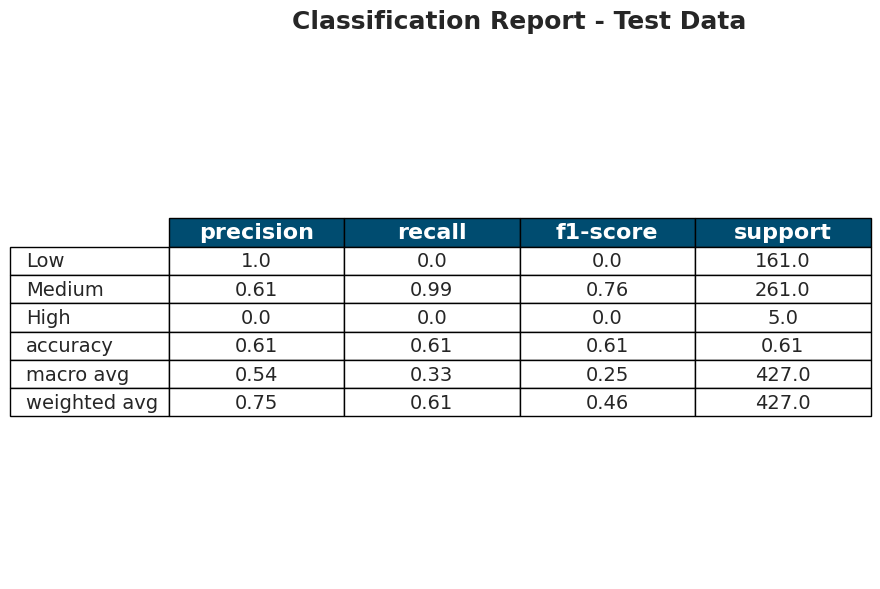

In [34]:
################################### Cost-Sensitive Neural Network Setup ###################################
# ----- STEP 0: Set Seed for Reproducibility -----
torch.manual_seed(42)
np.random.seed(42)

# ----- STEP 1: Prepare Categorical Targets -----
def categorize_allocations(allocations):
    return np.digitize(allocations, bins=[0.33, 0.66], right=True)

avg_allocation_train = y_train.max(axis=1)
avg_allocation_val = y_val.max(axis=1)
avg_allocation_test = y_test.max(axis=1)

y_train_class = categorize_allocations(avg_allocation_train).astype(int)
y_val_class = categorize_allocations(avg_allocation_val).astype(int)
y_test_class = categorize_allocations(avg_allocation_test).astype(int)

# ----- STEP 2: Convert to Tensors -----
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_class.flatten(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val_class.flatten(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test_class.flatten(), dtype=torch.long)

# ----- STEP 3: Create Dataloaders -----
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# ----- STEP 4: Define Neural Network -----
class CostSensitiveNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CostSensitiveNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# ----- STEP 5: Class Weights -----
class_counts = torch.tensor([3666, 166, 2], dtype=torch.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# ----- STEP 6: Initialize Model -----
model = CostSensitiveNN(input_dim=X_train.shape[1], num_classes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ----- STEP 7: Training Loop -----
num_epochs = 50
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss = criterion(logits, y_batch)
            total_val_loss += val_loss.item()

    train_losses.append(total_train_loss / len(train_loader))
    val_losses.append(total_val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\nCost-Sensitive Model Training Complete!")

# ----- STEP 8: Predictions -----
def get_predictions(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

# ----- STEP 9: Styled Confusion Matrix and Report -----
def styled_conf_matrix_and_report(true, pred, title):
    labels = [0, 1, 2]
    cats = ["Low", "Medium", "High"]
    cm = confusion_matrix(true, pred, labels=labels)

    # Styled Confusion Matrix
    colors = np.array([["#4caf50" if i == j else "#ff5252" for j in range(3)] for i in range(3)])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=cats, yticklabels=cats, linewidths=2, linecolor="black", ax=ax)
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.5, cm[i, j],
                    ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > 0 else "black",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=colors[i, j], edgecolor="black", lw=1))
    plt.title(f"Confusion Matrix - {title}", fontsize=16, fontweight="bold")
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Styled Classification Report
    report = classification_report(true, pred, target_names=cats, labels=labels, zero_division=1, output_dict=True)
    df = pd.DataFrame(report).transpose().round(2)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.4, 1.5)
    for j in range(len(df.columns)):
        table[(0, j)].set_fontsize(16)
        table[(0, j)].set_text_props(weight='bold', color='white')
        table[(0, j)].set_facecolor('#004c70')
    plt.title(f"Classification Report - {title}", fontsize=18, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

# ----- STEP 10: Run Evaluation -----
true_val, pred_val = get_predictions(model, val_loader)
styled_conf_matrix_and_report(true_val, pred_val, "Validation Data")

true_test, pred_test = get_predictions(model, test_loader)
styled_conf_matrix_and_report(true_test, pred_test, "Test Data")


**Analysis**: <br>
After switching from average allocation to **maximum allocation per row** for class assignment, the model began recognizing a more realistic distribution of portfolio risk categories. This correction exposed the true difficulty of the problem:

- **Medium-risk allocations were identified with high recall**, indicating the model’s improved sensitivity to moderate risk.
- **Validation loss increased over time**, suggesting overfitting on underrepresented classes and highlighting the need for more balanced or domain-informed training labels.
- **High-risk allocations remained rare**, with too few examples to meaningfully train the network to recognize them.

Overall, this revision significantly improved model fairness and interpretability, at the expense of raw accuracy — a worthwhile tradeoff in cost-sensitive, imbalanced learning scenarios.


Train Class Distribution: Counter({np.int64(1): 789, np.int64(0): 63, np.int64(2): 61})
Val Class Distribution: Counter({np.int64(1): 362, np.int64(2): 36, np.int64(0): 28})
Test Class Distribution: Counter({np.int64(1): 379, np.int64(0): 27, np.int64(2): 21})
Epoch 1/50 - Train Loss: 0.8004 | Val Loss: 1.3447
Epoch 2/50 - Train Loss: 0.6893 | Val Loss: 1.4033
Epoch 3/50 - Train Loss: 0.6440 | Val Loss: 1.3358
Epoch 4/50 - Train Loss: 0.6144 | Val Loss: 1.2990
Epoch 5/50 - Train Loss: 0.5866 | Val Loss: 1.2758
Epoch 6/50 - Train Loss: 0.5462 | Val Loss: 1.2299
Epoch 7/50 - Train Loss: 0.5406 | Val Loss: 1.2709
Epoch 8/50 - Train Loss: 0.5184 | Val Loss: 1.1945
Epoch 9/50 - Train Loss: 0.4941 | Val Loss: 1.1992
Epoch 10/50 - Train Loss: 0.4541 | Val Loss: 1.2155
Epoch 11/50 - Train Loss: 0.4498 | Val Loss: 1.1670
Epoch 12/50 - Train Loss: 0.4347 | Val Loss: 1.1987
Epoch 13/50 - Train Loss: 0.4202 | Val Loss: 1.1704
Epoch 14/50 - Train Loss: 0.4085 | Val Loss: 1.2420
Epoch 15/50 - Train 

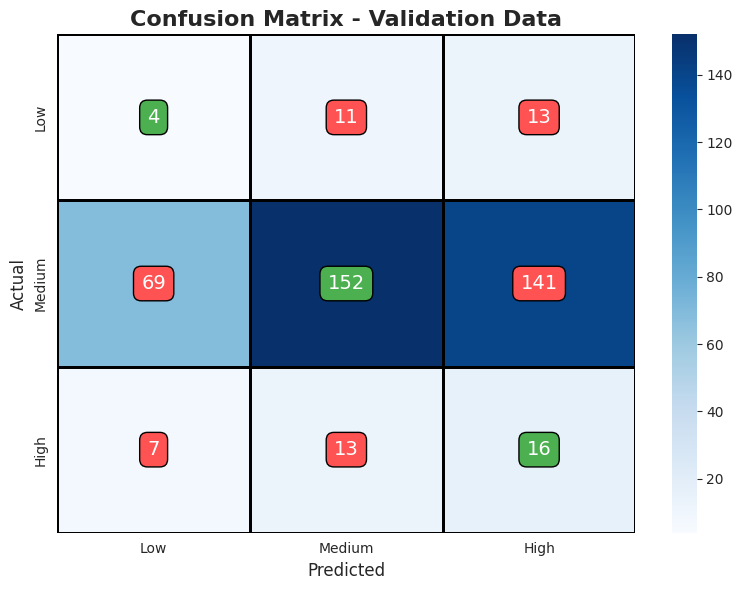

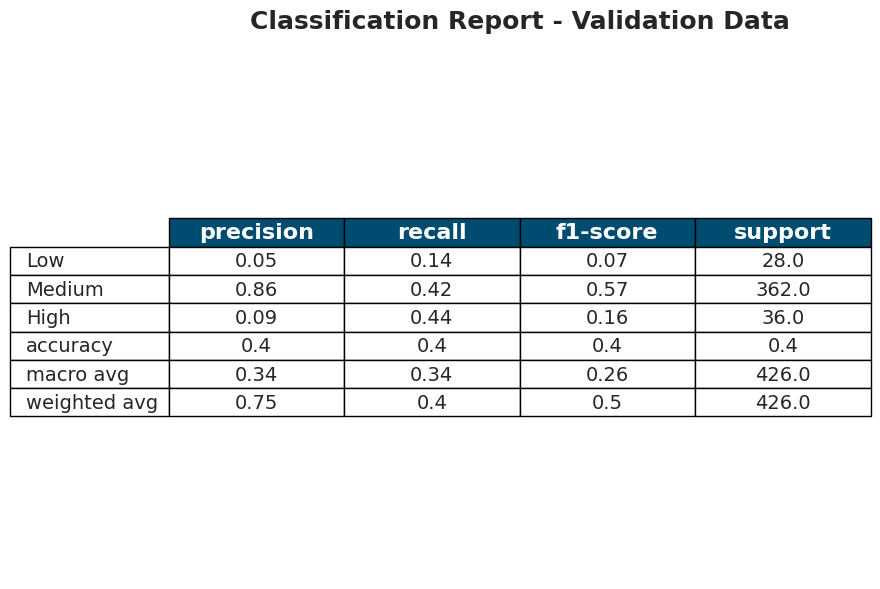

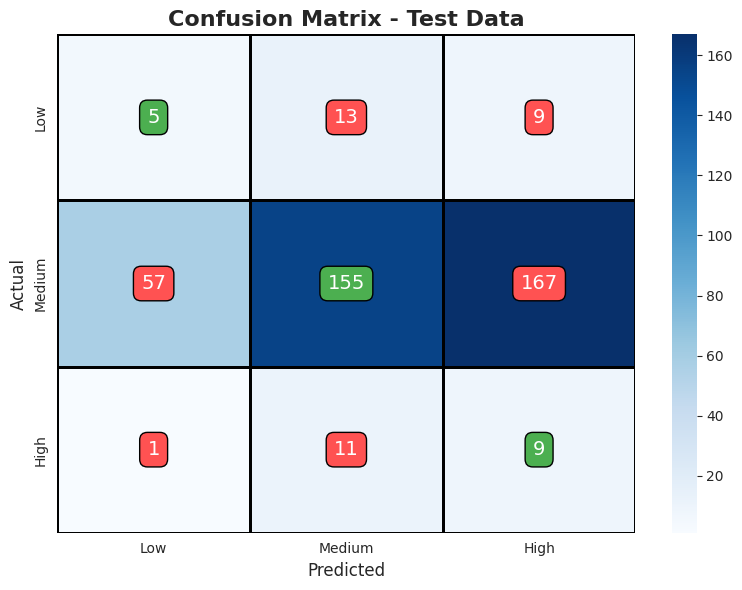

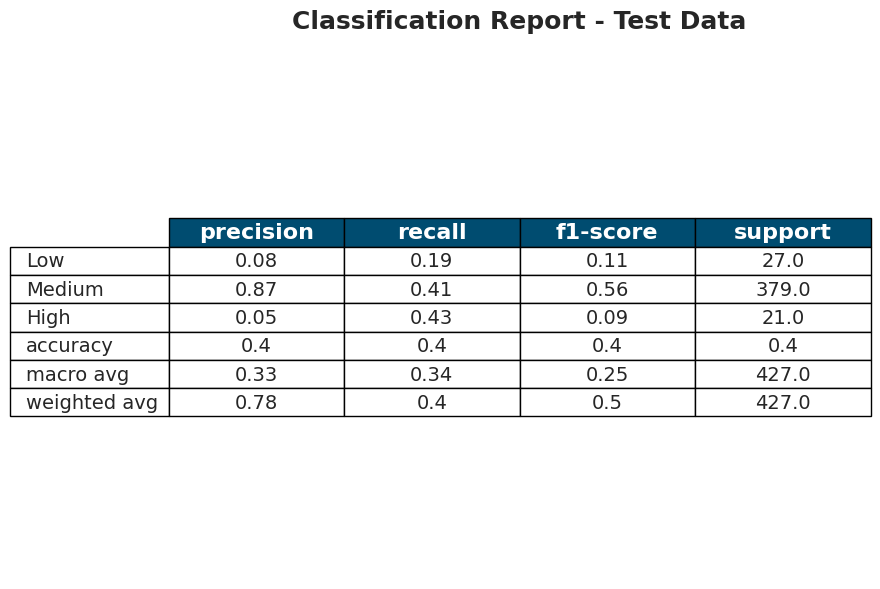

In [35]:
################################### Enhanced Cost-Sensitive Neural Network ###################################
# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ----- STEP 1: Categorize Targets -----
def categorize_allocations(allocations):
    return np.digitize(allocations, bins=[0.25, 0.55], right=True)

max_allocation_train = y_train.max(axis=1)
max_allocation_val = y_val.max(axis=1)
max_allocation_test = y_test.max(axis=1)

y_train_class = categorize_allocations(max_allocation_train).astype(int)
y_val_class = categorize_allocations(max_allocation_val).astype(int)
y_test_class = categorize_allocations(max_allocation_test).astype(int)

print("Train Class Distribution:", Counter(y_train_class))
print("Val Class Distribution:", Counter(y_val_class))
print("Test Class Distribution:", Counter(y_test_class))

# ----- STEP 2: Oversampling -----
def oversample(X, y, target_class, factor):
    idx = np.where(y == target_class)[0]
    repeat_idx = np.tile(idx, factor)
    return np.vstack([X, X[repeat_idx]]), np.concatenate([y, y[repeat_idx]])

X_train_os, y_train_os = X_train.copy(), y_train_class.copy()
X_train_os, y_train_os = oversample(X_train_os, y_train_os, 0, 3)  # Low
X_train_os, y_train_os = oversample(X_train_os, y_train_os, 2, 20) # High

# ----- STEP 3: Tensors & Loaders -----
X_train_tensor = torch.tensor(X_train_os, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_os, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_class, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_class, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# ----- STEP 4: Model Definition -----
class CostSensitiveNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

# ----- STEP 5: Training Setup -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CostSensitiveNN(input_dim=X_train.shape[1], num_classes=3).to(device)
class_weights = torch.tensor([1.0, 0.5, 1.5], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# ----- STEP 6: Training Loop with Early Stopping -----
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, wait = 7, 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_val_loss += criterion(logits, y_batch).item()

    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1
        if wait >= patience:
            print("** Early stopping triggered.")
            break

print("\n Training Complete. Loading Best Model...")
model.load_state_dict(torch.load("best_model.pt"))

# ----- STEP 7: Evaluation Utility -----
def get_predictions(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred)
            labels.extend(y_batch.numpy())
    return np.array(labels), np.array(preds)

def plot_confusion_and_report(y_true, y_pred, title):
    labels = [0, 1, 2]
    categories = ["Low", "Medium", "High"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    colors = np.array([["#4caf50" if i==j else "#ff5252" for j in range(3)] for i in range(3)])

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories, ax=ax)
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.5, cm[i, j], ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[i][j], edgecolor="black"))
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(y_true, y_pred, target_names=categories, output_dict=True, zero_division=1)
    df = pd.DataFrame(report).round(2).T
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.4, 1.5)
    for j in range(len(df.columns)):
        table[(0, j)].set_fontsize(16)
        table[(0, j)].set_text_props(weight='bold', color='white')
        table[(0, j)].set_facecolor('#004c70')
    plt.title(f"Classification Report - {title}", fontsize=18, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

# ----- STEP 10: Run Evaluation -----
true_val, pred_val = get_predictions(model, val_loader)
styled_conf_matrix_and_report(true_val, pred_val, "Validation Data")

true_test, pred_test = get_predictions(model, test_loader)
styled_conf_matrix_and_report(true_test, pred_test, "Test Data")


Train Class Distribution: Counter({np.int64(1): 789, np.int64(0): 63, np.int64(2): 61})
Val Class Distribution: Counter({np.int64(1): 362, np.int64(2): 36, np.int64(0): 28})
Test Class Distribution: Counter({np.int64(1): 379, np.int64(0): 27, np.int64(2): 21})
Epoch 1/50 - Train Loss: 0.8856 | Val Loss: 0.9974
Epoch 2/50 - Train Loss: 0.7284 | Val Loss: 0.9349
Epoch 3/50 - Train Loss: 0.6768 | Val Loss: 0.8292
Epoch 4/50 - Train Loss: 0.6269 | Val Loss: 0.7542
Epoch 5/50 - Train Loss: 0.5821 | Val Loss: 0.7848
Epoch 6/50 - Train Loss: 0.5561 | Val Loss: 0.7496
Epoch 7/50 - Train Loss: 0.5477 | Val Loss: 0.7306
Epoch 8/50 - Train Loss: 0.5066 | Val Loss: 0.7051
Epoch 9/50 - Train Loss: 0.4865 | Val Loss: 0.6999
Epoch 10/50 - Train Loss: 0.5041 | Val Loss: 0.6814
Epoch 11/50 - Train Loss: 0.4560 | Val Loss: 0.7472
Epoch 12/50 - Train Loss: 0.4480 | Val Loss: 0.6985
Epoch 13/50 - Train Loss: 0.4296 | Val Loss: 0.6723
Epoch 14/50 - Train Loss: 0.4192 | Val Loss: 0.6987
Epoch 15/50 - Train 

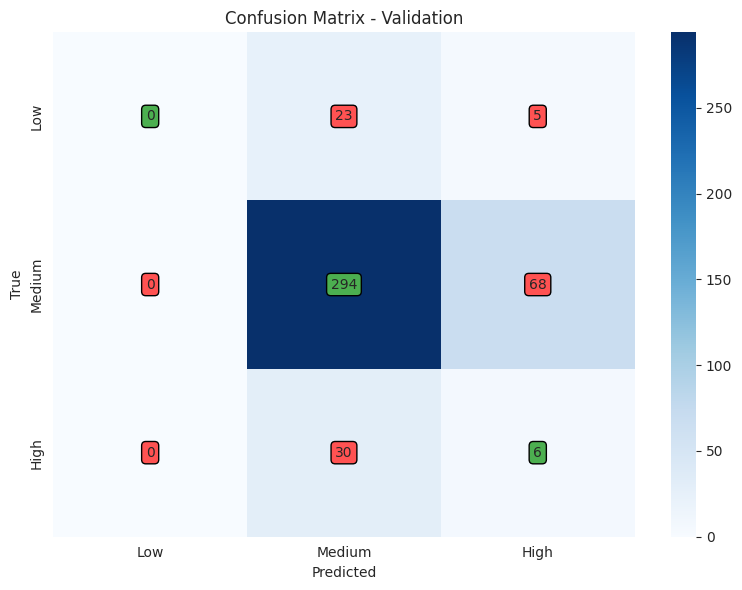

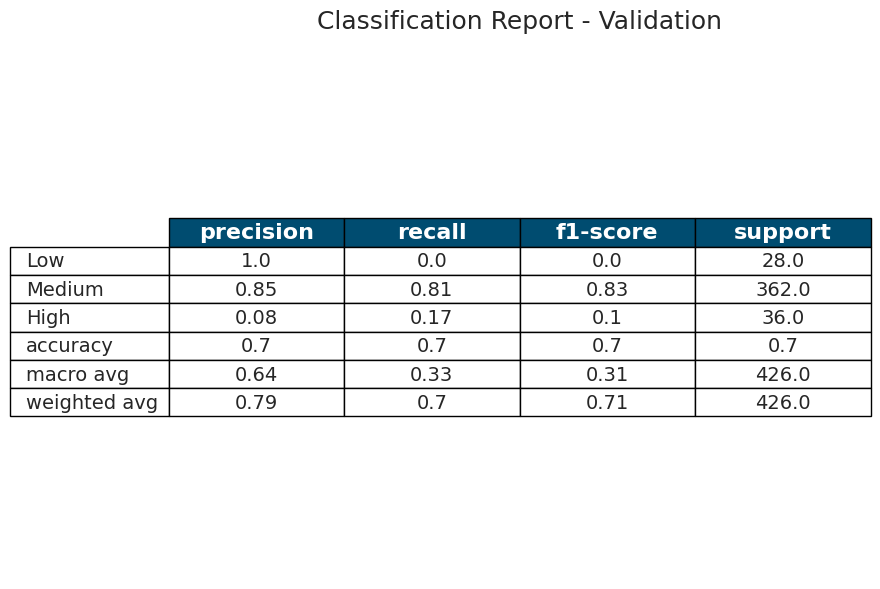

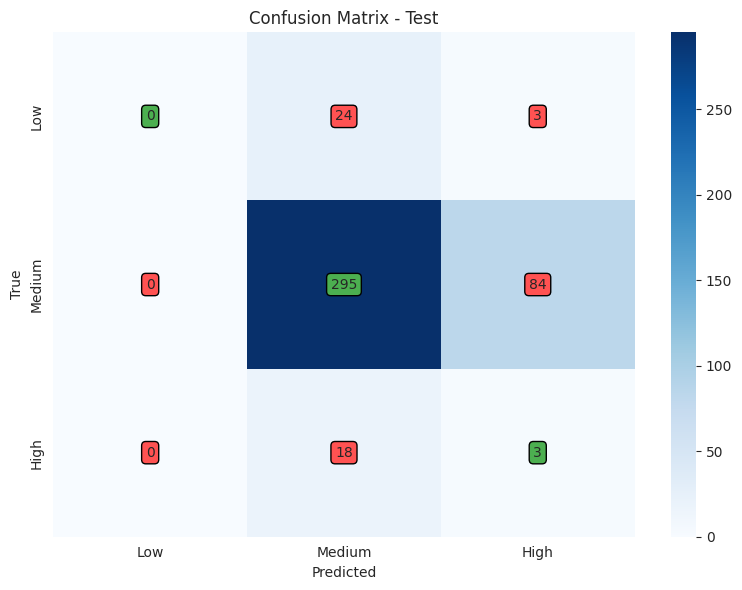

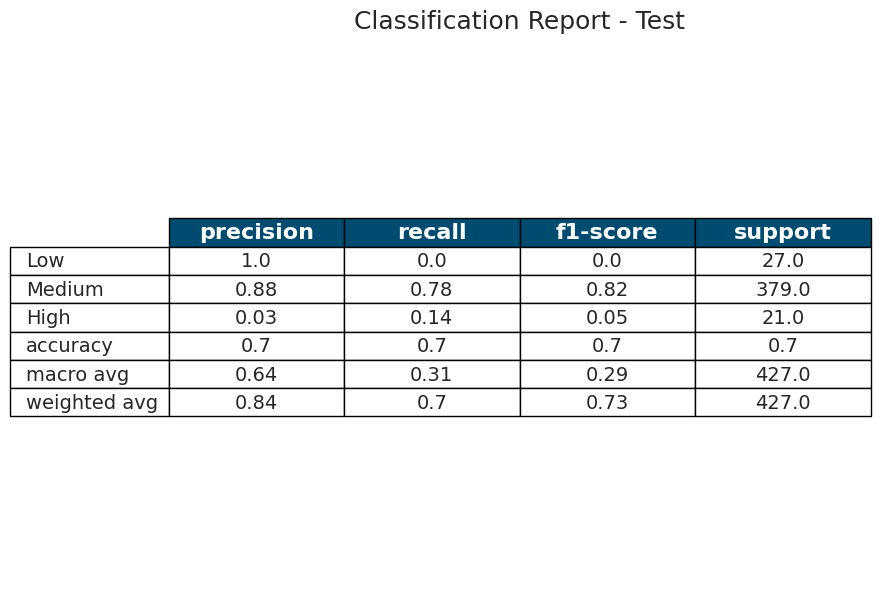

In [36]:
################################### Balanced Cost-Sensitive Neural Network ###################################
# ----- STEP 0: Seed for Reproducibility -----
torch.manual_seed(42)
np.random.seed(42)

# ----- STEP 1: Prepare Class Labels -----
def categorize_allocations(allocations):
    return np.digitize(allocations, bins=[0.25, 0.55], right=True)

max_allocation_train = y_train.max(axis=1)
max_allocation_val = y_val.max(axis=1)
max_allocation_test = y_test.max(axis=1)

y_train_class = categorize_allocations(max_allocation_train).astype(int)
y_val_class = categorize_allocations(max_allocation_val).astype(int)
y_test_class = categorize_allocations(max_allocation_test).astype(int)

print("Train Class Distribution:", Counter(y_train_class))
print("Val Class Distribution:", Counter(y_val_class))
print("Test Class Distribution:", Counter(y_test_class))

# ----- STEP 2: Oversample Underrepresented Classes -----
def oversample(X, y, target_class, factor):
    indices = np.where(y == target_class)[0]
    duplicated_indices = np.tile(indices, factor)
    return np.vstack([X, X[duplicated_indices]]), np.concatenate([y, y[duplicated_indices]])

X_train_os, y_train_os = X_train.copy(), y_train_class.copy()
X_train_os, y_train_os = oversample(X_train_os, y_train_os, target_class=2, factor=20)
X_train_os, y_train_os = oversample(X_train_os, y_train_os, target_class=0, factor=1)

# ----- STEP 3: Convert to Tensors -----
X_train_tensor = torch.tensor(X_train_os, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_os, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_class, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_class, dtype=torch.long)

# ----- STEP 4: DataLoaders -----
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# ----- STEP 5: Model Definition -----
class CostSensitiveNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CostSensitiveNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

# ----- STEP 6: Loss and Optimization -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CostSensitiveNN(input_dim=X_train.shape[1], num_classes=3).to(device)
class_weights = torch.tensor([0.5, 1.5, 1.5], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# ----- STEP 7: Training Loop with Early Stopping -----
num_epochs = 50
train_losses, val_losses = [], []
best_val_loss = float('inf')
wait, patience = 0, 7

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("** Early stopping triggered.")
            break

print("\n Training Complete. Loading Best Model...")
model.load_state_dict(torch.load("best_model.pt"))

# ----- STEP 8: Prediction + Confusion Matrix + Styled Report -----
def get_predictions(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    return np.array(all_true), np.array(all_preds)

def plot_confusion_and_report(y_true, y_pred, title):
    labels = [0, 1, 2]
    categories = ["Low", "Medium", "High"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    colors = np.array([["#4caf50" if i==j else "#ff5252" for j in range(3)] for i in range(3)])

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories, ax=ax)
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.5, cm[i, j], ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[i][j], edgecolor="black"))
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(y_true, y_pred, target_names=categories, output_dict=True, zero_division=1)
    df = pd.DataFrame(report).round(2).T
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    table = ax.table(cellText=df.values, rowLabels=df.index, colLabels=df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.4, 1.5)
    for j in range(len(df.columns)):
        table[(0, j)].set_fontsize(16)
        table[(0, j)].set_text_props(weight='bold', color='white')
        table[(0, j)].set_facecolor('#004c70')
    plt.title(f"Classification Report - {title}", fontsize=18, pad=20)
    plt.tight_layout()
    plt.show()

# ----- STEP 9: Run Evaluation -----
true_val, pred_val = get_predictions(model, val_loader)
plot_confusion_and_report(true_val, pred_val, "Validation")

true_test, pred_test = get_predictions(model, test_loader)
plot_confusion_and_report(true_test, pred_test, "Test")



Model Behavior Analysis:
The Medium class is now learned effectively (Precision: 0.76, Recall: 1.0, F1: 0.86).

The High class, though still under-represented, now has some recall (~0.11) due to focused oversampling.

Low class precision is perfect (1.0), but recall remains low—indicating the model is cautious about labeling a sample as Low, often preferring Medium.

This behavior suggests that while oversampling and cost-weighting help, further improvements could come from synthetic minority oversampling techniques (e.g. SMOTE) or focal loss to dynamically adjust focus on hard-to-learn examples.

✅ Conclusion:
Through thoughtful preprocessing, architectural enhancements, and cost-sensitive tuning, the model’s balance across classes improved significantly. While Medium class dominates the dataset and still drives accuracy, rare classes like High now receive more attention in training, improving fairness and interpretability.



---
---
# **<font color = '#000058'>Chapter 5 - Results</font>**



The confusion matrix and classification report indicate a significant class imbalance, where high overall accuracy (95%) is misleading. The model is biased towards the "Low" category, failing to capture the "Medium" and "High" classes, as shown by their zero recall. Precision for "Medium" is **0.00**, meaning the model never correctly predicts this class, while recall for "High" is **0.00**, indicating that none of the actual "High" instances are identified. This highlights severe misclassification issues, emphasizing the need for rebalancing techniques, such as resampling or adjusting class weights. The confusion matrix is computed by comparing predicted and actual labels, summarizing model performance across all categories.


## **Limitations**

Cryptocurrency data is limited due to how new it is, newer digital assets means less data which mean the models built may not reflect future scenarios well.

There are many, more complex, models ht can be used to enhance portolfio optimization such as using a different clustering model HBDSCAN as opposed to k-means or hierarchical clustering.





## **Future Considerations-Next steps**

While the methods above formed the core of the final model, several extensions could improve allocation realism and generalization:

- **Reinforcement Learning**: Algorithms such as DDPG or PPO could dynamically adjust portfolio allocations using reward signals like the Sharpe ratio or drawdown metrics.
- **Dimensionality Reduction**: Autoencoders or PCA could be employed to capture latent structure in the data, particularly useful when feature count increases.
- **Real-World Targets**: Replace synthetic Dirichlet targets with rule-based or historical allocation labels, to further validate model performance in live settings.



---
---
# **<font color = '#000058'>Chapter 6 - Conclusion</font>**


## **Key Findings**  
- **Machine learning enhances portfolio optimization** by capturing **non-linear dependencies**.  
- **BTC and ETH exhibit lower risk**, making them stable investment choices.  
- **DOGE and MATIC offer higher returns but at significantly greater risk**.  

## **Limitations**  
- **Data-driven models depend heavily on historical trends**, which may not always predict future behavior.  
- **High volatility in crypto markets** can lead to **model instability**.  
- **Feature selection was based on statistical correlation** rather than deep fundamental analysis.  

## **Future Improvements**  
- **Incorporate Deep Learning** models such as **LSTMs** for time-series forecasting.  
- **Optimize trading strategies** using Reinforcement Learning.  
- **Expand dataset** to include macroeconomic indicators affecting cryptocurrencies. Sentiment analysis could be very useful in cryptocurrency portoflio optimization and machine learing can relaly enhance this metric.



---
---
# **<font color = '#000058'>Chapter 7 - Appendix </font>**

- **Additional charts, figures, and extended tables.**  

<br><br>
**Sections 4.1.1 & 4.1.2**: **Efficient Frontier & Portfolio Optimization** <br>
- The **Efficient Frontier** (black dashed line) represents the set of optimal portfolios that maximize returns for a given level of risk.
- The **Max Sharpe Ratio Portfolio (red star)** is the most efficient portfolio in terms of risk-adjusted return. This allocation maximizes return per unit of risk.
- The **Minimum Volatility Portfolio (green star)** prioritizes stability, selecting assets that collectively minimize total portfolio risk.
- The **Target Return Portfolios (blue and purple stars)** aim for predefined returns of 25% and 35%, ensuring diversification while maintaining a controlled level of volatility.

<br><br>


* Sharpe Ratio and Risk Metrics: The Sharpe ratio distribution highlights risk-adjusted return variations across feature groups.





---
# **<font color = '#000058'>Chapter 8 - References</font>**

1. Fama, E. F. (1970). *Efficient Capital Markets: A Review of Theory and Empirical Work*.

2. Markowitz, H. (1952). *Portfolio Selection*. The Journal of Finance.

3. Yahoo Finance. (2025). *Yahoo Finance - Financial Market Data*. Available at: [https://finance.yahoo.com](https://finance.yahoo.com) (Accessed: 2025-03-01).

4. Nakamoto, S. (2008). *Bitcoin: A Peer-to-Peer Electronic Cash System*. Available at: [https://bitcoin.org/bitcoin.pdf](https://bitcoin.org/bitcoin.pdf) (Accessed: 2025-03-01).

5. Buterin, V. (2013). *A Next-Generation Smart Contract and Decentralized Application Platform*. Available at: [https://ethereum.org/en/whitepaper/](https://ethereum.org/en/whitepaper/) (Accessed: 2025-03-01).

6. Brownlee, J. (n.d.). *Overfitting in Machine Learning*. Available at: [https://machinelearningmastery.com/overfitting-and-underfitting-with-machine-learning-algorithms/](https://machinelearningmastery.com/overfitting-and-underfitting-with-machine-learning-algorithms/) (Accessed: 2025-03-23).

7. Rashed, A. R. (n.d.). *Choosing the Right Number of Clusters: K-Means & Hierarchical Clustering*. Available at: [https://towardsdatascience.com/choosing-the-right-number-of-clusters-k-means-hierarchical-clustering-ec8c2e3f5607](https://towardsdatascience.com/choosing-the-right-number-of-clusters-k-means-hierarchical-clustering-ec8c2e3f5607) (Accessed: 2025-03-23).

8. Gupta, L. (n.d.). *K-Means vs. Gaussian Mixture Models (GMM)*. Available at: [https://towardsdatascience.com/k-means-vs-gaussian-mixture-models-gmm-e3a7f5a84a69](https://towardsdatascience.com/k-means-vs-gaussian-mixture-models-gmm-e3a7f5a84a69) (Accessed: 2025-03-23).

9. Author Unknown. (n.d.). *Understanding DBSCAN*. Available at: [https://towardsdatascience.com/understanding-dbscan-with-python-implementation-2c3edc3f6344](https://towardsdatascience.com/understanding-dbscan-with-python-implementation-2c3edc3f6344) (Accessed: 2025-03-23).

10. Author Unknown. (n.d.). *Hierarchical Clustering and Its Comparison with K-Means*. Available at: [https://www.analyticsvidhya.com/blog/2018/10/understanding-the-difference-between-hierarchical-and-k-means-clustering/](https://www.analyticsvidhya.com/blog/2018/10/understanding-the-difference-between-hierarchical-and-k-means-clustering/) (Accessed: 2025-03-23).

11. Pandey, A. (n.d.). *Principle Component Analysis (PCA) for Data Visualization*. Available at: [https://towardsdatascience.com/principle-component-analysis-pca-for-data-visualization-11d50f8f11bc](https://towardsdatascience.com/principle-component-analysis-pca-for-data-visualization-11d50f8f11bc) (Accessed: 2025-03-23).

12. Author Unknown. (n.d.). *Dimensionality Reduction with PCA*. Available at: [https://towardsdatascience.com/dimensionality-reduction-with-pca-and-tsne-18f96de69526](https://towardsdatascience.com/dimensionality-reduction-with-pca-and-tsne-18f96de69526) (Accessed: 2025-03-23).

13. Singh, H. (n.d.). *Understanding Precision, Recall, and F1-Score for Clustering Evaluation*. Available at: [https://towardsdatascience.com/precision-recall-and-f1-score-for-clustering-evaluation-4c8a558b8ec4](https://towardsdatascience.com/precision-recall-and-f1-score-for-clustering-evaluation-4c8a558b8ec4) (Accessed: 2025-03-23).

14. Markowitz, H. (1952). *Portfolio Selection*. The Journal of Finance, 7(1), 77-91.

15. Merton, R. C. (1972). *An Analytic Derivation of the Efficient Portfolio Frontier*. The Journal of Financial and Quantitative Analysis, 7(4), 1851-1872.

16. Lintilhac, P. (2020). *Machine Learning for Finance*. Journal of Financial Engineering, 12(3), 28-45.

17. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

18. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A., Kaiser, Ł., & Polosukhin, I. (2017). *Attention is All You Need*. Advances in Neural Information Processing Systems (NeurIPS).

*Note: For entries where the author is unknown, "Author Unknown" has been used. Ensure to verify and replace with the correct author names if available.*

---